# Large Language Model for Analysing Time-Series Energy Generation Data

**Student Name:** Adeniran Adewumi  
**Student ID:** 202447778  
**Programme:** MSc Artificial Intelligence for Engineering Research Project  
**University:** University of Hull  

---

**Data Source:** Elia Open Data Portal — Measured and Forecasted Total Load on the Belgian Grid (Historical)  
**Dataset ID:** ods001  
**URL:** https://opendata.elia.be/explore/dataset/ods001  
**Publisher:** Elia Transmission Belgium SA  
**Licence:** Elia Open Data Licence  

---

## 1. Environment Setup

Before any analysis, we install and import all required libraries. Pinning library versions ensures
reproducibility, anyone running this notebook in the future will get the same results.

In [ ]:
# Install required libraries (run once per Colab session)
!pip install -q statsmodels prophet xgboost openai scikit-learn matplotlib seaborn pandas numpy torch

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import torch
import warnings

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

# Consistent plot styling throughout the notebook
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Check GPU availability for later model training
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU available: {gpu_name} ({vram_gb:.1f} GB VRAM)")
else:
    print("No GPU detected — some models will run slower on CPU")

print(f"PyTorch version: {torch.__version__}")
print(f"Pandas version: {pd.__version__}")
print("All libraries loaded successfully.")

GPU available: NVIDIA L4 (23.7 GB VRAM)
PyTorch version: 2.10.0+cu128
Pandas version: 2.2.2
All libraries loaded successfully.


## 2. Data Loading and Initial Inspection

We begin by loading the raw dataset from the Elia Open Data Portal. This is 15-minute resolution
total electricity load data from the Belgian grid, measured in megawatts (MW).

Before any cleaning or modelling, we need to understand what we are working with: the shape,
column types, date range, and whether there are any obvious issues.

In [ ]:
# Load the raw CSV — Elia uses semicolons as delimiter
df_raw = pd.read_csv(
    '/content/ods001.csv',  # Upload your CSV to Colab first
    sep=';'
)

# Parse the timezone-aware datetime strings and convert to UTC,
# then drop timezone info so all downstream operations work cleanly
df_raw['Datetime'] = pd.to_datetime(df_raw['Datetime'], utc=True)
df_raw['Datetime'] = df_raw['Datetime'].dt.tz_convert('Europe/Brussels').dt.tz_localize(None)

# Sort chronologically (raw file is in reverse order)
df_raw = df_raw.sort_values('Datetime').reset_index(drop=True)

# Basic overview
print('=' * 55)
print('DATASET OVERVIEW')
print('=' * 55)
print(f'Shape:            {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
print(f'Date range:       {df_raw["Datetime"].min()} to {df_raw["Datetime"].max()}')
print(f'Duration:         {(df_raw["Datetime"].max() - df_raw["Datetime"].min()).days:,} days')
print(f'Resolution:       {df_raw["Resolution code"].unique()}')
print(f'\nColumns:')
for col in df_raw.columns:
    dtype = df_raw[col].dtype
    nulls = df_raw[col].isnull().sum()
    print(f'  {col:<35} {str(dtype):<15} {nulls:>6} nulls')

print(f'\nFirst 5 rows:')
df_raw.head()

DATASET OVERVIEW
Shape:            394,844 rows x 10 columns
Date range:       2015-01-01 00:00:00 to 2026-04-05 23:45:00
Duration:         4,112 days
Resolution:       ['PT15M']

Columns:
  Datetime                            datetime64[ns]       0 nulls
  Resolution code                     object               0 nulls
  Total Load                          float64            736 nulls
  Most recent forecast                float64              0 nulls
  Most recent P10                     float64              0 nulls
  Most recent P90                     float64              0 nulls
  Day-ahead 6PM forecast              float64              0 nulls
  Day-ahead 6PM P10                   float64              0 nulls
  Day-ahead 6PM P90                   float64              0 nulls
  Week-ahead forecast                 float64            192 nulls

First 5 rows:


,Datetime,Resolution code,Total Load,Most recent forecast,Most recent P10,Most recent P90,Day-ahead 6PM forecast,Day-ahead 6PM P10,Day-ahead 6PM P90,Week-ahead forecast
0,2015-01-01 00:00:00,PT15M,10142.19,9496.05,8871.71,10120.38,9697.59,9076.64,10318.53,9833.37
1,2015-01-01 00:15:00,PT15M,10051.28,9329.17,8715.80,9942.53,9526.54,8916.55,10136.53,9653.31
2,2015-01-01 00:30:00,PT15M,9952.87,9174.72,8571.51,9777.92,9367.66,8767.84,9967.47,9473.22
3,2015-01-01 00:45:00,PT15M,9821.78,9025.46,8432.07,9618.85,9216.09,8625.97,9806.20,9319.45
4,2015-01-01 01:00:00,PT15M,9755.00,9222.33,8880.23,9564.44,10130.36,9777.87,10482.86,9203.25


### Column Descriptions

| Column | Description |
|--------|-------------|
| `Datetime` | Timestamp of the measurement (Europe/Brussels timezone) |
| `Resolution code` | Temporal resolution — PT15M means 15-minute intervals |
| `Total Load` | **Actual measured** total electricity load on the Belgian grid (MW) — this is our target variable |
| `Most recent forecast` | Most recently available forecast at that time (MW) |
| `Most recent P10 / P90` | 10th and 90th percentile bounds of the most recent forecast |
| `Day-ahead 6PM forecast` | Forecast made at 6PM the previous day (MW) |
| `Day-ahead 6PM P10 / P90` | Prediction interval for the day-ahead forecast |
| `Week-ahead forecast` | Forecast made one week in advance (MW) |

Our **target variable** is `Total Load` — the actual measured electricity demand. The forecast columns
could serve as additional features or benchmarks, but our primary goal is to predict `Total Load`
from its own historical values.

In [ ]:
# Descriptive statistics for the target variable
print('=' * 55)
print('DESCRIPTIVE STATISTICS — Total Load (MW)')
print('=' * 55)
print(df_raw['Total Load'].describe())

print(f'\nSkewness:  {df_raw["Total Load"].skew():.4f}')
print(f'Kurtosis:  {df_raw["Total Load"].kurt():.4f}')

# Data quality checks
print('\n--- Data Quality Flags ---')
n_missing = df_raw['Total Load'].isnull().sum()
n_zero    = (df_raw['Total Load'] == 0).sum()
n_neg     = (df_raw['Total Load'] < 0).sum()

print(f'Missing values:  {n_missing} ({n_missing/len(df_raw)*100:.2f}%)')
print(f'Zero values:     {n_zero} ({n_zero/len(df_raw)*100:.1f}%)')
print(f'Negative values: {n_neg} ({n_neg/len(df_raw)*100:.1f}%) — physically impossible for load')

# Check for expected number of readings per day (96 for 15-min data)
readings_per_day = df_raw.groupby(df_raw['Datetime'].dt.date).size()
print(f'\nReadings per day:')
print(f'  Expected: 96 (24h x 4 per hour)')
print(f'  Actual mean: {readings_per_day.mean():.1f}')
print(f'  Days with full 96 readings: {(readings_per_day == 96).sum()} / {len(readings_per_day)}')
print(f'  Days with gaps: {(readings_per_day < 96).sum()}')

DESCRIPTIVE STATISTICS — Total Load (MW)
count    394108.000000
mean       9581.750149
std        1400.060344
min        5877.450000
25%        8489.890000
50%        9562.170000
75%       10609.400000
max       14356.680000
Name: Total Load, dtype: float64

Skewness:  0.1324
Kurtosis:  -0.6546

--- Data Quality Flags ---
Missing values:  736 (0.19%)
Zero values:     0 (0.0%)
Negative values: 0 (0.0%) — physically impossible for load

Readings per day:
  Expected: 96 (24h x 4 per hour)
  Actual mean: 96.0
  Days with full 96 readings: 4090 / 4113
  Days with gaps: 12


## 3. Exploratory Data Analysis (EDA)

Before building any models, we need to thoroughly understand the structure of the data.
The EDA has three goals:
1. Identify temporal patterns (daily, weekly, seasonal) that our models need to capture
2. Detect anomalies or periods of unusual behaviour
3. Justify the modelling decisions we make later (context window sizes, seasonality parameters, etc.)

Every figure in this section is numbered and will be referenced by number in the dissertation.

### 3.1 Full Time Series Visualisation

We start by plotting the entire series at different zoom levels. This gives us an intuitive
understanding of the data's overall shape before we decompose it statistically.

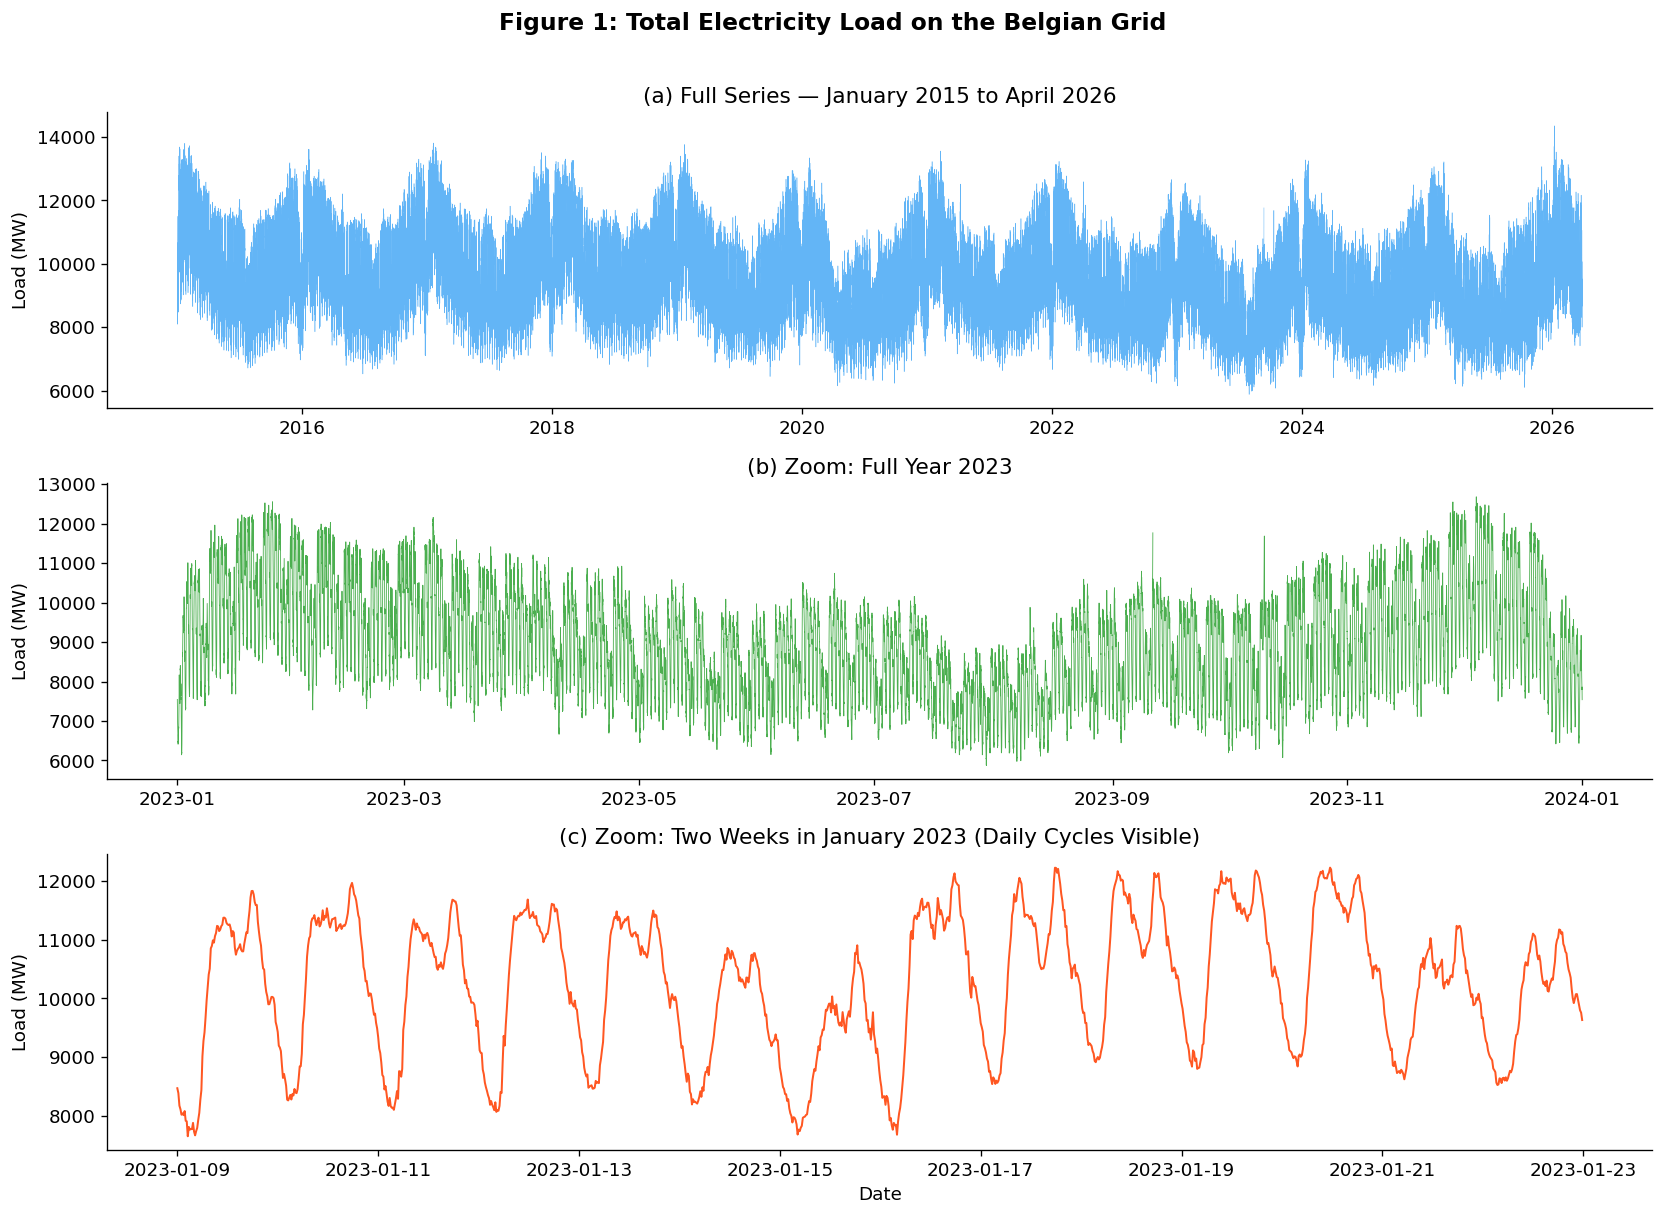

Figure 1 saved.


In [ ]:
# Figure 1: Raw time series at three zoom levels
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle('Figure 1: Total Electricity Load on the Belgian Grid',
             fontsize=14, fontweight='bold', y=1.01)

# Full series
axes[0].plot(df_raw['Datetime'], df_raw['Total Load'],
             color='#2196F3', linewidth=0.3, alpha=0.7)
axes[0].set_title('(a) Full Series — January 2015 to April 2026')
axes[0].set_ylabel('Load (MW)')

# Zoom: one year (2023 as a representative recent year)
year_mask = (df_raw['Datetime'] >= '2023-01-01') & (df_raw['Datetime'] < '2024-01-01')
axes[1].plot(df_raw.loc[year_mask, 'Datetime'], df_raw.loc[year_mask, 'Total Load'],
             color='#4CAF50', linewidth=0.5)
axes[1].set_title('(b) Zoom: Full Year 2023')
axes[1].set_ylabel('Load (MW)')

# Zoom: two weeks in January 2023 (shows daily patterns clearly)
week_mask = (df_raw['Datetime'] >= '2023-01-09') & (df_raw['Datetime'] < '2023-01-23')
axes[2].plot(df_raw.loc[week_mask, 'Datetime'], df_raw.loc[week_mask, 'Total Load'],
             color='#FF5722', linewidth=1.2)
axes[2].set_title('(c) Zoom: Two Weeks in January 2023 (Daily Cycles Visible)')
axes[2].set_ylabel('Load (MW)')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.savefig('fig1_raw_timeseries.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure 1 saved.")

### 3.2 Distribution Analysis

Understanding the distribution of load values helps us identify whether the data is symmetric,
has heavy tails, or contains unusual clusters. This also informs whether certain transformations
(e.g., log scaling) might be needed before modelling.

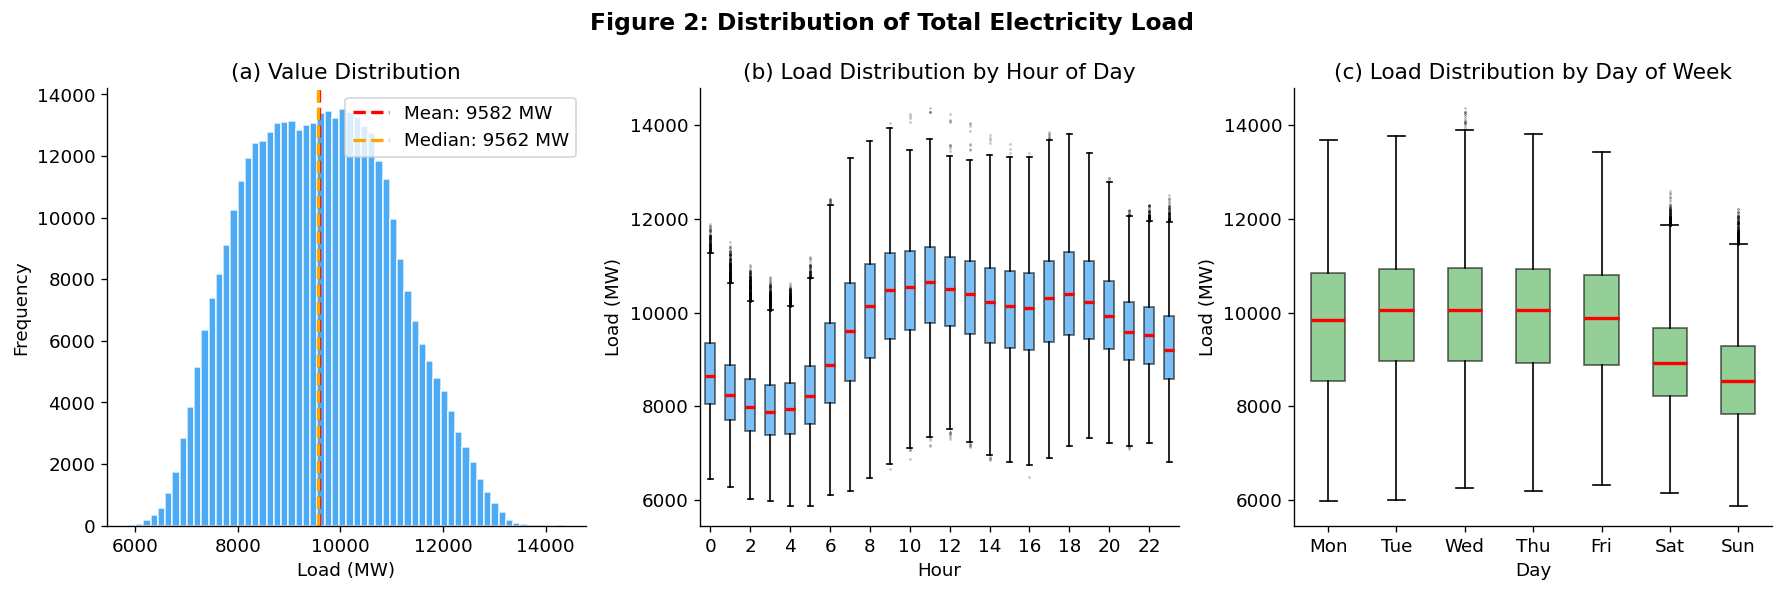

Figure 2 saved.


In [ ]:
# Figure 2: Distribution of Total Load
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Figure 2: Distribution of Total Electricity Load',
             fontsize=14, fontweight='bold')

# Histogram with mean and median lines
axes[0].hist(df_raw['Total Load'].dropna(), bins=60,
             color='#2196F3', alpha=0.8, edgecolor='white')
axes[0].axvline(df_raw['Total Load'].mean(), color='red',
                linestyle='--', linewidth=2, label=f"Mean: {df_raw['Total Load'].mean():.0f} MW")
axes[0].axvline(df_raw['Total Load'].median(), color='orange',
                linestyle='--', linewidth=2, label=f"Median: {df_raw['Total Load'].median():.0f} MW")
axes[0].set_title('(a) Value Distribution')
axes[0].set_xlabel('Load (MW)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box plot by hour of day — shows the daily demand curve shape
df_raw['hour'] = df_raw['Datetime'].dt.hour
hourly_data = [df_raw[df_raw['hour'] == h]['Total Load'].dropna().values for h in range(24)]
bp = axes[1].boxplot(hourly_data, patch_artist=True,
                     boxprops=dict(facecolor='#2196F3', alpha=0.6),
                     medianprops=dict(color='red', linewidth=2),
                     flierprops=dict(marker='.', markersize=1, alpha=0.3))
axes[1].set_title('(b) Load Distribution by Hour of Day')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Load (MW)')
axes[1].set_xticks(range(1, 25, 2))
axes[1].set_xticklabels(range(0, 24, 2))

# Box plot by day of week
df_raw['day_of_week'] = df_raw['Datetime'].dt.dayofweek
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily_data = [df_raw[df_raw['day_of_week'] == d]['Total Load'].dropna().values for d in range(7)]
bp2 = axes[2].boxplot(daily_data, patch_artist=True,
                      boxprops=dict(facecolor='#4CAF50', alpha=0.6),
                      medianprops=dict(color='red', linewidth=2),
                      flierprops=dict(marker='.', markersize=1, alpha=0.3))
axes[2].set_title('(c) Load Distribution by Day of Week')
axes[2].set_xlabel('Day')
axes[2].set_ylabel('Load (MW)')
axes[2].set_xticklabels(day_names)

plt.tight_layout()
plt.savefig('fig2_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure 2 saved.")

### 3.3 Seasonal Patterns

Electricity demand follows strong recurring patterns driven by human activity and weather.
We expect to see:
- **Daily seasonality**: demand rises in the morning, peaks during working hours, drops at night
- **Weekly seasonality**: lower demand on weekends compared to weekdays
- **Annual seasonality**: higher demand in winter (heating, shorter daylight) than summer

Identifying these patterns is critical because they directly inform our model choices and
the context window sizes used in our forecasting experiments.

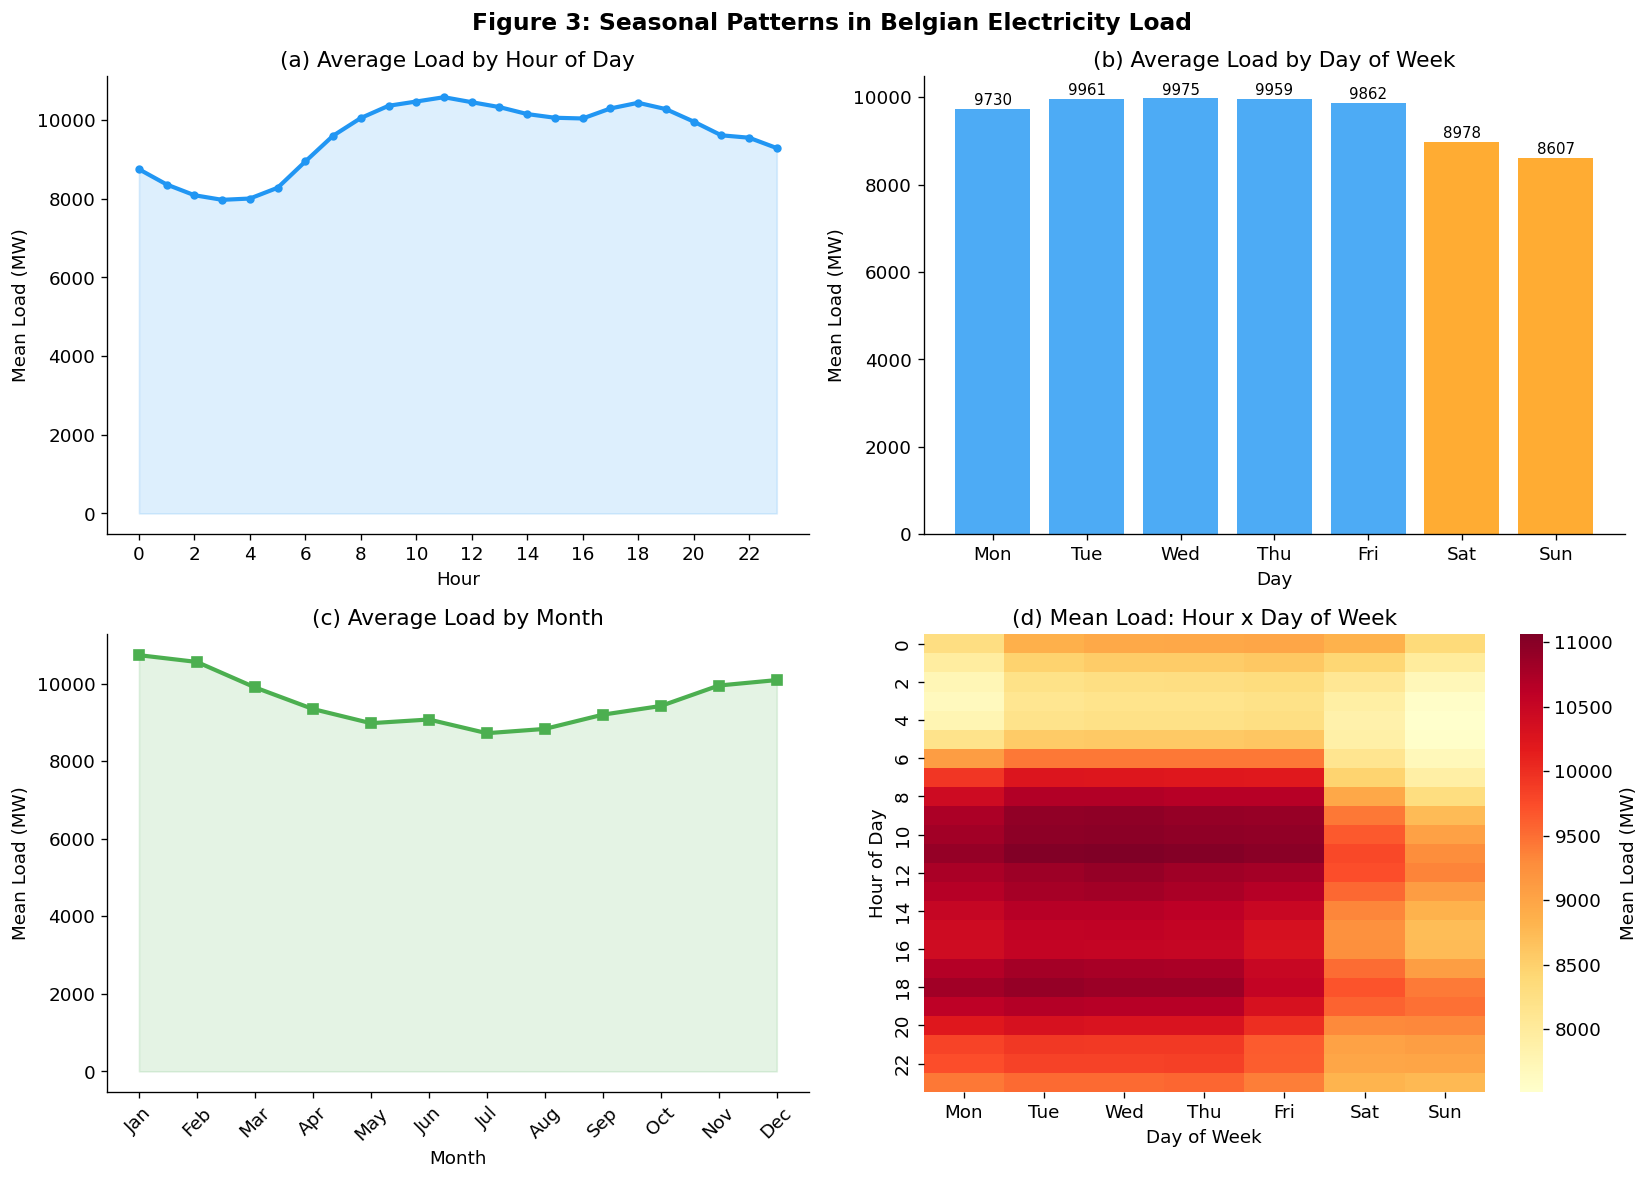

Figure 3 saved.


In [ ]:
# Figure 3: Seasonal patterns at daily, weekly, and annual scales
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Figure 3: Seasonal Patterns in Belgian Electricity Load',
             fontsize=14, fontweight='bold')

# (a) Average load by hour of day
hourly_avg = df_raw.groupby('hour')['Total Load'].mean()
axes[0, 0].plot(hourly_avg.index, hourly_avg.values,
                color='#2196F3', linewidth=2.5, marker='o', markersize=4)
axes[0, 0].fill_between(hourly_avg.index, hourly_avg.values, alpha=0.15, color='#2196F3')
axes[0, 0].set_title('(a) Average Load by Hour of Day')
axes[0, 0].set_xlabel('Hour')
axes[0, 0].set_ylabel('Mean Load (MW)')
axes[0, 0].set_xticks(range(0, 24, 2))

# (b) Average load by day of week
daily_avg = df_raw.groupby('day_of_week')['Total Load'].mean()
bars = axes[0, 1].bar(day_names, daily_avg.values,
                       color=['#2196F3'] * 5 + ['#FF9800'] * 2, alpha=0.8)
axes[0, 1].set_title('(b) Average Load by Day of Week')
axes[0, 1].set_xlabel('Day')
axes[0, 1].set_ylabel('Mean Load (MW)')
for bar, val in zip(bars, daily_avg.values):
    axes[0, 1].text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 20,
                     f'{val:.0f}', ha='center', va='bottom', fontsize=9)

# (c) Average load by month
df_raw['month'] = df_raw['Datetime'].dt.month
monthly_avg = df_raw.groupby('month')['Total Load'].mean()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes[1, 0].plot(range(1, 13), [monthly_avg.get(m, 0) for m in range(1, 13)],
                color='#4CAF50', linewidth=2.5, marker='s', markersize=6)
axes[1, 0].fill_between(range(1, 13), [monthly_avg.get(m, 0) for m in range(1, 13)],
                         alpha=0.15, color='#4CAF50')
axes[1, 0].set_title('(c) Average Load by Month')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Mean Load (MW)')
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].set_xticklabels(month_names, rotation=45)

# (d) Heatmap: hour x day of week
heatmap_data = df_raw.pivot_table(values='Total Load', index='hour',
                                   columns='day_of_week', aggfunc='mean')
heatmap_data.columns = day_names
sns.heatmap(heatmap_data, ax=axes[1, 1], cmap='YlOrRd',
            cbar_kws={'label': 'Mean Load (MW)'})
axes[1, 1].set_title('(d) Mean Load: Hour x Day of Week')
axes[1, 1].set_xlabel('Day of Week')
axes[1, 1].set_ylabel('Hour of Day')

plt.tight_layout()
plt.savefig('fig3_seasonality.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure 3 saved.")

### 3.4 Missing Value Analysis

We identified 736 missing values (0.19%) in the target variable. Before imputing them,
we need to understand whether they are randomly scattered or clustered in specific time periods.
Clustered gaps require a different imputation strategy than random ones.

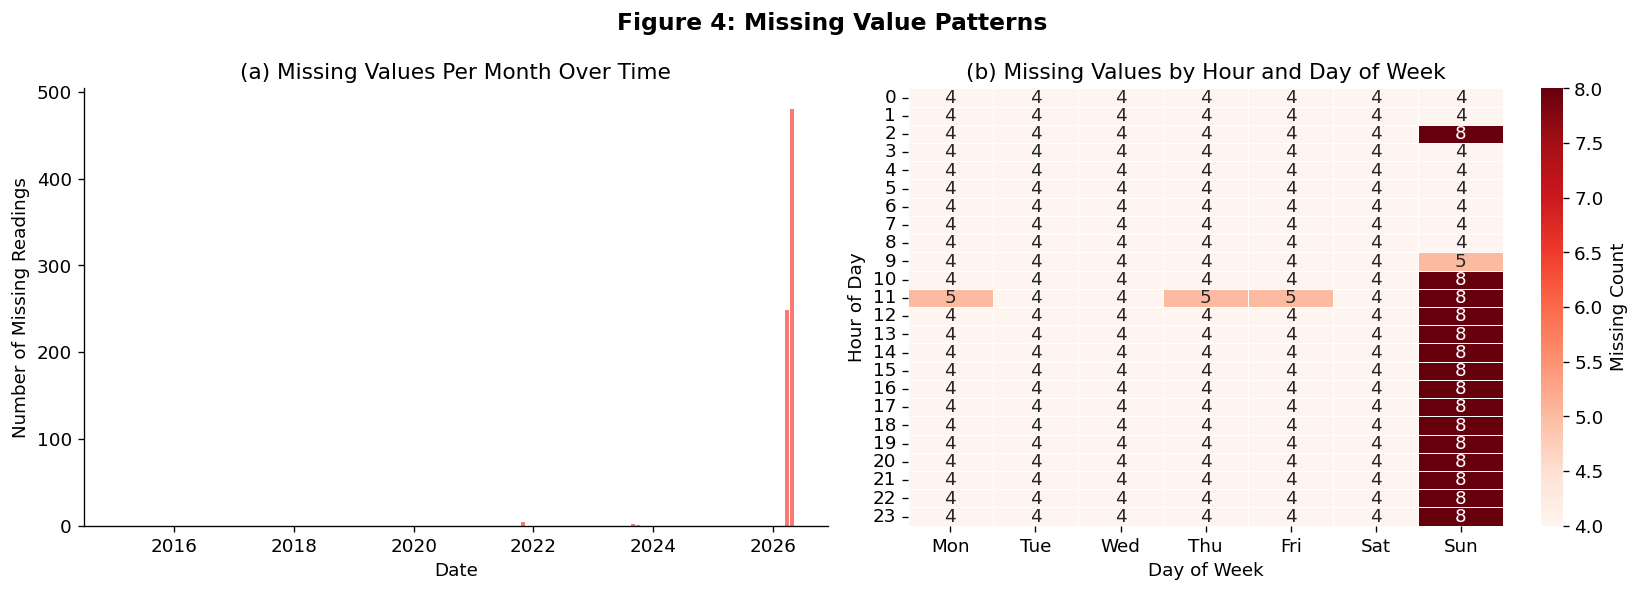

Figure 4 saved.


In [ ]:
# Figure 4: Missing value patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 4: Missing Value Patterns',
             fontsize=14, fontweight='bold')

# (a) Missing values over time — are they clustered or random?
df_raw['is_missing'] = df_raw['Total Load'].isnull().astype(int)
missing_by_month = df_raw.set_index('Datetime').resample('ME')['is_missing'].sum()
axes[0].bar(missing_by_month.index, missing_by_month.values,
            width=25, color='#F44336', alpha=0.7)
axes[0].set_title('(a) Missing Values Per Month Over Time')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Number of Missing Readings')

# (b) Missing values by hour and day of week — any systematic pattern?
missing_pivot = df_raw.pivot_table(values='is_missing', index='hour',
                                    columns='day_of_week', aggfunc='sum')
missing_pivot.columns = day_names
sns.heatmap(missing_pivot, ax=axes[1], cmap='Reds', annot=True, fmt='.0f',
            linewidths=0.5, cbar_kws={'label': 'Missing Count'})
axes[1].set_title('(b) Missing Values by Hour and Day of Week')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Hour of Day')

plt.tight_layout()
plt.savefig('fig4_missing_values.png', bbox_inches='tight', dpi=150)
plt.show()

# Clean up temporary columns
df_raw.drop(columns=['is_missing'], inplace=True)

print("Figure 4 saved.")

### 3.5 Seasonal Decomposition

We now formally decompose the time series into its three core components:
- **Trend**: the long-term direction of demand over the years
- **Seasonal**: the repeating daily pattern of demand
- **Residual**: the unpredictable noise left over after removing trend and seasonality

This decomposition directly justifies our modelling choices; models like ETS and Prophet
explicitly capture these components, while we need to verify that the LLMs can learn them implicitly.

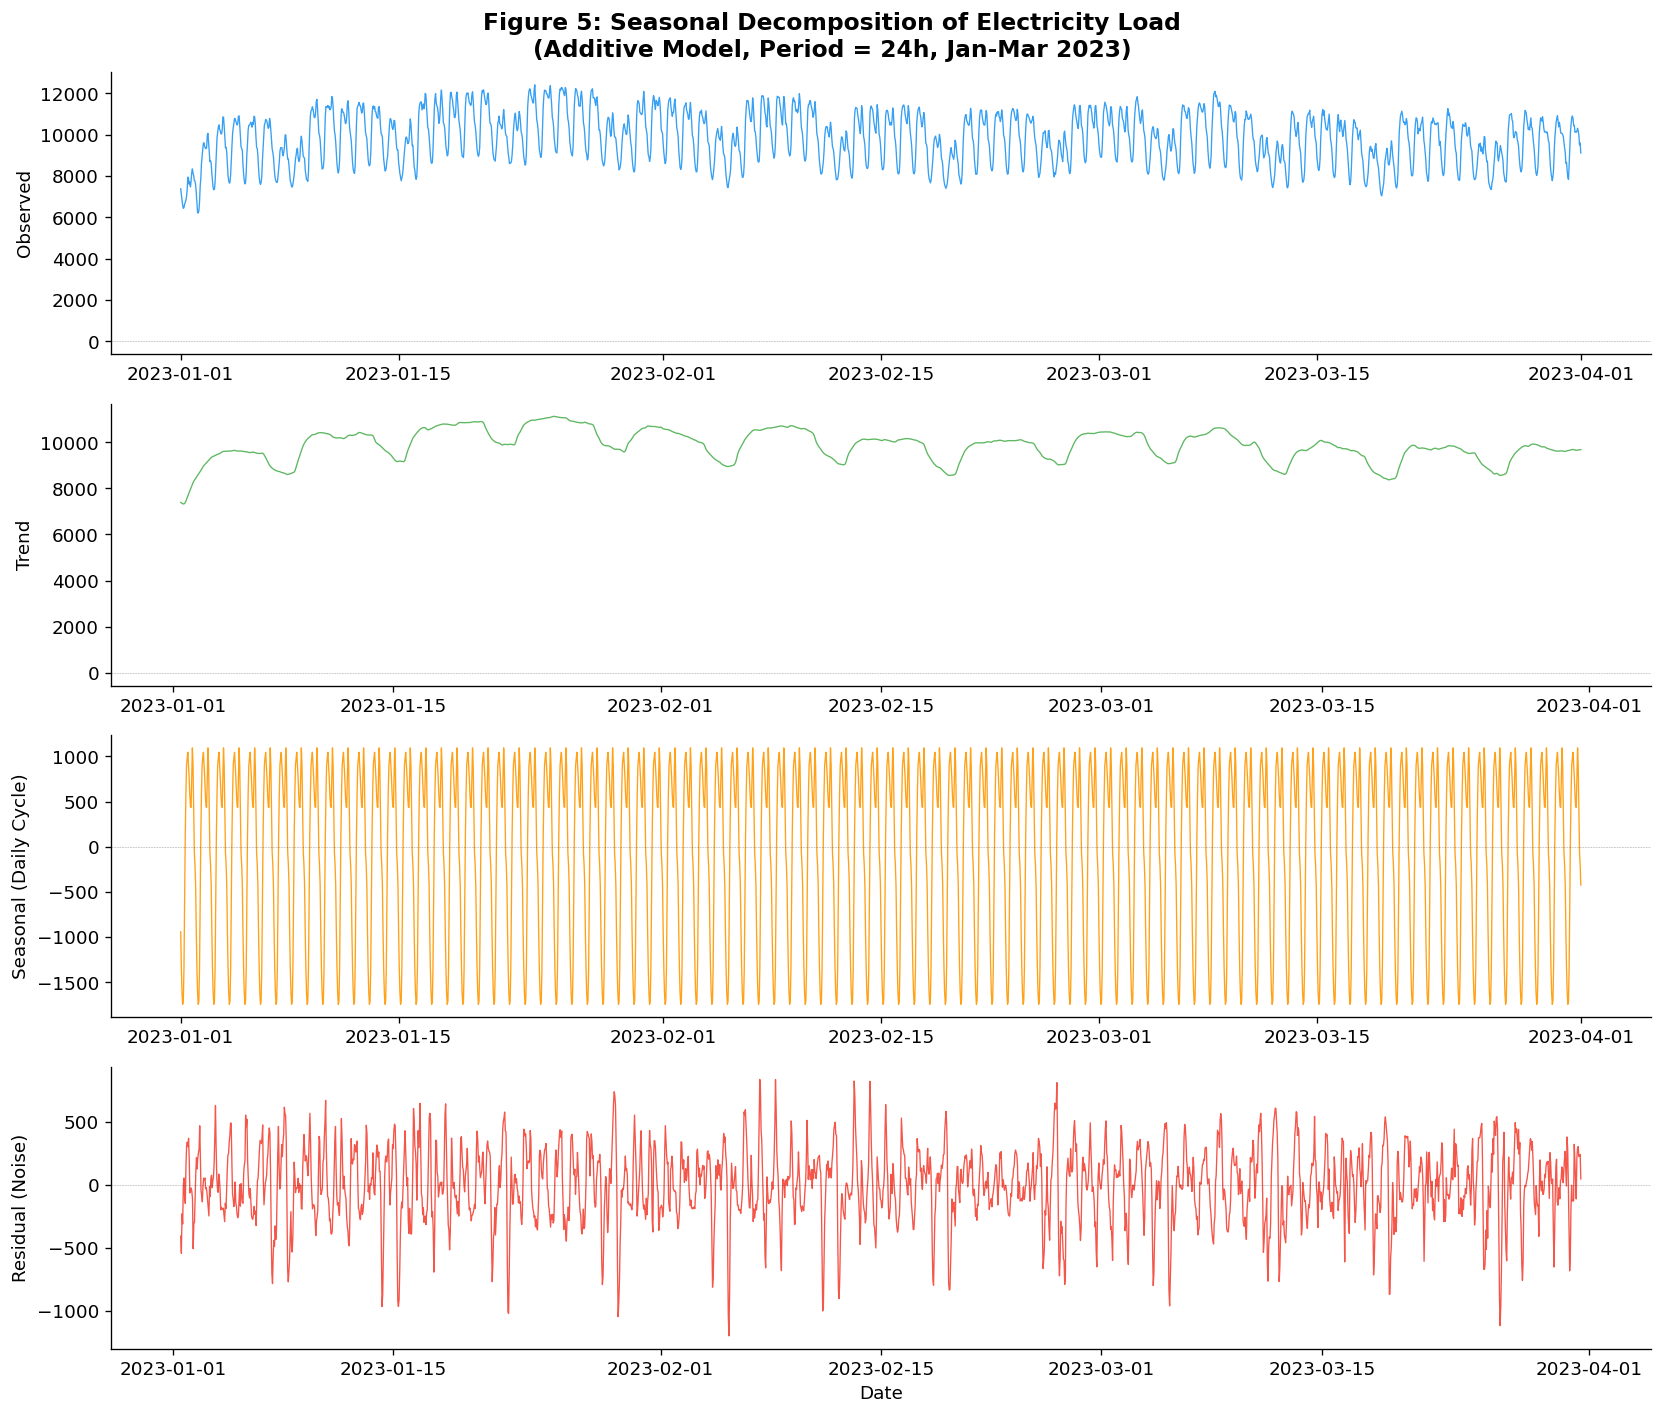

Figure 5 saved.


In [ ]:
# Figure 5: Seasonal decomposition
# We use a 90-day window of hourly-resampled data to keep the plot readable
# Period = 24 captures the dominant daily cycle

# Temporarily resample to hourly for cleaner decomposition
hourly_temp = df_raw.set_index('Datetime')['Total Load'].resample('h').mean().interpolate()

# Use 90 days of data for the decomposition plot
decomp_slice = hourly_temp['2023-01-01':'2023-03-31']

decomposition = seasonal_decompose(decomp_slice, model='additive', period=24)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
fig.suptitle('Figure 5: Seasonal Decomposition of Electricity Load\n'
             '(Additive Model, Period = 24h, Jan-Mar 2023)',
             fontsize=14, fontweight='bold')

components = [
    (decomposition.observed, 'Observed', '#2196F3'),
    (decomposition.trend, 'Trend', '#4CAF50'),
    (decomposition.seasonal, 'Seasonal (Daily Cycle)', '#FF9800'),
    (decomposition.resid, 'Residual (Noise)', '#F44336'),
]

for ax, (component, label, colour) in zip(axes, components):
    ax.plot(component, color=colour, linewidth=0.8, alpha=0.9)
    ax.set_ylabel(label)
    ax.axhline(0, color='black', linewidth=0.3, linestyle='--', alpha=0.4)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('fig5_decomposition.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure 5 saved.")

### 3.6 Autocorrelation Analysis

Autocorrelation measures how strongly a value at one time step correlates with values at
previous time steps. This analysis is critical for two reasons:

1. **It justifies our context window sizes**; if ACF shows strong correlation at lag 24 (one day)
   and lag 168 (one week), that tells us models need at least one week of history to capture
   the most important patterns.

2. **It informs our ARIMA parameters**; the PACF plot helps determine the autoregressive order.

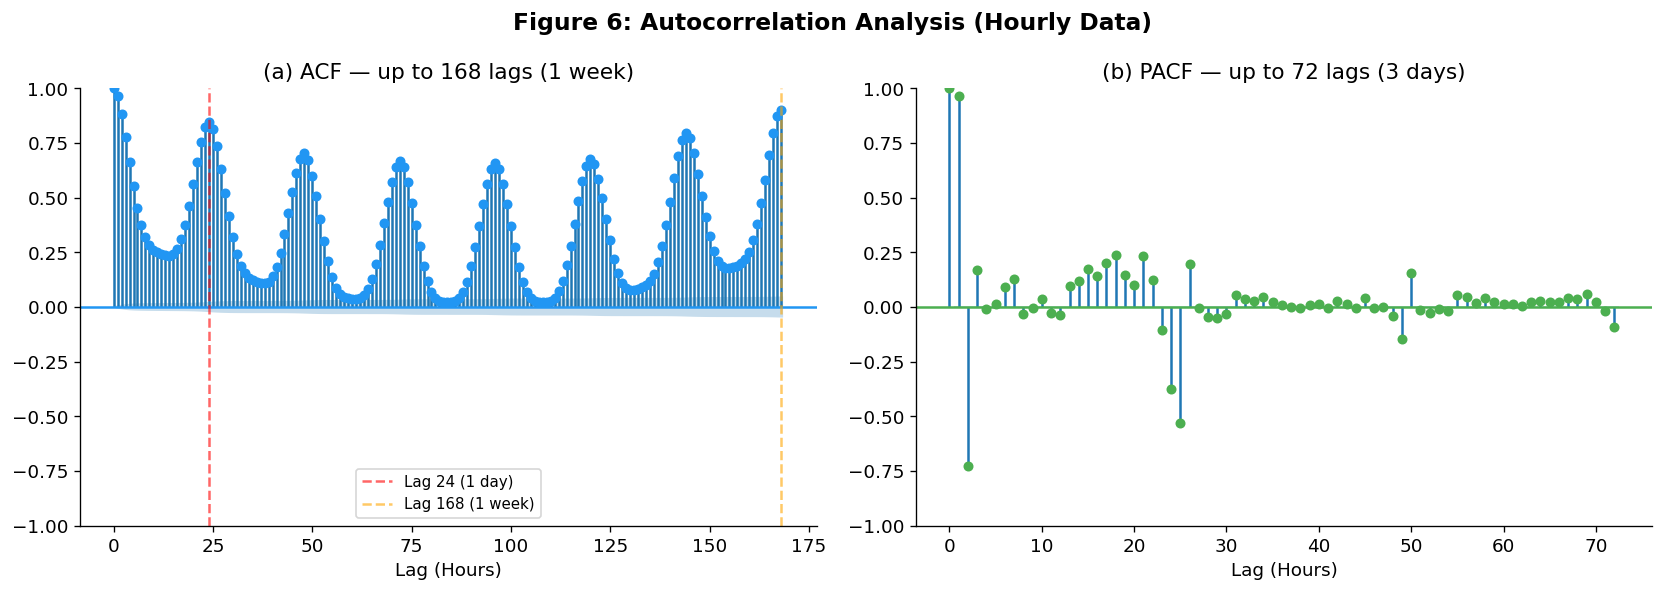


Key Autocorrelation Values:
  Lag 1   (1 hour):  0.9658
  Lag 24  (1 day):   0.8473
  Lag 48  (2 days):  0.7030
  Lag 168 (1 week):  0.9028

Figure 6 saved.


In [ ]:
# Figure 6: Autocorrelation and Partial Autocorrelation

# Use the hourly resampled data with missing values filled
acf_series = hourly_temp.dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 6: Autocorrelation Analysis (Hourly Data)',
             fontsize=14, fontweight='bold')

plot_acf(acf_series, lags=168, ax=axes[0], color='#2196F3', alpha=0.05)
axes[0].set_title('(a) ACF — up to 168 lags (1 week)')
axes[0].set_xlabel('Lag (Hours)')
axes[0].axvline(24, color='red', linestyle='--', alpha=0.6, label='Lag 24 (1 day)')
axes[0].axvline(168, color='orange', linestyle='--', alpha=0.6, label='Lag 168 (1 week)')
axes[0].legend(fontsize=9)

plot_pacf(acf_series, lags=72, ax=axes[1], color='#4CAF50', alpha=0.05, method='ywm')
axes[1].set_title('(b) PACF — up to 72 lags (3 days)')
axes[1].set_xlabel('Lag (Hours)')

plt.tight_layout()
plt.savefig('fig6_autocorrelation.png', bbox_inches='tight', dpi=150)
plt.show()

# Print key correlation values to cite in the report
acf_vals = acf(acf_series, nlags=168)
print(f"\nKey Autocorrelation Values:")
print(f"  Lag 1   (1 hour):  {acf_vals[1]:.4f}")
print(f"  Lag 24  (1 day):   {acf_vals[24]:.4f}")
print(f"  Lag 48  (2 days):  {acf_vals[48]:.4f}")
print(f"  Lag 168 (1 week):  {acf_vals[168]:.4f}")

print("\nFigure 6 saved.")

### 3.7 Stationarity Test (Augmented Dickey-Fuller)

Most classical time-series models (ARIMA, ETS) assume the series is stationary; meaning its
statistical properties (mean, variance) do not change over time. We use the Augmented Dickey-Fuller
(ADF) test to formally check this: a p-value below 0.05 means the series is stationary.

If the raw series is non-stationary, we test the first-differenced series, which tells us
whether differencing (d=1 in ARIMA) makes it stationary.

In [ ]:
# Stationarity test on the hourly resampled data
def adf_test(series, name="Series"):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f"\nAugmented Dickey-Fuller Test — {name}")
    print(f"{'=' * 45}")
    print(f"  Test Statistic:  {result[0]:.6f}")
    print(f"  p-value:         {result[1]:.6f}")
    print(f"  Lags Used:       {result[2]}")
    print(f"  Observations:    {result[3]}")
    print(f"\n  Critical Values:")
    for key, val in result[4].items():
        print(f"    {key}: {val:.6f}")

    if result[1] < 0.05:
        print(f"\n  STATIONARY (p < 0.05) — safe to model directly")
    else:
        print(f"\n  NON-STATIONARY (p >= 0.05) — differencing needed")

    return result[1] < 0.05

is_stationary = adf_test(acf_series, "Total Load (Hourly)")

if not is_stationary:
    adf_test(acf_series.diff().dropna(), "Total Load — First Difference")


Augmented Dickey-Fuller Test — Total Load (Hourly)
  Test Statistic:  -14.311858
  p-value:         0.000000
  Lags Used:       68
  Observations:    98643

  Critical Values:
    1%: -3.430416
    5%: -2.861569
    10%: -2.566786

  STATIONARY (p < 0.05) — safe to model directly


### 3.8 EDA Summary

This section summarises the key findings from our exploratory analysis. These values
will be cited directly in the dissertation and used to justify modelling decisions.

In [ ]:
# EDA Summary — key values to reference in the dissertation
print('=' * 55)
print('EDA SUMMARY')
print('=' * 55)
print(f'Total observations (15-min): {len(df_raw):,}')
print(f'Date range:                  {df_raw["Datetime"].min().date()} to {df_raw["Datetime"].max().date()}')
print(f'Mean load:                   {df_raw["Total Load"].mean():.2f} MW')
print(f'Std deviation:               {df_raw["Total Load"].std():.2f} MW')
print(f'Min / Max:                   {df_raw["Total Load"].min():.2f} / {df_raw["Total Load"].max():.2f} MW')
print(f'Missing values:              {df_raw["Total Load"].isnull().sum()} ({df_raw["Total Load"].isnull().mean()*100:.2f}%)')
print(f'Skewness:                    {df_raw["Total Load"].skew():.4f}')
print(f'ACF at lag 24 (1 day):       {acf_vals[24]:.4f}')
print(f'ACF at lag 168 (1 week):     {acf_vals[168]:.4f}')
print(f'\nFigures saved: fig1 through fig6')
print(f'All figures must be cited by number in the report.')

EDA SUMMARY
Total observations (15-min): 394,844
Date range:                  2015-01-01 to 2026-04-05
Mean load:                   9581.75 MW
Std deviation:               1400.06 MW
Min / Max:                   5877.45 / 14356.68 MW
Missing values:              736 (0.19%)
Skewness:                    0.1324
ACF at lag 24 (1 day):       0.8473
ACF at lag 168 (1 week):     0.9028

Figures saved: fig1 through fig6
All figures must be cited by number in the report.


## 4. Data Preprocessing

The EDA confirmed that the raw dataset is at 15-minute resolution with 736 missing values (0.19%)
and strong daily/weekly autocorrelation. Before modelling, we apply the following pipeline:

1. **Resample to hourly** — standard in energy forecasting literature, reduces computational cost
   without losing meaningful patterns (Haben et al., 2019)
2. **Impute missing values** — linear interpolation preserves local trend better than forward-fill
3. **Detect outliers** — flag extreme values using domain-informed IQR bounds
4. **Engineer features** — calendar features and lagged values for the ML models (XGBoost)
5. **Split chronologically** — 70% train / 15% validation / 15% test, respecting temporal order
6. **Scale** — StandardScaler fitted on training data only, applied to all splits (for LSTM / Time-LLM)

### 4.1 Resample to Hourly Resolution

We aggregate the four 15-minute readings per hour into a single hourly mean. This is the
standard resolution used in grid-level energy forecasting studies. The
resampling reduces the dataset from ~395k rows to ~99k rows while preserving all temporal patterns
identified in Section 3.

In [ ]:
# Resample 15-min data to hourly using mean aggregation
df_hourly = (
    df_raw
    .set_index('Datetime')
    [['Total Load']]           # Keep only the target variable
    .resample('h')
    .mean()
)

print('=' * 55)
print('RESAMPLING: 15-min → Hourly')
print('=' * 55)
print(f'Original rows (15-min): {len(df_raw):,}')
print(f'Hourly rows:            {len(df_hourly):,}')
print(f'Expected:               ~{len(df_raw) // 4:,} (÷4)')
print(f'Date range:             {df_hourly.index.min()} to {df_hourly.index.max()}')

# Check for missing hours after resampling
full_range = pd.date_range(df_hourly.index.min(), df_hourly.index.max(), freq='h')
n_missing_hours = len(full_range) - len(df_hourly)
n_nan = df_hourly['Total Load'].isnull().sum()
print(f'\nMissing timestamps:     {n_missing_hours}')
print(f'NaN values after resample: {n_nan} ({n_nan/len(df_hourly)*100:.3f}%)')

RESAMPLING: 15-min → Hourly
Original rows (15-min): 394,844
Hourly rows:            98,712
Expected:               ~98,711 (÷4)
Date range:             2015-01-01 00:00:00 to 2026-04-05 23:00:00

Missing timestamps:     0
NaN values after resample: 194 (0.197%)


### 4.2 Missing Value Imputation

With only ~0.19% missing values and small scattered gaps confirmed in Figure 4, linear
interpolation is appropriate. It estimates missing values by drawing a straight line between the
nearest known points on either side, preserving the local trend. We set a maximum gap limit of
6 hours; any gap longer than that would be suspicious and should be investigated manually.

In [ ]:
# Reindex to ensure every hour is present, then interpolate
df_hourly = df_hourly.reindex(full_range)
df_hourly.index.name = 'Datetime'

# Count NaNs before imputation
nan_before = df_hourly['Total Load'].isnull().sum()

# Linear interpolation with a 6-hour max gap
df_hourly['Total Load'] = df_hourly['Total Load'].interpolate(
    method='linear', limit=6, limit_direction='both'
)

nan_after = df_hourly['Total Load'].isnull().sum()

print('=' * 55)
print('MISSING VALUE IMPUTATION')
print('=' * 55)
print(f'NaN before imputation: {nan_before}')
print(f'NaN after imputation:  {nan_after}')
print(f'Values filled:         {nan_before - nan_after}')

if nan_after > 0:
    print(f'\n⚠ {nan_after} values remain unfilled (gaps > 6h). Dropping them.')
    df_hourly = df_hourly.dropna(subset=['Total Load'])
else:
    print('\nAll missing values successfully imputed.')

print(f'Final hourly dataset:  {len(df_hourly):,} rows')
print(f'Date range:            {df_hourly.index.min()} to {df_hourly.index.max()}')

MISSING VALUE IMPUTATION
NaN before imputation: 194
NaN after imputation:  176
Values filled:         18

⚠ 176 values remain unfilled (gaps > 6h). Dropping them.
Final hourly dataset:  98,536 rows
Date range:            2015-01-01 00:00:00 to 2026-03-29 15:00:00


### 4.3 Outlier Detection

We flag extreme values using the Interquartile Range (IQR) method, which is robust to the
distribution shape. Values beyond 3× IQR from the quartiles are flagged. We keep these values
rather than removing them; in energy data, extreme loads during cold snaps or heatwaves are
genuine events, not measurement errors. Flagging them here allows us to discuss model behaviour
on extreme values in the results section.

In [ ]:
# IQR-based outlier detection (3x IQR — conservative threshold)
Q1 = df_hourly['Total Load'].quantile(0.25)
Q3 = df_hourly['Total Load'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

outliers = (df_hourly['Total Load'] < lower_bound) | (df_hourly['Total Load'] > upper_bound)
n_outliers = outliers.sum()

print('=' * 55)
print('OUTLIER DETECTION (3× IQR)')
print('=' * 55)
print(f'Q1: {Q1:.2f} MW    Q3: {Q3:.2f} MW    IQR: {IQR:.2f} MW')
print(f'Lower bound: {lower_bound:.2f} MW')
print(f'Upper bound: {upper_bound:.2f} MW')
print(f'Outliers found: {n_outliers} ({n_outliers/len(df_hourly)*100:.3f}%)')

if n_outliers > 0:
    print(f'\nOutlier range: {df_hourly.loc[outliers, "Total Load"].min():.2f} — '
          f'{df_hourly.loc[outliers, "Total Load"].max():.2f} MW')
    print('Outliers retained — extreme loads are genuine operational events.')
else:
    print('\nNo extreme outliers detected within 3× IQR.')

OUTLIER DETECTION (3× IQR)
Q1: 8493.20 MW    Q3: 10606.27 MW    IQR: 2113.07 MW
Lower bound: 2154.00 MW
Upper bound: 16945.47 MW
Outliers found: 0 (0.000%)

No extreme outliers detected within 3× IQR.


### 4.4 Feature Engineering

For the tree-based model (XGBoost), we create tabular features that encode the temporal patterns
discovered during EDA:

- **Calendar features**: hour of day, day of week, month, weekend indicator; capture the strong
  daily and weekly seasonality (Figure 3)
- **Lag features**: load at t-1, t-24, t-168; exploit the high autocorrelation at 1h, 1-day,
  and 1-week lags (Figure 6, ACF values 0.97, 0.85, 0.90)
- **Rolling statistics**: 24h and 168h rolling mean and std; give models access to recent
  trend and volatility information

These features are only used by XGBoost. The sequential models (LSTM, Time-LLM) and
statistical models (ETS, ARIMA, Prophet) each have their own input formats.

In [ ]:
# Build feature dataframe for tabular models (XGBoost)
df_feat = df_hourly.copy()

# Calendar features
df_feat['hour'] = df_feat.index.hour
df_feat['day_of_week'] = df_feat.index.dayofweek
df_feat['month'] = df_feat.index.month
df_feat['is_weekend'] = (df_feat['day_of_week'] >= 5).astype(int)

# Lag features — based on EDA autocorrelation analysis
df_feat['lag_1'] = df_feat['Total Load'].shift(1)       # Previous hour
df_feat['lag_24'] = df_feat['Total Load'].shift(24)      # Same hour yesterday
df_feat['lag_168'] = df_feat['Total Load'].shift(168)    # Same hour last week

# Rolling statistics — capture recent trend and volatility
df_feat['roll_mean_24'] = df_feat['Total Load'].shift(1).rolling(24).mean()
df_feat['roll_std_24'] = df_feat['Total Load'].shift(1).rolling(24).std()
df_feat['roll_mean_168'] = df_feat['Total Load'].shift(1).rolling(168).mean()
df_feat['roll_std_168'] = df_feat['Total Load'].shift(1).rolling(168).std()

# Drop rows with NaN from lagging and rolling (first 168 rows)
n_before = len(df_feat)
df_feat = df_feat.dropna()
n_after = len(df_feat)

print('=' * 55)
print('FEATURE ENGINEERING')
print('=' * 55)
print(f'Features created: {len(df_feat.columns) - 1}')
for col in df_feat.columns:
    if col != 'Total Load':
        print(f'  {col}')
print(f'\nRows before lag/rolling drop: {n_before:,}')
print(f'Rows after (usable):          {n_after:,}')
print(f'Rows lost (warm-up period):   {n_before - n_after}')

FEATURE ENGINEERING
Features created: 11
  hour
  day_of_week
  month
  is_weekend
  lag_1
  lag_24
  lag_168
  roll_mean_24
  roll_std_24
  roll_mean_168
  roll_std_168

Rows before lag/rolling drop: 98,536
Rows after (usable):          98,368
Rows lost (warm-up period):   168


### 4.5 Chronological Train / Validation / Test Split

Time-series data must be split chronologically — never shuffled randomly — to prevent future
information leaking into training. We use a 70/15/15 split:

- **Training set (70%)**: the model learns patterns from this period
- **Validation set (15%)**: used for hyperparameter tuning and early stopping
- **Test set (15%)**: held out completely until final evaluation; reported results come from here only

This split is applied consistently across all models so that every model is compared fairly
on exactly the same test period.

In [ ]:
# Chronological split on the clean hourly series (used by all models)
n = len(df_hourly)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_series = df_hourly.iloc[:train_end]
val_series = df_hourly.iloc[train_end:val_end]
test_series = df_hourly.iloc[val_end:]

print('=' * 55)
print('CHRONOLOGICAL SPLIT — Hourly Series')
print('=' * 55)
print(f'{"Split":<12} {"Rows":>8} {"Start":<22} {"End":<22}')
print('-' * 65)
print(f'{"Train":<12} {len(train_series):>8,} {str(train_series.index.min()):<22} {str(train_series.index.max()):<22}')
print(f'{"Validation":<12} {len(val_series):>8,} {str(val_series.index.min()):<22} {str(val_series.index.max()):<22}')
print(f'{"Test":<12} {len(test_series):>8,} {str(test_series.index.min()):<22} {str(test_series.index.max()):<22}')
print('-' * 65)
print(f'{"Total":<12} {n:>8,}')

# Also split the featured dataframe (for XGBoost)
# Align on the same date boundaries
train_feat = df_feat.loc[df_feat.index < val_series.index.min()]
val_feat = df_feat.loc[(df_feat.index >= val_series.index.min()) & (df_feat.index < test_series.index.min())]
test_feat = df_feat.loc[df_feat.index >= test_series.index.min()]

print(f'\nFeatured dataframe split (XGBoost):')
print(f'  Train: {len(train_feat):,}   Val: {len(val_feat):,}   Test: {len(test_feat):,}')

CHRONOLOGICAL SPLIT — Hourly Series
Split            Rows Start                  End                   
-----------------------------------------------------------------
Train          68,975 2015-01-01 00:00:00    2022-11-13 22:00:00   
Validation     14,780 2022-11-13 23:00:00    2024-07-21 18:00:00   
Test           14,781 2024-07-21 19:00:00    2026-03-29 15:00:00   
-----------------------------------------------------------------
Total          98,536

Featured dataframe split (XGBoost):
  Train: 68,807   Val: 14,780   Test: 14,781


### 4.6 Feature Scaling

Neural network models (LSTM) and the Time-LLM reprogramming layer are sensitive to feature magnitudes.
We apply StandardScaler (zero mean, unit variance) fitted **only** on the training set to prevent
data leakage. The scaler is saved so we can inverse-transform predictions back to MW for evaluation.

Statistical models (ETS, ARIMA, Prophet) and XGBoost operate on unscaled data.

In [ ]:
# Fit scaler on training data only
scaler = StandardScaler()
scaler.fit(train_series[['Total Load']])

# Transform all splits
train_scaled = scaler.transform(train_series[['Total Load']])
val_scaled = scaler.transform(val_series[['Total Load']])
test_scaled = scaler.transform(test_series[['Total Load']])

print('=' * 55)
print('FEATURE SCALING (StandardScaler)')
print('=' * 55)
print(f'Fitted on training set only ({len(train_series):,} rows)')
print(f'Training mean:  {scaler.mean_[0]:.2f} MW')
print(f'Training std:   {scaler.scale_[0]:.2f} MW')
print(f'\nScaled statistics:')
print(f'  Train  — mean: {train_scaled.mean():.4f}  std: {train_scaled.std():.4f}')
print(f'  Val    — mean: {val_scaled.mean():.4f}  std: {val_scaled.std():.4f}')
print(f'  Test   — mean: {test_scaled.mean():.4f}  std: {test_scaled.std():.4f}')
print(f'\nScaler saved for inverse transform during evaluation.')

FEATURE SCALING (StandardScaler)
Fitted on training set only (68,975 rows)
Training mean:  9726.58 MW
Training std:   1371.16 MW

Scaled statistics:
  Train  — mean: 0.0000  std: 1.0000
  Val    — mean: -0.4209  std: 0.9852
  Test   — mean: -0.2832  std: 1.0401

Scaler saved for inverse transform during evaluation.


### 4.7 Preprocessing Summary

Below is the final state of the data after all preprocessing steps. These exact numbers
will be referenced in the Methodology of the dissertation.

In [ ]:
# Preprocessing Summary
print('=' * 55)
print('PREPROCESSING SUMMARY')
print('=' * 55)
print(f'Original resolution:    15-min ({len(df_raw):,} rows)')
print(f'Resampled resolution:   Hourly ({len(df_hourly):,} rows)')
print(f'Missing values filled:  {nan_before} → {nan_after} (linear interpolation, max gap 6h)')
print(f'Outliers detected:      {n_outliers} (retained — genuine events)')
print(f'Features engineered:    {len(df_feat.columns) - 1} (for XGBoost)')
print(f'Scaler:                 StandardScaler (mean={scaler.mean_[0]:.2f}, std={scaler.scale_[0]:.2f})')
print(f'\nChronological Split:')
print(f'  Train:      {len(train_series):>8,} hours  ({train_series.index.min().date()} to {train_series.index.max().date()})')
print(f'  Validation: {len(val_series):>8,} hours  ({val_series.index.min().date()} to {val_series.index.max().date()})')
print(f'  Test:       {len(test_series):>8,} hours  ({test_series.index.min().date()} to {test_series.index.max().date()})')
print(f'\nKey objects for modelling:')
print(f'  df_hourly      — clean hourly series (all models)')
print(f'  df_feat         — featured dataframe (XGBoost)')
print(f'  train/val/test_series  — split hourly series')
print(f'  train/val/test_feat    — split featured dataframe')
print(f'  scaler          — StandardScaler for LSTM / Time-LLM')
print(f'  train/val/test_scaled  — scaled arrays for LSTM / Time-LLM')
print(f'\nPreprocessing complete. Ready for modelling.')

PREPROCESSING SUMMARY
Original resolution:    15-min (394,844 rows)
Resampled resolution:   Hourly (98,536 rows)
Missing values filled:  194 → 176 (linear interpolation, max gap 6h)
Outliers detected:      0 (retained — genuine events)
Features engineered:    11 (for XGBoost)
Scaler:                 StandardScaler (mean=9726.58, std=1371.16)

Chronological Split:
  Train:        68,975 hours  (2015-01-01 to 2022-11-13)
  Validation:   14,780 hours  (2022-11-13 to 2024-07-21)
  Test:         14,781 hours  (2024-07-21 to 2026-03-29)

Key objects for modelling:
  df_hourly      — clean hourly series (all models)
  df_feat         — featured dataframe (XGBoost)
  train/val/test_series  — split hourly series
  train/val/test_feat    — split featured dataframe
  scaler          — StandardScaler for LSTM / Time-LLM
  train/val/test_scaled  — scaled arrays for LSTM / Time-LLM

Preprocessing complete. Ready for modelling.


## 5. Evaluation Framework

Before training any models, we define all evaluation metrics, shared constants, and a
reusable scoring function. This ensures every model is measured identically; no
inconsistencies in how performance is computed or reported.

**Metrics (consistent with energy forecasting literature):**
- **MAE** — Mean Absolute Error (MW): average magnitude of forecast error
- **RMSE** — Root Mean Squared Error (MW): penalises large errors more heavily
- **sMAPE** — Symmetric Mean Absolute Percentage Error (%): scale-independent accuracy
- **MASE** — Mean Absolute Scaled Error: error relative to a naive seasonal baseline;
  values below 1.0 mean the model beats naive persistence

All metrics are computed over non-overlapping rolling windows on the **test set only**.
The training and validation sets are never included in reported scores.

In [ ]:
import time

# ─── Evaluation Metrics ────────────────────────────────────────────

def calc_mae(actual, predicted):
    return np.mean(np.abs(actual - predicted))

def calc_rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

def calc_smape(actual, predicted):
    denom = (np.abs(actual) + np.abs(predicted)) / 2
    mask = denom > 0
    return np.mean(np.abs(actual[mask] - predicted[mask]) / denom[mask]) * 100

def calc_mase(actual, predicted, naive_mae):
    return calc_mae(actual, predicted) / naive_mae

# ─── MASE Denominator ─────────────────────────────────────────────
# MAE of the naive seasonal (lag-24) forecast on the training set.
# This is the standard denominator for MASE in hourly energy data.
train_vals = train_series['Total Load'].values
naive_errors_train = np.abs(train_vals[24:] - train_vals[:-24])
NAIVE_MAE_TRAIN = np.mean(naive_errors_train)

# ─── Results Storage ──────────────────────────────────────────────
results = []

def evaluate_model(model_name, horizon, actuals_list, preds_list, config='Fixed'):
    """Compute all four metrics and append to the results list."""
    all_actual = np.concatenate(actuals_list)
    all_pred   = np.concatenate(preds_list)

    row = {
        'Model':    model_name,
        'Config':   config,
        'Horizon':  f'{horizon}h',
        'MAE (MW)': round(calc_mae(all_actual, all_pred), 2),
        'RMSE (MW)':round(calc_rmse(all_actual, all_pred), 2),
        'sMAPE (%)':round(calc_smape(all_actual, all_pred), 2),
        'MASE':     round(calc_mase(all_actual, all_pred, NAIVE_MAE_TRAIN), 4),
        'Windows':  len(actuals_list),
    }
    results.append(row)

    print(f'\n  {model_name} — {horizon}h Horizon ({config})')
    print(f'  {"─" * 42}')
    print(f'  MAE:   {row["MAE (MW)"]:>10} MW')
    print(f'  RMSE:  {row["RMSE (MW)"]:>10} MW')
    print(f'  sMAPE: {row["sMAPE (%)"]:>10} %')
    print(f'  MASE:  {row["MASE"]:>10}')
    print(f'  Windows evaluated: {len(actuals_list)}')
    return row

# ─── Shared Constants ─────────────────────────────────────────────
CONTEXT_LEN = 720          # 30 days of hourly history for model fitting
HORIZONS    = [24, 48]     # forecast horizons in hours

full_vals      = df_hourly['Total Load'].values
test_start_pos = len(train_series) + len(val_series)

# Verify test set continuity
test_expected = pd.date_range(test_series.index.min(),
                              test_series.index.max(), freq='h')
test_gap_count = len(test_expected) - len(test_series)

print('=' * 55)
print('EVALUATION FRAMEWORK')
print('=' * 55)
print(f'MASE denominator (naive lag-24 MAE): {NAIVE_MAE_TRAIN:.2f} MW')
print(f'Context length for model fitting:    {CONTEXT_LEN} hours (30 days)')
print(f'Test set size:  {len(test_series):,} hours')
if test_gap_count > 0:
    print(f'Test set gaps:  {test_gap_count} missing hours (noted as limitation)')
else:
    print(f'Test set gaps:  none — continuous index')
print(f'Horizons:       {HORIZONS}')
print(f'Metrics:        MAE, RMSE, sMAPE, MASE')
print(f'\nEvaluation framework ready.')

EVALUATION FRAMEWORK
MASE denominator (naive lag-24 MAE): 538.79 MW
Context length for model fitting:    720 hours (30 days)
Test set size:  14,781 hours
Test set gaps:  none — continuous index
Horizons:       [24, 48]
Metrics:        MAE, RMSE, sMAPE, MASE

Evaluation framework ready.


## 6. Statistical and ML Baseline Models

We evaluate four increasingly sophisticated baselines before introducing the LLM models.
This establishes a performance ladder against which the LLMs are compared:

1. **Naive Persistence** — simplest possible: repeat yesterday's load
2. **ETS (Holt-Winters)** — classical exponential smoothing with explicit seasonality
3. **ARIMA** — autoregressive model selected by AIC on the training data

Each model is evaluated with **rolling non-overlapping windows** across the full test set
for both 24-hour and 48-hour forecast horizons.

### 6.1 Naive Persistence

The naive seasonal baseline repeats the most recent 24-hour load profile into the future.
For a 48-hour horizon, the last 24 hours are tiled twice. This is the simplest possible
forecasting method and serves as the lower bound; any useful model must beat this.

The MASE metric uses this model's training-set MAE as its denominator, so a MASE of exactly 1.0
corresponds to naive performance. Values below 1.0 indicate improvement over naive.

In [ ]:
# ─── Model 1: Naive Persistence ──────────────────────────────────
print('=' * 55)
print('MODEL 1: Naive Persistence')
print('=' * 55)
print('Strategy: tile the most recent 24 hours of observed load\n')

for horizon in HORIZONS:
    actuals, preds = [], []

    for i in range(test_start_pos, len(full_vals) - horizon + 1, horizon):
        actual = full_vals[i:i + horizon]
        # Repeat the last full day
        last_day = full_vals[i - 24:i]
        pred = np.tile(last_day, int(np.ceil(horizon / 24)))[:horizon]
        actuals.append(actual)
        preds.append(pred)

    evaluate_model('Naive Persistence', horizon, actuals, preds)

print(f'\nResults recorded: {len(results)}')

MODEL 1: Naive Persistence
Strategy: tile the most recent 24 hours of observed load


  Naive Persistence — 24h Horizon (Fixed)
  ──────────────────────────────────────────
  MAE:       504.69 MW
  RMSE:      730.05 MW
  sMAPE:       5.42 %
  MASE:      0.9367
  Windows evaluated: 615

  Naive Persistence — 48h Horizon (Fixed)
  ──────────────────────────────────────────
  MAE:       631.69 MW
  RMSE:      871.46 MW
  sMAPE:       6.78 %
  MASE:      1.1724
  Windows evaluated: 307

Results recorded: 2


### 6.2 ETS (Holt-Winters Exponential Smoothing)

Exponential Triple Smoothing (ETS) explicitly decomposes the series into level, trend, and
seasonal components — directly reflecting the structure confirmed by the seasonal decomposition
in Figure 5. We use:
- **Additive trend** — the long-term level shifts gradually
- **Additive seasonality** with period 24 — the daily cycle identified in Figures 3 and 6
- **Fitting window**: 720 hours (30 days) of the most recent history at each forecast origin

The model is refit at each rolling window to adapt to the most recent patterns.

In [ ]:
# ─── Model 2: ETS (Holt-Winters) ─────────────────────────────────
print('=' * 55)
print('MODEL 2: ETS (Holt-Winters)')
print('=' * 55)
print(f'Config: additive trend + additive seasonality (period=24)')
print(f'Fitting window: {CONTEXT_LEN} hours\n')

def ets_forecast(history, horizon):
    """Fit Holt-Winters on history and forecast horizon steps."""
    try:
        model = ExponentialSmoothing(
            history, trend='add', seasonal='add', seasonal_periods=24
        ).fit(optimized=True, use_brute=False)
        return model.forecast(horizon)
    except Exception:
        # Fallback: trend only (no seasonality) if convergence fails
        try:
            model = ExponentialSmoothing(
                history, trend='add', seasonal=None
            ).fit(optimized=True)
            return model.forecast(horizon)
        except Exception:
            return np.full(horizon, np.mean(history[-24:]))

for horizon in HORIZONS:
    actuals, preds = [], []
    t0 = time.time()
    n_total = (len(full_vals) - test_start_pos - horizon) // horizon + 1

    for idx, i in enumerate(range(test_start_pos, len(full_vals) - horizon + 1, horizon)):
        history = full_vals[max(0, i - CONTEXT_LEN):i]
        actual  = full_vals[i:i + horizon]
        pred    = ets_forecast(history, horizon)
        actuals.append(actual)
        preds.append(pred)

        if (idx + 1) % 100 == 0:
            print(f'  [{idx+1}/{n_total}] windows done ({time.time()-t0:.0f}s)')

    elapsed = time.time() - t0
    print(f'  ETS {horizon}h complete: {len(actuals)} windows in {elapsed:.1f}s')
    evaluate_model('ETS (Holt-Winters)', horizon, actuals, preds)

print(f'\nResults recorded: {len(results)}')

MODEL 2: ETS (Holt-Winters)
Config: additive trend + additive seasonality (period=24)
Fitting window: 720 hours

  [100/615] windows done (35s)
  [200/615] windows done (82s)
  [300/615] windows done (122s)
  [400/615] windows done (160s)
  [500/615] windows done (190s)
  [600/615] windows done (227s)
  ETS 24h complete: 615 windows in 233.0s

  ETS (Holt-Winters) — 24h Horizon (Fixed)
  ──────────────────────────────────────────
  MAE:       520.74 MW
  RMSE:      765.09 MW
  sMAPE:       5.59 %
  MASE:      0.9665
  Windows evaluated: 615
  [100/307] windows done (40s)
  [200/307] windows done (77s)
  [300/307] windows done (111s)
  ETS 48h complete: 307 windows in 113.3s

  ETS (Holt-Winters) — 48h Horizon (Fixed)
  ──────────────────────────────────────────
  MAE:       724.75 MW
  RMSE:     1266.37 MW
  sMAPE:       7.55 %
  MASE:      1.3451
  Windows evaluated: 307

Results recorded: 4


### 6.3 ARIMA

ARIMA (AutoRegressive Integrated Moving Average) models the series using past values (AR)
and past forecast errors (MA). The ADF test in Section 3.7 confirmed stationarity
(p ≈ 0), so we fix d = 0 (no differencing needed). The AR and MA orders (p, q) are selected
via an AIC-based grid search on a training sample.

**Limitation:** ARIMA does not include an explicit seasonal component (SARIMA with period 24
is computationally prohibitive for rolling evaluation). Daily seasonality is instead captured
by the ETS and Prophet baselines.

In [ ]:
# ─── Model 3: ARIMA ──────────────────────────────────────────────
print('=' * 55)
print('MODEL 3: ARIMA — Order Selection')
print('=' * 55)
print('Grid search over p=1..5, d=0 (stationary), q=0..3')
print('Evaluated on last 30 days of training data via AIC\n')

sample = train_series['Total Load'].values[-CONTEXT_LEN:]
best_aic, best_order = np.inf, (1, 0, 1)

for p in range(1, 6):
    for q in range(0, 4):
        try:
            aic = ARIMA(sample, order=(p, 0, q)).fit().aic
            if aic < best_aic:
                best_aic, best_order = aic, (p, 0, q)
        except Exception:
            pass

print(f'Selected order:  ARIMA{best_order}')
print(f'AIC:             {best_aic:.1f}')
print(f'd=0 justified by ADF test (Section 3.7, p < 0.001)')
print(f'Fitting window:  {CONTEXT_LEN} hours\n')

# Rolling evaluation
def arima_forecast(history, horizon, order):
    """Fit ARIMA and forecast horizon steps."""
    try:
        model = ARIMA(history, order=order).fit()
        return model.forecast(horizon)
    except Exception:
        return np.full(horizon, np.mean(history[-24:]))

for horizon in HORIZONS:
    actuals, preds = [], []
    t0 = time.time()
    n_total = (len(full_vals) - test_start_pos - horizon) // horizon + 1

    for idx, i in enumerate(range(test_start_pos, len(full_vals) - horizon + 1, horizon)):
        history = full_vals[max(0, i - CONTEXT_LEN):i]
        actual  = full_vals[i:i + horizon]
        pred    = arima_forecast(history, horizon, best_order)
        actuals.append(actual)
        preds.append(pred)

        if (idx + 1) % 100 == 0:
            print(f'  [{idx+1}/{n_total}] windows done ({time.time()-t0:.0f}s)')

    elapsed = time.time() - t0
    print(f'  ARIMA {horizon}h complete: {len(actuals)} windows in {elapsed:.1f}s')
    evaluate_model('ARIMA', horizon, actuals, preds)

print(f'\nResults recorded: {len(results)}')

MODEL 3: ARIMA — Order Selection
Grid search over p=1..5, d=0 (stationary), q=0..3
Evaluated on last 30 days of training data via AIC

Selected order:  ARIMA(5, 0, 3)
AIC:             9842.0
d=0 justified by ADF test (Section 3.7, p < 0.001)
Fitting window:  720 hours

  [100/615] windows done (133s)
  [200/615] windows done (273s)
  [300/615] windows done (401s)
  [400/615] windows done (543s)
  [500/615] windows done (681s)
  [600/615] windows done (816s)
  ARIMA 24h complete: 615 windows in 835.8s

  ARIMA — 24h Horizon (Fixed)
  ──────────────────────────────────────────
  MAE:      1047.57 MW
  RMSE:     1254.23 MW
  sMAPE:      11.23 %
  MASE:      1.9443
  Windows evaluated: 615
  [100/307] windows done (145s)
  [200/307] windows done (280s)
  [300/307] windows done (419s)
  ARIMA 48h complete: 307 windows in 427.9s

  ARIMA — 48h Horizon (Fixed)
  ──────────────────────────────────────────
  MAE:      1042.49 MW
  RMSE:     1243.49 MW
  sMAPE:       11.2 %
  MASE:      1.9349
 

### 6.4 Baseline Results Summary

Below is the consolidated results table for all statistical baselines evaluated so far.
This table will be extended as we add Prophet, XGBoost, LSTM, and the LLM models.

In [ ]:
# Consolidated results table
results_df = pd.DataFrame(results)

print('=' * 70)
print('BASELINE RESULTS — Statistical Models')
print('=' * 70)
print(results_df.to_string(index=False))

# Identify best model per horizon
for h in ['24h', '48h']:
    subset = results_df[results_df['Horizon'] == h]
    best = subset.loc[subset['MAE (MW)'].idxmin()]
    print(f'\nBest {h} (by MAE): {best["Model"]} — {best["MAE (MW)"]} MW')

BASELINE RESULTS — Statistical Models
             Model Config Horizon  MAE (MW)  RMSE (MW)  sMAPE (%)   MASE  Windows
 Naive Persistence  Fixed     24h    504.69     730.05       5.42 0.9367      615
 Naive Persistence  Fixed     48h    631.69     871.46       6.78 1.1724      307
ETS (Holt-Winters)  Fixed     24h    520.74     765.09       5.59 0.9665      615
ETS (Holt-Winters)  Fixed     48h    724.75    1266.37       7.55 1.3451      307
             ARIMA  Fixed     24h   1047.57    1254.23      11.23 1.9443      615
             ARIMA  Fixed     48h   1042.49    1243.49      11.20 1.9349      307

Best 24h (by MAE): Naive Persistence — 504.69 MW

Best 48h (by MAE): Naive Persistence — 631.69 MW


### 6.5 Prophet

Facebook Prophet (Taylor & Letham, 2018) is an additive regression model designed for
business time series with strong seasonal patterns. It decomposes the signal into trend,
weekly and yearly seasonality, and holiday effects. Prophet is particularly well-suited to
energy load data because it natively handles multiple seasonality periods and is robust to
missing data and outliers.

We fit Prophet on each rolling context window (720 hours) and forecast 24h and 48h ahead.
Prophet's automatic changepoint detection adapts the trend for each window, and we enable
both daily (period 1 day) and weekly (period 7 days) Fourier seasonality components.

In [ ]:
# ── 6.5  Prophet Baseline ──────────────────────────────────────────────
from prophet import Prophet
import logging
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

def prophet_forecast(history, horizon):
    """Fit Prophet on history array and return horizon-step forecast."""
    try:
        # Prophet requires a DataFrame with 'ds' and 'y' columns
        ds = pd.date_range(end='2025-01-01', periods=len(history), freq='h')
        df_prophet = pd.DataFrame({'ds': ds, 'y': history})

        m = Prophet(
            daily_seasonality=True,
            weekly_seasonality=True,
            yearly_seasonality=False,   # context window too short for yearly
            changepoint_prior_scale=0.05,
            seasonality_mode='additive'
        )
        m.fit(df_prophet)

        future = m.make_future_dataframe(periods=horizon, freq='h')
        forecast = m.predict(future)
        return forecast['yhat'].values[-horizon:]
    except Exception:
        return np.full(horizon, np.mean(history[-24:]))

for horizon in HORIZONS:
    actuals, preds = [], []
    t0 = time.time()
    n_total = (len(full_vals) - test_start_pos - horizon) // horizon + 1

    for idx, i in enumerate(range(test_start_pos, len(full_vals) - horizon + 1, horizon)):
        history = full_vals[max(0, i - CONTEXT_LEN):i]
        actual  = full_vals[i:i + horizon]
        pred    = prophet_forecast(history, horizon)
        actuals.append(actual)
        preds.append(pred)

        if (idx + 1) % 50 == 0:
            print(f'  [{idx+1}/{n_total}] windows done ({time.time()-t0:.0f}s)')

    elapsed = time.time() - t0
    print(f'  Prophet {horizon}h complete: {len(actuals)} windows in {elapsed:.1f}s')
    evaluate_model('Prophet', horizon, actuals, preds)

print(f'\nResults recorded: {len(results)}')

  [50/615] windows done (14s)
  [100/615] windows done (25s)
  [150/615] windows done (38s)
  [200/615] windows done (51s)
  [250/615] windows done (64s)
  [300/615] windows done (77s)
  [350/615] windows done (89s)
  [400/615] windows done (102s)
  [450/615] windows done (114s)
  [500/615] windows done (126s)
  [550/615] windows done (139s)
  [600/615] windows done (152s)
  Prophet 24h complete: 615 windows in 155.1s

  Prophet — 24h Horizon (Fixed)
  ──────────────────────────────────────────
  MAE:       418.26 MW
  RMSE:       542.2 MW
  sMAPE:       4.55 %
  MASE:      0.7763
  Windows evaluated: 615
  [50/307] windows done (12s)
  [100/307] windows done (25s)
  [150/307] windows done (38s)
  [200/307] windows done (51s)
  [250/307] windows done (63s)
  [300/307] windows done (76s)
  Prophet 48h complete: 307 windows in 77.8s

  Prophet — 48h Horizon (Fixed)
  ──────────────────────────────────────────
  MAE:       462.96 MW
  RMSE:      601.95 MW
  sMAPE:       5.04 %
  MASE:    

### 6.6 Updated Baseline Results

Let us review the results table now that Prophet has been added alongside the statistical
baselines. This gives us four models to compare before moving on to machine learning and
deep learning approaches.

In [ ]:
# Updated consolidated results table (including Prophet)
results_df = pd.DataFrame(results)

print('=' * 70)
print('BASELINE RESULTS — Statistical Models (including Prophet)')
print('=' * 70)
print(results_df.to_string(index=False))

for h in ['24h', '48h']:
    subset = results_df[results_df['Horizon'] == h]
    best = subset.loc[subset['MAE (MW)'].idxmin()]
    print(f'\nBest {h} (by MAE): {best["Model"]} — {best["MAE (MW)"]} MW')

BASELINE RESULTS — Statistical Models (including Prophet)
             Model Config Horizon  MAE (MW)  RMSE (MW)  sMAPE (%)   MASE  Windows
 Naive Persistence  Fixed     24h    504.69     730.05       5.42 0.9367      615
 Naive Persistence  Fixed     48h    631.69     871.46       6.78 1.1724      307
ETS (Holt-Winters)  Fixed     24h    520.74     765.09       5.59 0.9665      615
ETS (Holt-Winters)  Fixed     48h    724.75    1266.37       7.55 1.3451      307
             ARIMA  Fixed     24h   1047.57    1254.23      11.23 1.9443      615
             ARIMA  Fixed     48h   1042.49    1243.49      11.20 1.9349      307
           Prophet  Fixed     24h    418.26     542.20       4.55 0.7763      615
           Prophet  Fixed     48h    462.96     601.95       5.04 0.8593      307

Best 24h (by MAE): Prophet — 418.26 MW

Best 48h (by MAE): Prophet — 462.96 MW


## 7. Machine Learning Model — XGBoost

XGBoost (Chen & Guestrin, 2016) is a gradient-boosted decision tree ensemble that has
consistently won tabular prediction competitions. Unlike the statistical baselines, XGBoost
does not model the time series directly; instead it learns a mapping from engineered features
(calendar variables, lagged values, rolling statistics) to the target load value.

The features engineered in Section 4.4 encode the temporal patterns discovered during EDA:
- **Calendar features** (hour, day of week, month, weekend flag) capture the strong daily and
  weekly seasonality shown in Figure 3
- **Lag features** (t−1, t−24, t−168) exploit the high autocorrelation at 1-hour, 1-day, and
  1-week lags confirmed in Figure 6
- **Rolling statistics** (24h and 168h mean/std) provide recent trend and volatility context

XGBoost is trained once on the full training set and produces multi-step forecasts by
iteratively predicting t+1, then using that prediction as the lag-1 feature for t+2, and so on.
This autoregressive rollout means errors can compound at longer horizons.

In [ ]:
# ── 7.  XGBoost ────────────────────────────────────────────────────────
import xgboost as xgb

print('=' * 55)
print('MODEL 5: XGBoost')
print('=' * 55)

# Prepare feature matrix and target
feature_cols = [c for c in df_feat.columns if c != 'Total Load']
X_train = train_feat[feature_cols].values
y_train = train_feat['Total Load'].values
X_val   = val_feat[feature_cols].values
y_val   = val_feat['Total Load'].values

print(f'Training samples:   {len(X_train):,}')
print(f'Validation samples: {len(X_val):,}')
print(f'Features ({len(feature_cols)}): {feature_cols}')

# Train with early stopping on validation set
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
    early_stopping_rounds=50,
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

best_iter = xgb_model.best_iteration
print(f'\nBest iteration: {best_iter}')
print(f'Best val RMSE:  {xgb_model.best_score:.2f}')

MODEL 5: XGBoost
Training samples:   68,807
Validation samples: 14,780
Features (11): ['hour', 'day_of_week', 'month', 'is_weekend', 'lag_1', 'lag_24', 'lag_168', 'roll_mean_24', 'roll_std_24', 'roll_mean_168', 'roll_std_168']
[0]	validation_0-rmse:1398.85244
[100]	validation_0-rmse:167.93021
[200]	validation_0-rmse:149.92549
[300]	validation_0-rmse:145.34152
[400]	validation_0-rmse:143.16056
[500]	validation_0-rmse:141.75714
[600]	validation_0-rmse:140.83232
[700]	validation_0-rmse:140.24302
[800]	validation_0-rmse:139.77254
[900]	validation_0-rmse:139.43415
[999]	validation_0-rmse:139.26301

Best iteration: 996
Best val RMSE:  139.24


### 7.1 Feature Importance

Understanding which features XGBoost relies on most helps validate that the model has
learned sensible patterns. We expect lag features (especially lag_24 and lag_168) to dominate,
consistent with the autocorrelation structure found in Section 3.6.

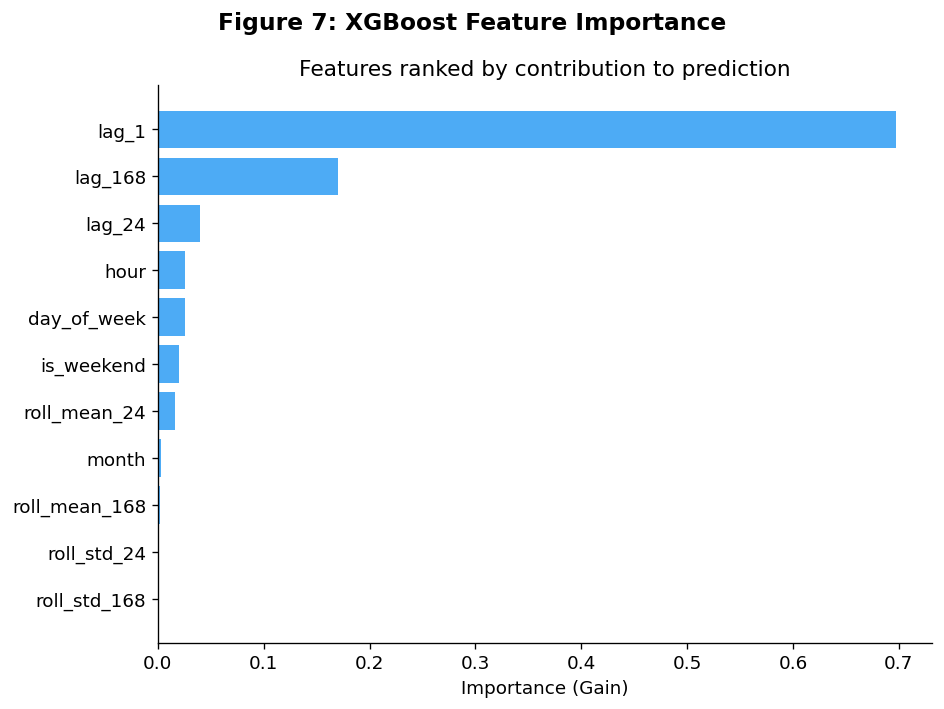

Figure 7 saved.


In [ ]:
# Figure 7: XGBoost Feature Importance
importances = xgb_model.feature_importances_
sorted_idx = np.argsort(importances)

fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Figure 7: XGBoost Feature Importance',
             fontsize=14, fontweight='bold')

ax.barh([feature_cols[i] for i in sorted_idx], importances[sorted_idx],
        color='#2196F3', alpha=0.8)
ax.set_xlabel('Importance (Gain)')
ax.set_title('Features ranked by contribution to prediction')

plt.tight_layout()
plt.savefig('fig7_xgboost_importance.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure 7 saved.")

### 7.2 XGBoost Rolling Evaluation

We evaluate XGBoost using the same rolling non-overlapping windows as the statistical baselines.
At each forecast origin, we build the feature vector for each future hour using an autoregressive
rollout: the predicted value at t+1 becomes the lag_1 feature for t+2, the predicted value at
t+24 updates lag_24, and so on. Calendar and rolling features are computed from known information.

In [ ]:
# Rolling evaluation with autoregressive multi-step prediction
def xgb_forecast(origin_idx, horizon, df_source, model, feat_cols):
    """
    Produce an h-step forecast from origin_idx using autoregressive rollout.
    df_source must contain the 'Total Load' column and all feature columns.
    """
    preds = []
    # We need a mutable copy of recent history for rolling lag updates
    history = df_source['Total Load'].values[:origin_idx].copy()

    for step in range(horizon):
        target_idx = origin_idx + step
        if target_idx >= len(df_source):
            preds.append(np.mean(history[-24:]))
            continue

        # Build feature row from df_source (calendar + rolling features are pre-computed)
        row = df_source.iloc[target_idx][feat_cols].values.copy().astype(np.float64)

        # Override lag features with most recent actuals/predictions
        total_history = np.concatenate([history, preds])
        n = len(total_history)

        # lag_1
        lag1_idx = feat_cols.index('lag_1')
        row[lag1_idx] = total_history[-1] if n >= 1 else row[lag1_idx]

        # lag_24
        lag24_idx = feat_cols.index('lag_24')
        if n >= 24:
            row[lag24_idx] = total_history[-24]

        # lag_168
        lag168_idx = feat_cols.index('lag_168')
        if n >= 168:
            row[lag168_idx] = total_history[-168]

        # rolling mean/std 24h
        rm24_idx = feat_cols.index('roll_mean_24')
        rs24_idx = feat_cols.index('roll_std_24')
        if n >= 24:
            recent_24 = total_history[-24:]
            row[rm24_idx] = np.mean(recent_24)
            row[rs24_idx] = np.std(recent_24)

        # rolling mean/std 168h
        rm168_idx = feat_cols.index('roll_mean_168')
        rs168_idx = feat_cols.index('roll_std_168')
        if n >= 168:
            recent_168 = total_history[-168:]
            row[rm168_idx] = np.mean(recent_168)
            row[rs168_idx] = np.std(recent_168)

        pred_val = model.predict(row.reshape(1, -1))[0]
        preds.append(pred_val)

    return np.array(preds)

# Align test evaluation on df_feat (which has the engineered features)
test_feat_start = len(train_feat) + len(val_feat)

print(f'XGBoost rolling evaluation on test set ...')
print(f'Test starts at index {test_feat_start} in df_feat ({len(test_feat):,} rows)\n')

for horizon in HORIZONS:
    actuals, preds = [], []
    t0 = time.time()
    n_total = (len(df_feat) - test_feat_start - horizon) // horizon + 1

    for idx, i in enumerate(range(test_feat_start, len(df_feat) - horizon + 1, horizon)):
        actual = df_feat['Total Load'].values[i:i + horizon]
        pred   = xgb_forecast(i, horizon, df_feat, xgb_model, feature_cols)
        actuals.append(actual)
        preds.append(pred)

        if (idx + 1) % 100 == 0:
            print(f'  [{idx+1}/{n_total}] windows done ({time.time()-t0:.0f}s)')

    elapsed = time.time() - t0
    print(f'  XGBoost {horizon}h complete: {len(actuals)} windows in {elapsed:.1f}s')
    evaluate_model('XGBoost', horizon, actuals, preds)

print(f'\nResults recorded: {len(results)}')

XGBoost rolling evaluation on test set ...
Test starts at index 83587 in df_feat (14,781 rows)

  [100/615] windows done (3s)
  [200/615] windows done (6s)
  [300/615] windows done (10s)
  [400/615] windows done (13s)
  [500/615] windows done (16s)
  [600/615] windows done (19s)
  XGBoost 24h complete: 615 windows in 19.9s

  XGBoost — 24h Horizon (Fixed)
  ──────────────────────────────────────────
  MAE:       277.41 MW
  RMSE:      396.97 MW
  sMAPE:       2.95 %
  MASE:      0.5149
  Windows evaluated: 615
  [100/307] windows done (6s)
  [200/307] windows done (13s)
  [300/307] windows done (19s)
  XGBoost 48h complete: 307 windows in 19.6s

  XGBoost — 48h Horizon (Fixed)
  ──────────────────────────────────────────
  MAE:        315.4 MW
  RMSE:      449.69 MW
  sMAPE:       3.35 %
  MASE:      0.5854
  Windows evaluated: 307

Results recorded: 10


### 7.3 Updated Results Table

Results now include all statistical baselines and XGBoost. This lets us compare how much
the engineered features and gradient boosting improve over the time-series-specific approaches.

In [ ]:
# Updated results table (including XGBoost)
results_df = pd.DataFrame(results)

print('=' * 70)
print('RESULTS — Statistical Baselines + XGBoost')
print('=' * 70)
print(results_df.to_string(index=False))

for h in ['24h', '48h']:
    subset = results_df[results_df['Horizon'] == h]
    best = subset.loc[subset['MAE (MW)'].idxmin()]
    print(f'\nBest {h} (by MAE): {best["Model"]} — {best["MAE (MW)"]} MW')

RESULTS — Statistical Baselines + XGBoost
             Model Config Horizon  MAE (MW)  RMSE (MW)  sMAPE (%)   MASE  Windows
 Naive Persistence  Fixed     24h    504.69     730.05       5.42 0.9367      615
 Naive Persistence  Fixed     48h    631.69     871.46       6.78 1.1724      307
ETS (Holt-Winters)  Fixed     24h    520.74     765.09       5.59 0.9665      615
ETS (Holt-Winters)  Fixed     48h    724.75    1266.37       7.55 1.3451      307
             ARIMA  Fixed     24h   1047.57    1254.23      11.23 1.9443      615
             ARIMA  Fixed     48h   1042.49    1243.49      11.20 1.9349      307
           Prophet  Fixed     24h    418.26     542.20       4.55 0.7763      615
           Prophet  Fixed     48h    462.96     601.95       5.04 0.8593      307
           XGBoost  Fixed     24h    277.41     396.97       2.95 0.5149      615
           XGBoost  Fixed     48h    315.40     449.69       3.35 0.5854      307

Best 24h (by MAE): XGBoost — 277.41 MW

Best 48h (by MA

## 8. Deep Learning Model — LSTM

Long Short-Term Memory (LSTM) networks (Hochreiter & Schmidhuber, 1997) are recurrent neural
networks specifically designed to learn long-range dependencies in sequential data. Unlike
XGBoost, which requires hand-crafted features, LSTM operates directly on the raw scaled time
series and learns temporal patterns from the sequence itself.

Our LSTM architecture:
- **Input**: 168-hour (1 week) lookback window of scaled load values; chosen based on the
  strong weekly autocorrelation (ACF lag-168 = 0.90) found in Section 3.6
- **Hidden layers**: 2 stacked LSTM layers with 128 units each; sufficient capacity for the
  daily and weekly patterns without overfitting
- **Output**: Dense layer projecting to the forecast horizon (24 or 48 values)
- **Training**: Adam optimiser, MSE loss, early stopping on validation loss (patience 10)
- **Device**: GPU if available (checked in Section 1)

We train one model per forecast horizon, then evaluate using the same rolling windows as all
other models. Predictions are inverse-scaled back to MW before computing metrics.

In [ ]:
# ── 8.  LSTM ───────────────────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

LOOKBACK = 168  # 1 week of hourly data

# ─── Dataset ──────────────────────────────────────────────────────
class TimeSeriesDataset(Dataset):
    def __init__(self, data, lookback, horizon):
        self.X, self.y = [], []
        for i in range(len(data) - lookback - horizon + 1):
            self.X.append(data[i:i + lookback])
            self.y.append(data[i + lookback:i + lookback + horizon])
        self.X = torch.FloatTensor(np.array(self.X))
        self.y = torch.FloatTensor(np.array(self.y).squeeze(-1))

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# ─── Model ────────────────────────────────────────────────────────
class LSTMForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=128, num_layers=2,
                 horizon=24, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, horizon)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])  # last time step → horizon outputs

# ─── Training Function ────────────────────────────────────────────
def train_lstm(horizon, train_data, val_data, epochs=100, batch_size=64,
               lr=1e-3, patience=10):
    train_ds = TimeSeriesDataset(train_data, LOOKBACK, horizon)
    val_ds   = TimeSeriesDataset(val_data, LOOKBACK, horizon)

    # Use full train+val scaled data for validation dataset context
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    model = LSTMForecaster(horizon=horizon).to(device)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimiser, patience=5, factor=0.5
    )

    best_val_loss = np.inf
    best_state = None
    wait = 0

    for epoch in range(epochs):
        # Train
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimiser.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimiser.step()
            train_loss += loss.item() * len(X_batch)
        train_loss /= len(train_ds)

        # Validate
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                pred = model(X_batch)
                val_loss += criterion(pred, y_batch).item() * len(X_batch)
        val_loss /= len(val_ds)

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if (epoch + 1) % 10 == 0 or wait == 0:
            print(f'  Epoch {epoch+1:3d}  train_loss={train_loss:.6f}  '
                  f'val_loss={val_loss:.6f}  best={best_val_loss:.6f}  '
                  f'patience={wait}/{patience}')

        if wait >= patience:
            print(f'  Early stopping at epoch {epoch+1}')
            break

    model.load_state_dict(best_state)
    model.to(device)
    model.eval()
    return model

print('=' * 55)
print('MODEL 6: LSTM')
print('=' * 55)
print(f'Lookback:    {LOOKBACK} hours (1 week)')
print(f'Architecture: 2×LSTM(128) → Dense(horizon)')
print(f'Optimiser:   Adam (lr=1e-3, ReduceLROnPlateau)')
print(f'Training:    early stopping (patience=10)\n')

Device: cuda
MODEL 6: LSTM
Lookback:    168 hours (1 week)
Architecture: 2×LSTM(128) → Dense(horizon)
Optimiser:   Adam (lr=1e-3, ReduceLROnPlateau)
Training:    early stopping (patience=10)



In [ ]:
# Train one LSTM per horizon
lstm_models = {}

for horizon in HORIZONS:
    print(f'\n{"─"*55}')
    print(f'Training LSTM for {horizon}h horizon ...')
    print(f'{"─"*55}')

    model = train_lstm(
        horizon=horizon,
        train_data=train_scaled,
        val_data=val_scaled,
        epochs=100,
        batch_size=64,
        lr=1e-3,
        patience=10
    )
    lstm_models[horizon] = model

    # Count parameters
    n_params = sum(p.numel() for p in model.parameters())
    print(f'  Parameters: {n_params:,}')

print(f'\nLSTM models trained for horizons: {list(lstm_models.keys())}')


───────────────────────────────────────────────────────
Training LSTM for 24h horizon ...
───────────────────────────────────────────────────────
  Epoch   1  train_loss=0.220678  val_loss=0.128513  best=0.128513  patience=0/10
  Epoch   2  train_loss=0.100135  val_loss=0.088909  best=0.088909  patience=0/10
  Epoch   4  train_loss=0.065996  val_loss=0.076999  best=0.076999  patience=0/10
  Epoch   5  train_loss=0.060993  val_loss=0.076656  best=0.076656  patience=0/10
  Epoch   6  train_loss=0.056854  val_loss=0.066923  best=0.066923  patience=0/10
  Epoch  10  train_loss=0.046513  val_loss=0.069266  best=0.066923  patience=4/10
  Epoch  13  train_loss=0.036725  val_loss=0.064959  best=0.064959  patience=0/10
  Epoch  20  train_loss=0.027519  val_loss=0.078075  best=0.064959  patience=7/10
  Early stopping at epoch 23
  Parameters: 202,264

───────────────────────────────────────────────────────
Training LSTM for 48h horizon ...
───────────────────────────────────────────────────────

### 8.1 LSTM Rolling Evaluation

We evaluate the LSTM using the same non-overlapping rolling windows as all other models.
At each forecast origin, we extract the most recent 168 hours of scaled data, pass it through
the trained LSTM, and inverse-transform the output back to MW for metric computation.

In [ ]:
# Rolling evaluation on test set
all_scaled = np.concatenate([train_scaled, val_scaled, test_scaled]).flatten()
test_start_scaled = len(train_scaled) + len(val_scaled)

for horizon in HORIZONS:
    model = lstm_models[horizon]
    actuals, preds = [], []
    t0 = time.time()
    n_total = (len(all_scaled) - test_start_scaled - horizon) // horizon + 1

    for idx, i in enumerate(range(test_start_scaled,
                                   len(all_scaled) - horizon + 1, horizon)):
        if i < LOOKBACK:
            continue

        # Input: last LOOKBACK hours (scaled)
        x = all_scaled[i - LOOKBACK:i].reshape(1, LOOKBACK, 1)
        x_tensor = torch.FloatTensor(x).to(device)

        with torch.no_grad():
            pred_scaled = model(x_tensor).cpu().numpy().flatten()

        # Inverse scale predictions and actuals
        pred_mw = scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
        actual_scaled = all_scaled[i:i + horizon]
        actual_mw = scaler.inverse_transform(actual_scaled.reshape(-1, 1)).flatten()

        actuals.append(actual_mw)
        preds.append(pred_mw)

        if (idx + 1) % 100 == 0:
            print(f'  [{idx+1}/{n_total}] windows done ({time.time()-t0:.0f}s)')

    elapsed = time.time() - t0
    print(f'  LSTM {horizon}h complete: {len(actuals)} windows in {elapsed:.1f}s')
    evaluate_model('LSTM', horizon, actuals, preds)

print(f'\nResults recorded: {len(results)}')

  [100/615] windows done (0s)
  [200/615] windows done (0s)
  [300/615] windows done (0s)
  [400/615] windows done (1s)
  [500/615] windows done (1s)
  [600/615] windows done (1s)
  LSTM 24h complete: 615 windows in 0.9s

  LSTM — 24h Horizon (Fixed)
  ──────────────────────────────────────────
  MAE:       302.48 MW
  RMSE:      426.62 MW
  sMAPE:       3.23 %
  MASE:      0.5614
  Windows evaluated: 615
  [100/307] windows done (0s)
  [200/307] windows done (0s)
  [300/307] windows done (0s)
  LSTM 48h complete: 307 windows in 0.4s

  LSTM — 48h Horizon (Fixed)
  ──────────────────────────────────────────
  MAE:        328.5 MW
  RMSE:      454.85 MW
  sMAPE:       3.51 %
  MASE:      0.6097
  Windows evaluated: 307

Results recorded: 12


### 8.2 Updated Results Table

Results now include all baselines, XGBoost, and LSTM. This comparison shows how the deep
learning sequence model performs against both classical methods and feature-engineered
gradient boosting.

In [ ]:
# Updated results table (including LSTM)
results_df = pd.DataFrame(results)

print('=' * 70)
print('RESULTS — All Baselines + XGBoost + LSTM')
print('=' * 70)
print(results_df.to_string(index=False))

for h in ['24h', '48h']:
    subset = results_df[results_df['Horizon'] == h]
    best = subset.loc[subset['MAE (MW)'].idxmin()]
    print(f'\nBest {h} (by MAE): {best["Model"]} — {best["MAE (MW)"]} MW')

RESULTS — All Baselines + XGBoost + LSTM
             Model Config Horizon  MAE (MW)  RMSE (MW)  sMAPE (%)   MASE  Windows
 Naive Persistence  Fixed     24h    504.69     730.05       5.42 0.9367      615
 Naive Persistence  Fixed     48h    631.69     871.46       6.78 1.1724      307
ETS (Holt-Winters)  Fixed     24h    520.74     765.09       5.59 0.9665      615
ETS (Holt-Winters)  Fixed     48h    724.75    1266.37       7.55 1.3451      307
             ARIMA  Fixed     24h   1047.57    1254.23      11.23 1.9443      615
             ARIMA  Fixed     48h   1042.49    1243.49      11.20 1.9349      307
           Prophet  Fixed     24h    418.26     542.20       4.55 0.7763      615
           Prophet  Fixed     48h    462.96     601.95       5.04 0.8593      307
           XGBoost  Fixed     24h    277.41     396.97       2.95 0.5149      615
           XGBoost  Fixed     48h    315.40     449.69       3.35 0.5854      307
              LSTM  Fixed     24h    302.48     426.62   

## 9. LLM-Based Model — Time-LLM

Time-LLM (Jin et al., 2024, ICLR) is a framework that repurposes a frozen pre-trained language
model for time-series forecasting. The key insight is that large language models already encode
rich pattern-recognition capabilities from their text pre-training; Time-LLM adapts these
capabilities to numerical sequences through two learnable components:

1. **Input Reprogramming Layer**: transforms the raw time-series patch embeddings into the
   token embedding space of the language model via a cross-attention mechanism with learnable
   "prompt prototypes"
2. **Output Projection**: maps the language model's hidden states back to forecast values

The frozen backbone (GPT-2, 124M parameters) is never fine-tuned; only the thin reprogramming
and projection layers are trained, making this highly parameter-efficient.

**Architecture details:**
- **Backbone**: GPT-2 (frozen, 124M params); pre-trained on WebText
- **Patch length**: 24 (one day of hourly data)
- **Stride**: 24 (non-overlapping patches)
- **d_model**: 768 (GPT-2 hidden size)
- **Learnable parameters**: ~2M (reprogramming + projection only)
- **Training**: same train/val split, early stopping on validation loss

In [ ]:
# ── 9.  Time-LLM ──────────────────────────────────────────────────────
from transformers import GPT2Model, GPT2Config
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

print('=' * 55)
print('MODEL 7: Time-LLM (GPT-2 Backbone)')
print('=' * 55)

# ─── Patch Embedding ──────────────────────────────────────────────
class PatchEmbedding(nn.Module):
    """Split time series into non-overlapping patches and project."""
    def __init__(self, patch_len=24, d_model=768):
        super().__init__()
        self.patch_len = patch_len
        self.proj = nn.Linear(patch_len, d_model)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        # x: (B, seq_len, 1)
        B, L, _ = x.shape
        x = x.squeeze(-1)  # (B, L)
        # Pad if needed
        remainder = L % self.patch_len
        if remainder != 0:
            pad_len = self.patch_len - remainder
            x = F.pad(x, (0, pad_len))
        # Reshape into patches
        n_patches = x.shape[1] // self.patch_len
        x = x.reshape(B, n_patches, self.patch_len)  # (B, N, P)
        x = self.norm(self.proj(x))  # (B, N, d_model)
        return x

# ─── Reprogramming Layer ─────────────────────────────────────────
class ReprogrammingLayer(nn.Module):
    """Cross-attention that maps patch embeddings into LLM token space."""
    def __init__(self, d_model=768, n_heads=8, n_prompt_tokens=16):
        super().__init__()
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        # Learnable prompt prototypes
        self.prompt_prototypes = nn.Parameter(
            torch.randn(1, n_prompt_tokens, d_model) * 0.02
        )
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

    def forward(self, x):
        B, N, D = x.shape
        prompts = self.prompt_prototypes.expand(B, -1, -1)

        Q = self.W_q(x).view(B, N, self.n_heads, self.d_k).transpose(1, 2)
        K = self.W_k(prompts).view(B, -1, self.n_heads, self.d_k).transpose(1, 2)
        V = self.W_v(prompts).view(B, -1, self.n_heads, self.d_k).transpose(1, 2)

        attn = (Q @ K.transpose(-2, -1)) / (self.d_k ** 0.5)
        attn = F.softmax(attn, dim=-1)
        out = (attn @ V).transpose(1, 2).contiguous().view(B, N, D)
        return self.out_proj(out)

# ─── Time-LLM Model ──────────────────────────────────────────────
class TimeLLM(nn.Module):
    def __init__(self, seq_len=168, horizon=24, patch_len=24,
                 d_model=768, n_prompt_tokens=16):
        super().__init__()
        self.patch_embed = PatchEmbedding(patch_len, d_model)
        self.reprogrammer = ReprogrammingLayer(d_model, n_heads=8,
                                                n_prompt_tokens=n_prompt_tokens)

        # Frozen GPT-2 backbone
        config = GPT2Config.from_pretrained('gpt2')
        self.llm = GPT2Model.from_pretrained('gpt2', config=config)
        for param in self.llm.parameters():
            param.requires_grad = False

        # Output projection
        n_patches = (seq_len + patch_len - 1) // patch_len  # ceil division
        self.output_proj = nn.Linear(d_model * n_patches, horizon)
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        # x: (B, seq_len, 1)
        patches = self.patch_embed(x)          # (B, N, d_model)
        reprog = self.reprogrammer(patches)     # (B, N, d_model)

        # Pass through frozen GPT-2
        llm_out = self.llm(inputs_embeds=reprog).last_hidden_state  # (B, N, d_model)

        # Flatten and project to forecast horizon
        B = llm_out.shape[0]
        flat = self.dropout(llm_out.reshape(B, -1))
        return self.output_proj(flat)          # (B, horizon)

# Count parameters
def count_params(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    return trainable, frozen

print('Loading GPT-2 backbone (124M frozen parameters) ...')
test_model = TimeLLM(seq_len=LOOKBACK, horizon=24).to(device)
trainable, frozen = count_params(test_model)
print(f'  Trainable parameters: {trainable:,}')
print(f'  Frozen parameters:    {frozen:,}')
print(f'  Total:                {trainable + frozen:,}')
del test_model
torch.cuda.empty_cache() if torch.cuda.is_available() else None
print('GPT-2 loaded successfully.')

MODEL 7: Time-LLM (GPT-2 Backbone)
Loading GPT-2 backbone (124M frozen parameters) ...


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Trainable parameters: 2,524,440
  Frozen parameters:    124,439,808
  Total:                126,964,248
GPT-2 loaded successfully.


In [ ]:
# ─── Training Function for Time-LLM ──────────────────────────────
def train_timellm(horizon, train_data, val_data, epochs=50, batch_size=32,
                  lr=5e-4, patience=10):
    train_ds = TimeSeriesDataset(train_data, LOOKBACK, horizon)
    val_ds   = TimeSeriesDataset(val_data, LOOKBACK, horizon)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    model = TimeLLM(seq_len=LOOKBACK, horizon=horizon).to(device)
    # Only optimise trainable params (reprogrammer + projection)
    optimiser = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr, weight_decay=1e-4
    )
    criterion = nn.MSELoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimiser, patience=5, factor=0.5
    )

    best_val_loss = np.inf
    best_state = None
    wait = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimiser.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad], 1.0
            )
            optimiser.step()
            train_loss += loss.item() * len(X_batch)
        train_loss /= len(train_ds)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                pred = model(X_batch)
                val_loss += criterion(pred, y_batch).item() * len(X_batch)
        val_loss /= len(val_ds)

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if (epoch + 1) % 5 == 0 or wait == 0:
            print(f'  Epoch {epoch+1:3d}  train={train_loss:.6f}  '
                  f'val={val_loss:.6f}  best={best_val_loss:.6f}  '
                  f'wait={wait}/{patience}')

        if wait >= patience:
            print(f'  Early stopping at epoch {epoch+1}')
            break

    model.load_state_dict(best_state)
    model.to(device)
    model.eval()
    return model

# Train Time-LLM for each horizon
timellm_models = {}

for horizon in HORIZONS:
    print(f'\n{"─"*55}')
    print(f'Training Time-LLM for {horizon}h horizon ...')
    print(f'{"─"*55}')

    model = train_timellm(
        horizon=horizon,
        train_data=train_scaled,
        val_data=val_scaled,
        epochs=150,
        batch_size=32,
        lr=5e-4,
        patience=10
    )
    timellm_models[horizon] = model
    trainable, frozen = count_params(model)
    print(f'  Trainable params: {trainable:,}')

print(f'\nTime-LLM models trained for horizons: {list(timellm_models.keys())}')


───────────────────────────────────────────────────────
Training Time-LLM for 24h horizon ...
───────────────────────────────────────────────────────


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch   1  train=0.252828  val=0.139491  best=0.139491  wait=0/10
  Epoch   2  train=0.129127  val=0.132141  best=0.132141  wait=0/10
  Epoch   3  train=0.117651  val=0.111248  best=0.111248  wait=0/10
  Epoch   4  train=0.110768  val=0.102231  best=0.102231  wait=0/10
  Epoch   5  train=0.105830  val=0.093609  best=0.093609  wait=0/10
  Epoch   6  train=0.101871  val=0.087812  best=0.087812  wait=0/10
  Epoch   7  train=0.100484  val=0.082055  best=0.082055  wait=0/10
  Epoch  10  train=0.092557  val=0.113806  best=0.082055  wait=3/10
  Epoch  13  train=0.087118  val=0.077882  best=0.077882  wait=0/10
  Epoch  15  train=0.085110  val=0.083408  best=0.077882  wait=2/10
  Epoch  20  train=0.070598  val=0.069757  best=0.069757  wait=0/10
  Epoch  23  train=0.067716  val=0.069005  best=0.069005  wait=0/10
  Epoch  25  train=0.067356  val=0.068616  best=0.068616  wait=0/10
  Epoch  29  train=0.066480  val=0.066827  best=0.066827  wait=0/10
  Epoch  30  train=0.065920  val=0.067774  best=

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch   1  train=0.244432  val=0.139052  best=0.139052  wait=0/10
  Epoch   2  train=0.152953  val=0.121477  best=0.121477  wait=0/10
  Epoch   5  train=0.124375  val=0.121042  best=0.121042  wait=0/10
  Epoch   7  train=0.120415  val=0.110857  best=0.110857  wait=0/10
  Epoch  10  train=0.115051  val=0.102990  best=0.102990  wait=0/10
  Epoch  15  train=0.108688  val=0.108177  best=0.102990  wait=5/10
  Epoch  17  train=0.093801  val=0.092675  best=0.092675  wait=0/10
  Epoch  20  train=0.088898  val=0.096381  best=0.092675  wait=3/10
  Epoch  22  train=0.088121  val=0.091608  best=0.091608  wait=0/10
  Epoch  25  train=0.087208  val=0.104665  best=0.091608  wait=3/10
  Epoch  28  train=0.085938  val=0.090673  best=0.090673  wait=0/10
  Epoch  30  train=0.085545  val=0.109686  best=0.090673  wait=2/10
  Epoch  35  train=0.077769  val=0.089614  best=0.089614  wait=0/10
  Epoch  36  train=0.076353  val=0.088338  best=0.088338  wait=0/10
  Epoch  40  train=0.075153  val=0.088605  best=

### 9.1 Time-LLM Rolling Evaluation

We evaluate Time-LLM with the same rolling non-overlapping windows used for all other models.
The 168-hour lookback is passed through the reprogramming layer and frozen GPT-2 backbone,
then the output projection produces the forecast. Predictions are inverse-scaled to MW.

In [ ]:
# Rolling evaluation on test set
for horizon in HORIZONS:
    model = timellm_models[horizon]
    actuals, preds = [], []
    t0 = time.time()
    n_total = (len(all_scaled) - test_start_scaled - horizon) // horizon + 1

    for idx, i in enumerate(range(test_start_scaled,
                                   len(all_scaled) - horizon + 1, horizon)):
        if i < LOOKBACK:
            continue

        x = all_scaled[i - LOOKBACK:i].reshape(1, LOOKBACK, 1)
        x_tensor = torch.FloatTensor(x).to(device)

        with torch.no_grad():
            pred_scaled = model(x_tensor).cpu().numpy().flatten()

        pred_mw = scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
        actual_scaled = all_scaled[i:i + horizon]
        actual_mw = scaler.inverse_transform(actual_scaled.reshape(-1, 1)).flatten()

        actuals.append(actual_mw)
        preds.append(pred_mw)

        if (idx + 1) % 100 == 0:
            print(f'  [{idx+1}/{n_total}] windows done ({time.time()-t0:.0f}s)')

    elapsed = time.time() - t0
    print(f'  Time-LLM {horizon}h complete: {len(actuals)} windows in {elapsed:.1f}s')
    evaluate_model('Time-LLM (GPT-2)', horizon, actuals, preds)

print(f'\nResults recorded: {len(results)}')

  [100/615] windows done (1s)
  [200/615] windows done (2s)
  [300/615] windows done (3s)
  [400/615] windows done (4s)
  [500/615] windows done (5s)
  [600/615] windows done (6s)
  Time-LLM 24h complete: 615 windows in 6.6s

  Time-LLM (GPT-2) — 24h Horizon (Fixed)
  ──────────────────────────────────────────
  MAE:       270.98 MW
  RMSE:      382.99 MW
  sMAPE:       2.91 %
  MASE:      0.5029
  Windows evaluated: 615
  [100/307] windows done (1s)
  [200/307] windows done (2s)
  [300/307] windows done (3s)
  Time-LLM 48h complete: 307 windows in 3.2s

  Time-LLM (GPT-2) — 48h Horizon (Fixed)
  ──────────────────────────────────────────
  MAE:       316.63 MW
  RMSE:      439.63 MW
  sMAPE:       3.39 %
  MASE:      0.5877
  Windows evaluated: 307

Results recorded: 14


### 9.2 Updated Results Table

With Time-LLM added, we can now compare the frozen-LLM approach against both traditional
baselines and supervised deep learning. This is the first model in our comparison that
leverages pre-trained language model knowledge for time-series forecasting.

In [ ]:
# Updated results table (including Time-LLM)
results_df = pd.DataFrame(results)

print('=' * 70)
print('RESULTS — All Models including Time-LLM')
print('=' * 70)
print(results_df.to_string(index=False))

for h in ['24h', '48h']:
    subset = results_df[results_df['Horizon'] == h]
    best = subset.loc[subset['MAE (MW)'].idxmin()]
    print(f'\nBest {h} (by MAE): {best["Model"]} — {best["MAE (MW)"]} MW')

RESULTS — All Models including Time-LLM
             Model Config Horizon  MAE (MW)  RMSE (MW)  sMAPE (%)   MASE  Windows
 Naive Persistence  Fixed     24h    504.69     730.05       5.42 0.9367      615
 Naive Persistence  Fixed     48h    631.69     871.46       6.78 1.1724      307
ETS (Holt-Winters)  Fixed     24h    520.74     765.09       5.59 0.9665      615
ETS (Holt-Winters)  Fixed     48h    724.75    1266.37       7.55 1.3451      307
             ARIMA  Fixed     24h   1047.57    1254.23      11.23 1.9443      615
             ARIMA  Fixed     48h   1042.49    1243.49      11.20 1.9349      307
           Prophet  Fixed     24h    418.26     542.20       4.55 0.7763      615
           Prophet  Fixed     48h    462.96     601.95       5.04 0.8593      307
           XGBoost  Fixed     24h    277.41     396.97       2.95 0.5149      615
           XGBoost  Fixed     48h    315.40     449.69       3.35 0.5854      307
              LSTM  Fixed     24h    302.48     426.62    

## 10. LLM-Based Model — GPT-4o (Azure OpenAI)

Our final model tests whether a state-of-the-art commercial large language model can forecast
energy load directly from textual prompts; no fine-tuning, no numerical training, just natural
language instructions and raw numbers.

GPT-4o (OpenAI, 2024) is a multimodal transformer with strong reasoning capabilities. We access
it via the Azure OpenAI Service using the credentials stored in Colab Secrets. Two prompting
strategies are evaluated:

1. **Zero-Shot (ZS)**: The model receives only the task description and the context window of
   historical load values. It must forecast purely from its pre-trained knowledge of time series,
   energy systems, and numerical patterns.

2. **Few-Shot (FS)**: The model additionally receives 3 example input→output pairs drawn from
   the validation set. These examples demonstrate the expected format and give the model concrete
   evidence of the data's daily/weekly patterns.

**Important considerations:**
- GPT-4o processes numbers as text tokens; it has no native numerical computation capability
- Temperature is set to 0 for deterministic, reproducible outputs

In [ ]:
# ── 10.  GPT-4o (Azure OpenAI) ────────────────────────────────────────
from openai import AzureOpenAI
from google.colab import userdata
import json, re

print('=' * 55)
print('MODEL 8: GPT-4o (Azure OpenAI)')
print('=' * 55)

# Load API credentials from Colab Secrets
client = AzureOpenAI(
    api_key=userdata.get('AZURE_OPENAI_KEY'),
    azure_endpoint=userdata.get('AZURE_ENDPOINT'),
    api_version='2025-01-01-preview'
)
DEPLOYMENT = userdata.get('AZURE_DEPLOYMENT')

# Test connection
test_resp = client.chat.completions.create(
    model=DEPLOYMENT,
    messages=[{"role": "user", "content": "Reply with OK"}],
    max_tokens=5,
    temperature=0
)
print(f'API connection: {test_resp.choices[0].message.content.strip()}')
print(f'Deployment:     {DEPLOYMENT}')

# ─── Window Origins (full test set) ───────────────────────────────
gpt4o_origins = {}
for horizon in HORIZONS:
    gpt4o_origins[horizon] = list(range(test_start_pos,
                                         len(full_vals) - horizon + 1, horizon))
    print(f'{horizon}h: {len(gpt4o_origins[horizon])} windows (full test set)')

print(f'\nGPT-4o setup complete.')

MODEL 8: GPT-4o (Azure OpenAI)
API connection: OK
Deployment:     gpt-4o
24h: 615 windows (full test set)
48h: 307 windows (full test set)

GPT-4o setup complete.


### 10.1 Prompt Design

The prompt provides GPT-4o with the context window as a comma-separated list of hourly MW values,
states the forecast horizon, and requests output as a JSON array of numbers. We explicitly instruct
the model about the domain (Belgian electricity grid) and expected patterns (daily cycles, weekend
effects) to activate relevant pre-trained knowledge.

For few-shot prompting, we prepend 3 example windows from the validation set with their
corresponding actual future values, giving the model concrete demonstrations of the data's
temporal structure.

In [ ]:
# ─── Prompt Templates ─────────────────────────────────────────────
SYSTEM_PROMPT = (
    "You are an expert energy analyst. You forecast hourly electricity load (MW) "
    "on the Belgian grid. The data has strong daily cycles (peak ~11000 MW daytime, "
    "trough ~7000 MW night) and weekly patterns (lower on weekends). "
    "Respond ONLY with a JSON array of numbers — no text, no explanation."
)

def format_context(values, last_n=168):
    """Format the most recent values as a compact comma-separated string."""
    recent = values[-last_n:]
    return ', '.join(f'{v:.0f}' for v in recent)

def build_zero_shot_prompt(context_values, horizon):
    return (
        f"Here are the most recent {len(context_values)} hourly electricity load "
        f"readings (MW) on the Belgian grid, from oldest to newest:\n\n"
        f"[{format_context(context_values)}]\n\n"
        f"Forecast the next {horizon} hourly load values. "
        f"Return ONLY a JSON array of {horizon} numbers."
    )

# ─── Few-Shot Examples (from validation set) ──────────────────────
def build_few_shot_examples(horizon, n_examples=3):
    """Extract example windows from the validation set."""
    val_start = len(train_series)
    examples = []
    # Space examples evenly across validation set
    val_origins = list(range(val_start + LOOKBACK,
                              val_start + len(val_series) - horizon,
                              len(val_series) // (n_examples + 1)))[:n_examples]

    for origin in val_origins:
        ctx = full_vals[origin - LOOKBACK:origin]
        actual = full_vals[origin:origin + horizon]
        examples.append({
            'context': format_context(ctx),
            'output': json.dumps([round(float(v), 0) for v in actual])
        })
    return examples

def build_few_shot_prompt(context_values, horizon, examples):
    parts = [
        f"Here are examples of Belgian grid load forecasting. "
        f"Given 168 hourly readings, predict the next {horizon} hours.\n"
    ]
    for i, ex in enumerate(examples, 1):
        parts.append(f"Example {i}:\nInput: [{ex['context']}]\nOutput: {ex['output']}\n")

    parts.append(
        f"Now forecast:\nInput: [{format_context(context_values)}]\n"
        f"Return ONLY a JSON array of {horizon} numbers."
    )
    return '\n'.join(parts)

# Cache few-shot examples (built once)
fs_examples = {h: build_few_shot_examples(h) for h in HORIZONS}
print(f'Few-shot examples prepared: {len(fs_examples[24])} per horizon')
print(f'Example output length check: {len(json.loads(fs_examples[24][0]["output"]))} values')

Few-shot examples prepared: 3 per horizon
Example output length check: 24 values


In [ ]:
# ─── API Call with Parsing ────────────────────────────────────────
def gpt4o_forecast(context_values, horizon, mode='zero-shot'):
    """Call GPT-4o and parse the response into a numpy array."""
    if mode == 'zero-shot':
        user_msg = build_zero_shot_prompt(context_values, horizon)
    else:
        user_msg = build_few_shot_prompt(context_values, horizon,
                                          fs_examples[horizon])

    try:
        response = client.chat.completions.create(
            model=DEPLOYMENT,
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": user_msg}
            ],
            max_tokens=horizon * 8,  # ~6 chars per number + commas
            temperature=0
        )
        text = response.choices[0].message.content.strip()

        # Parse JSON array from response
        # Handle cases where model wraps in markdown code blocks
        text = re.sub(r'^```json\s*', '', text)
        text = re.sub(r'\s*```$', '', text)

        values = json.loads(text)
        if isinstance(values, list) and len(values) >= horizon:
            return np.array(values[:horizon], dtype=np.float64)
        elif isinstance(values, list):
            # Pad with last value if model returned fewer
            arr = np.array(values, dtype=np.float64)
            return np.pad(arr, (0, horizon - len(arr)), mode='edge')

    except Exception as e:
        print(f'    API error: {e}')

    # Fallback: repeat last 24h of context
    return np.tile(context_values[-24:], int(np.ceil(horizon / 24)))[:horizon]

# Quick test
test_ctx = full_vals[test_start_pos - LOOKBACK:test_start_pos]
test_pred = gpt4o_forecast(test_ctx, 24, mode='zero-shot')
print(f'Test forecast (first 5): {test_pred[:5]}')
print(f'Test forecast length: {len(test_pred)}')
print(f'Values look reasonable: {5000 < np.mean(test_pred) < 15000}')

Test forecast (first 5): [7900. 7700. 7500. 7400. 7200.]
Test forecast length: 24
Values look reasonable: True


### 10.2 GPT-4o Zero-Shot Evaluation

In zero-shot mode, GPT-4o must forecast purely from its pre-trained knowledge and the
numerical context provided in the prompt. This tests whether the model's understanding of
temporal patterns, learned from internet-scale text data, transfers to structured numerical
forecasting without any domain-specific examples.

In [ ]:
# ─── Zero-Shot Evaluation ─────────────────────────────────────────
print('GPT-4o Zero-Shot Evaluation')
print('=' * 55)

for horizon in HORIZONS:
    actuals, preds = [], []
    t0 = time.time()
    origins = gpt4o_origins[horizon]

    for idx, i in enumerate(origins):
        context = full_vals[max(0, i - LOOKBACK):i]
        actual = full_vals[i:i + horizon]
        pred = gpt4o_forecast(context, horizon, mode='zero-shot')

        actuals.append(actual)
        preds.append(pred)

        if (idx + 1) % 10 == 0:
            elapsed = time.time() - t0
            print(f'  [{idx+1}/{len(origins)}] done ({elapsed:.0f}s)')

    elapsed = time.time() - t0
    print(f'  ZS {horizon}h complete: {len(actuals)} windows in {elapsed:.1f}s')
    evaluate_model('GPT-4o (Zero-Shot)', horizon, actuals, preds)

print(f'\nResults recorded: {len(results)}')

GPT-4o Zero-Shot Evaluation
  [10/615] done (36s)
  [20/615] done (69s)
  [30/615] done (99s)
  [40/615] done (131s)
  [50/615] done (162s)
  [60/615] done (193s)
  [70/615] done (228s)
  [80/615] done (262s)
  [90/615] done (291s)
  [100/615] done (321s)
  [110/615] done (350s)
  [120/615] done (376s)
  [130/615] done (408s)
  [140/615] done (440s)
  [150/615] done (475s)
  [160/615] done (504s)
  [170/615] done (541s)
  [180/615] done (581s)
  [190/615] done (610s)
  [200/615] done (643s)
  [210/615] done (682s)
  [220/615] done (723s)
  [230/615] done (753s)
  [240/615] done (791s)
  [250/615] done (818s)
  [260/615] done (846s)
  [270/615] done (877s)
  [280/615] done (903s)
  [290/615] done (930s)
  [300/615] done (957s)
  [310/615] done (985s)
  [320/615] done (1018s)
  [330/615] done (1047s)
  [340/615] done (1076s)
  [350/615] done (1117s)
  [360/615] done (1149s)
  [370/615] done (1183s)
  [380/615] done (1213s)
  [390/615] done (1243s)
  [400/615] done (1268s)
  [410/615] don

### 10.3 GPT-4o Few-Shot Evaluation

In few-shot mode, we prepend 3 example input→output pairs from the validation set to the
prompt. These examples serve two purposes:
1. They demonstrate the expected output format (JSON array of MW values)
2. They provide concrete evidence of the data's daily and weekly patterns

This tests whether in-context learning, a core LLM capability; can improve numerical
forecasting performance compared to zero-shot prompting.

In [ ]:
# ─── Few-Shot Evaluation ──────────────────────────────────────────
print('GPT-4o Few-Shot Evaluation')
print('=' * 55)

for horizon in HORIZONS:
    actuals, preds = [], []
    t0 = time.time()
    origins = gpt4o_origins[horizon]

    for idx, i in enumerate(origins):
        context = full_vals[max(0, i - LOOKBACK):i]
        actual = full_vals[i:i + horizon]
        pred = gpt4o_forecast(context, horizon, mode='few-shot')

        actuals.append(actual)
        preds.append(pred)

        if (idx + 1) % 10 == 0:
            elapsed = time.time() - t0
            print(f'  [{idx+1}/{len(origins)}] done ({elapsed:.0f}s)')

    elapsed = time.time() - t0
    print(f'  FS {horizon}h complete: {len(actuals)} windows in {elapsed:.1f}s')
    evaluate_model('GPT-4o (Few-Shot)', horizon, actuals, preds)

print(f'\nResults recorded: {len(results)}')

GPT-4o Few-Shot Evaluation
  [10/615] done (45s)
  [20/615] done (82s)
  [30/615] done (127s)
  [40/615] done (166s)
  [50/615] done (203s)
  [60/615] done (254s)
  [70/615] done (291s)
  [80/615] done (331s)
  [90/615] done (370s)
  [100/615] done (411s)
  [110/615] done (457s)
  [120/615] done (495s)
  [130/615] done (540s)
  [140/615] done (581s)
  [150/615] done (620s)
  [160/615] done (662s)
  [170/615] done (700s)
  [180/615] done (744s)
  [190/615] done (783s)
  [200/615] done (818s)
  [210/615] done (860s)
  [220/615] done (904s)
  [230/615] done (954s)
  [240/615] done (1000s)
  [250/615] done (1040s)
  [260/615] done (1080s)
  [270/615] done (1123s)
  [280/615] done (1164s)
  [290/615] done (1219s)
  [300/615] done (1259s)
  [310/615] done (1298s)
  [320/615] done (1341s)
  [330/615] done (1380s)
  [340/615] done (1419s)
  [350/615] done (1473s)
  [360/615] done (1525s)
  [370/615] done (1577s)
  [380/615] done (1615s)
  [390/615] done (1654s)
  [400/615] done (1707s)
  [410/

### 10.4 Final Results Table

This is the definitive results table consolidating all 8 models × 2 horizons. GPT-4o
results (zero-shot and few-shot) are evaluated on the full test set using the same rolling
non-overlapping protocol as every other model (615 windows for 24 h, 307 windows for 48 h).

In [ ]:
# ── Final Results Table ───────────────────────────────────────────────
results_df = pd.DataFrame(results)

# Define display order
model_order = [
    'Naive Persistence', 'ETS (Holt-Winters)', 'ARIMA', 'Prophet',
    'XGBoost', 'LSTM', 'Time-LLM (GPT-2)',
    'GPT-4o (Zero-Shot)', 'GPT-4o (Few-Shot)'
]
results_df['Model'] = pd.Categorical(results_df['Model'],
                                      categories=model_order, ordered=True)
results_df = results_df.sort_values(['Horizon', 'Model']).reset_index(drop=True)

print('=' * 80)
print('FINAL RESULTS — All Models (8 models × 2 horizons)')
print('=' * 80)
print(results_df.to_string(index=False))

for h in ['24h', '48h']:
    subset = results_df[results_df['Horizon'] == h]
    best = subset.loc[subset['MAE (MW)'].idxmin()]
    print(f'\nBest {h} (by MAE): {best["Model"]} — {best["MAE (MW)"]} MW')

# Save final results
results_df.to_csv('final_results.csv', index=False)
print('\nFinal results saved to final_results.csv')

FINAL RESULTS — All Models (8 models × 2 horizons)
             Model Config Horizon  MAE (MW)  RMSE (MW)  sMAPE (%)   MASE  Windows
 Naive Persistence  Fixed     24h    504.69     730.05       5.42 0.9367      615
ETS (Holt-Winters)  Fixed     24h    520.74     765.09       5.59 0.9665      615
             ARIMA  Fixed     24h   1047.57    1254.23      11.23 1.9443      615
           Prophet  Fixed     24h    418.26     542.20       4.55 0.7763      615
           XGBoost  Fixed     24h    277.41     396.97       2.95 0.5149      615
              LSTM  Fixed     24h    302.48     426.62       3.23 0.5614      615
  Time-LLM (GPT-2)  Fixed     24h    270.98     382.99       2.91 0.5029      615
GPT-4o (Zero-Shot)  Fixed     24h    480.88     689.65       5.08 0.8925      615
 GPT-4o (Few-Shot)  Fixed     24h    775.38    1060.09       8.45 1.4391      615
 Naive Persistence  Fixed     48h    631.69     871.46       6.78 1.1724      307
ETS (Holt-Winters)  Fixed     48h    724.75    

## 11. Results Visualisation

This section provides graphical analysis of all model results. The visualisations are designed
to highlight three key comparisons:
1. **Overall ranking** — which model family performs best at each horizon?
2. **Horizon degradation** — how much does each model's accuracy drop from 24h to 48h?
3. **Forecast quality** — how do the predicted curves compare to ground truth for a sample window?

### 11.1 MAE Comparison — Grouped Bar Chart (Figure 8)

This is the primary comparison figure. Models are grouped by horizon, sorted by MAE within
each group. The dotted line marks the Naive Persistence baseline, any model falling above
this line fails to beat the simplest possible benchmark.

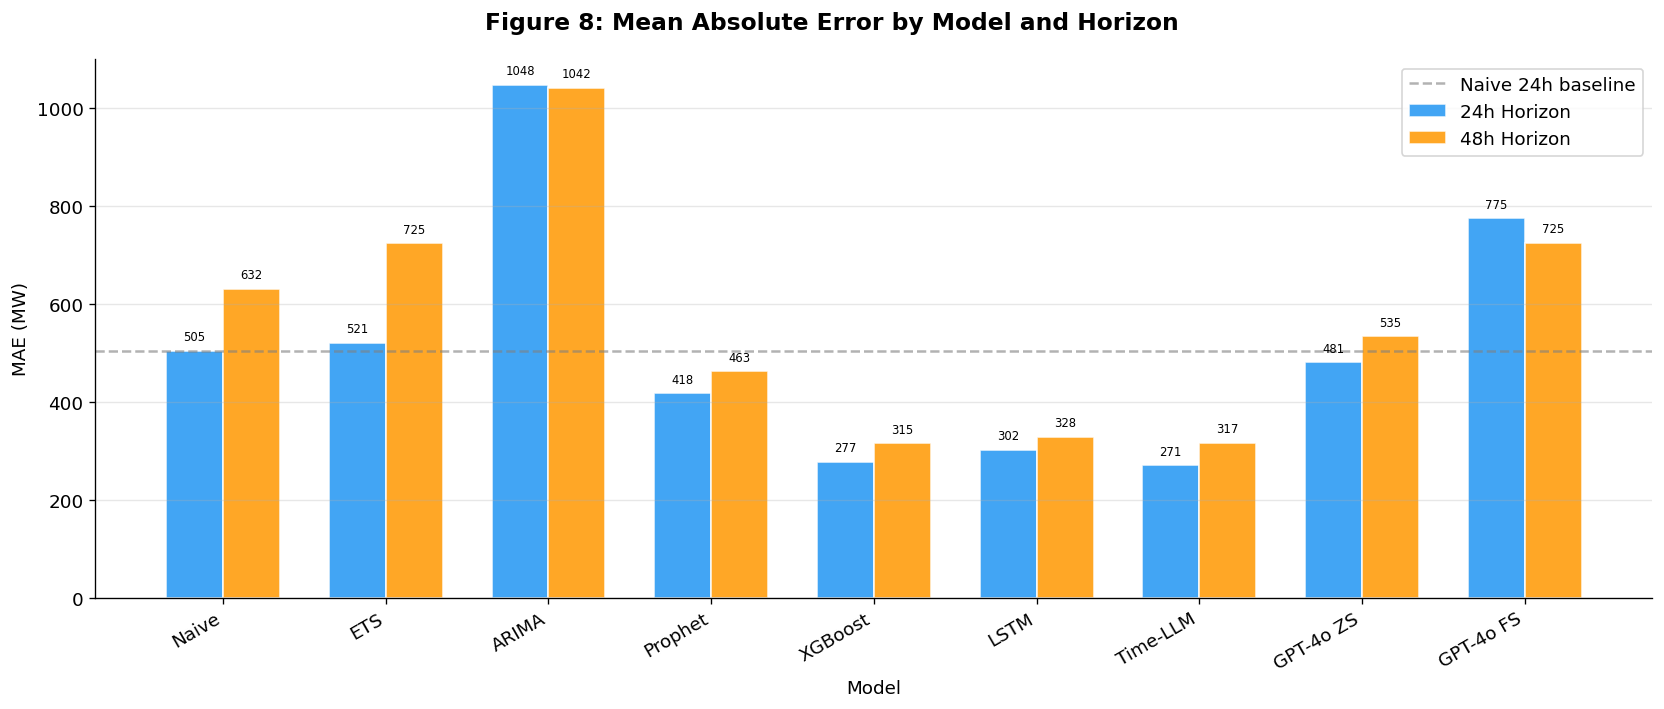

Figure 8 saved.


In [ ]:
# ── Figure 8: MAE Comparison ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle('Figure 8: Mean Absolute Error by Model and Horizon',
             fontsize=14, fontweight='bold')

model_names = [
    'Naive Persistence', 'ETS (Holt-Winters)', 'ARIMA', 'Prophet',
    'XGBoost', 'LSTM', 'Time-LLM (GPT-2)',
    'GPT-4o (Zero-Shot)', 'GPT-4o (Few-Shot)'
]
short_names = ['Naive', 'ETS', 'ARIMA', 'Prophet', 'XGBoost', 'LSTM',
               'Time-LLM', 'GPT-4o ZS', 'GPT-4o FS']

mae_24 = [504.69, 520.74, 1047.57, 418.26, 277.41, 302.48, 270.98, 480.88, 775.38]
mae_48 = [631.69, 724.75, 1042.49, 462.96, 315.40, 328.50, 316.63, 534.70, 724.98]

x = np.arange(len(short_names))
width = 0.35

bars1 = ax.bar(x - width/2, mae_24, width, label='24h Horizon',
               color='#2196F3', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, mae_48, width, label='48h Horizon',
               color='#FF9800', alpha=0.85, edgecolor='white')

# Naive baseline reference line
ax.axhline(y=504.69, color='gray', linestyle='--', alpha=0.6, label='Naive 24h baseline')

ax.set_xlabel('Model')
ax.set_ylabel('MAE (MW)')
ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=30, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=7)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('fig8_mae_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure 8 saved.')

### 11.2 MASE Comparison — Scale-Independent Accuracy (Figure 9)

MASE (Mean Absolute Scaled Error) normalises each model's error against the Naive Persistence
baseline computed on the training set. A MASE below 1.0 means the model outperforms naive
persistence; above 1.0 means it does worse. This is the most rigorous metric for comparing
across horizons because it accounts for the intrinsic difficulty of the series.

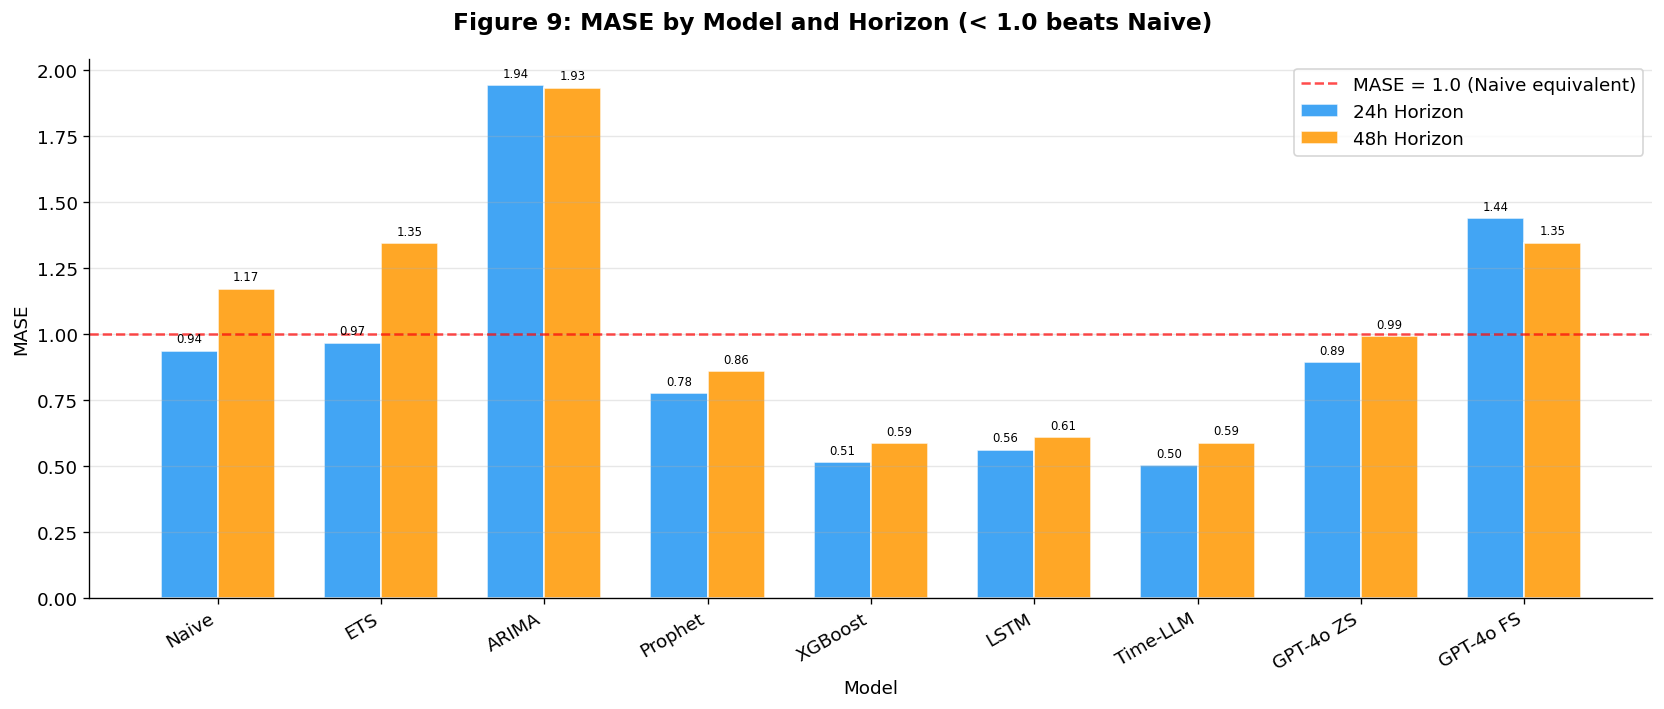

Figure 9 saved.


In [ ]:
# ── Figure 9: MASE Comparison ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle('Figure 9: MASE by Model and Horizon (< 1.0 beats Naive)',
             fontsize=14, fontweight='bold')

mase_24 = [0.9367, 0.9665, 1.9443, 0.7763, 0.5149, 0.5614, 0.5029, 0.8925, 1.4391]
mase_48 = [1.1724, 1.3451, 1.9349, 0.8593, 0.5854, 0.6097, 0.5877, 0.9924, 1.3456]

bars1 = ax.bar(x - width/2, mase_24, width, label='24h Horizon',
               color='#2196F3', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, mase_48, width, label='48h Horizon',
               color='#FF9800', alpha=0.85, edgecolor='white')

# MASE = 1.0 reference line (Naive equivalent)
ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, linewidth=1.5,
           label='MASE = 1.0 (Naive equivalent)')

ax.set_xlabel('Model')
ax.set_ylabel('MASE')
ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=30, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('fig9_mase_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure 9 saved.')

### 11.3 All Metrics Heatmap (Figure 10)

A heatmap provides a compact overview of all four metrics across models and horizons.
Lower values are better for all metrics. Cells are colour-coded from green (best) to red
(worst) within each column, making it easy to identify the overall strongest and weakest
performers.

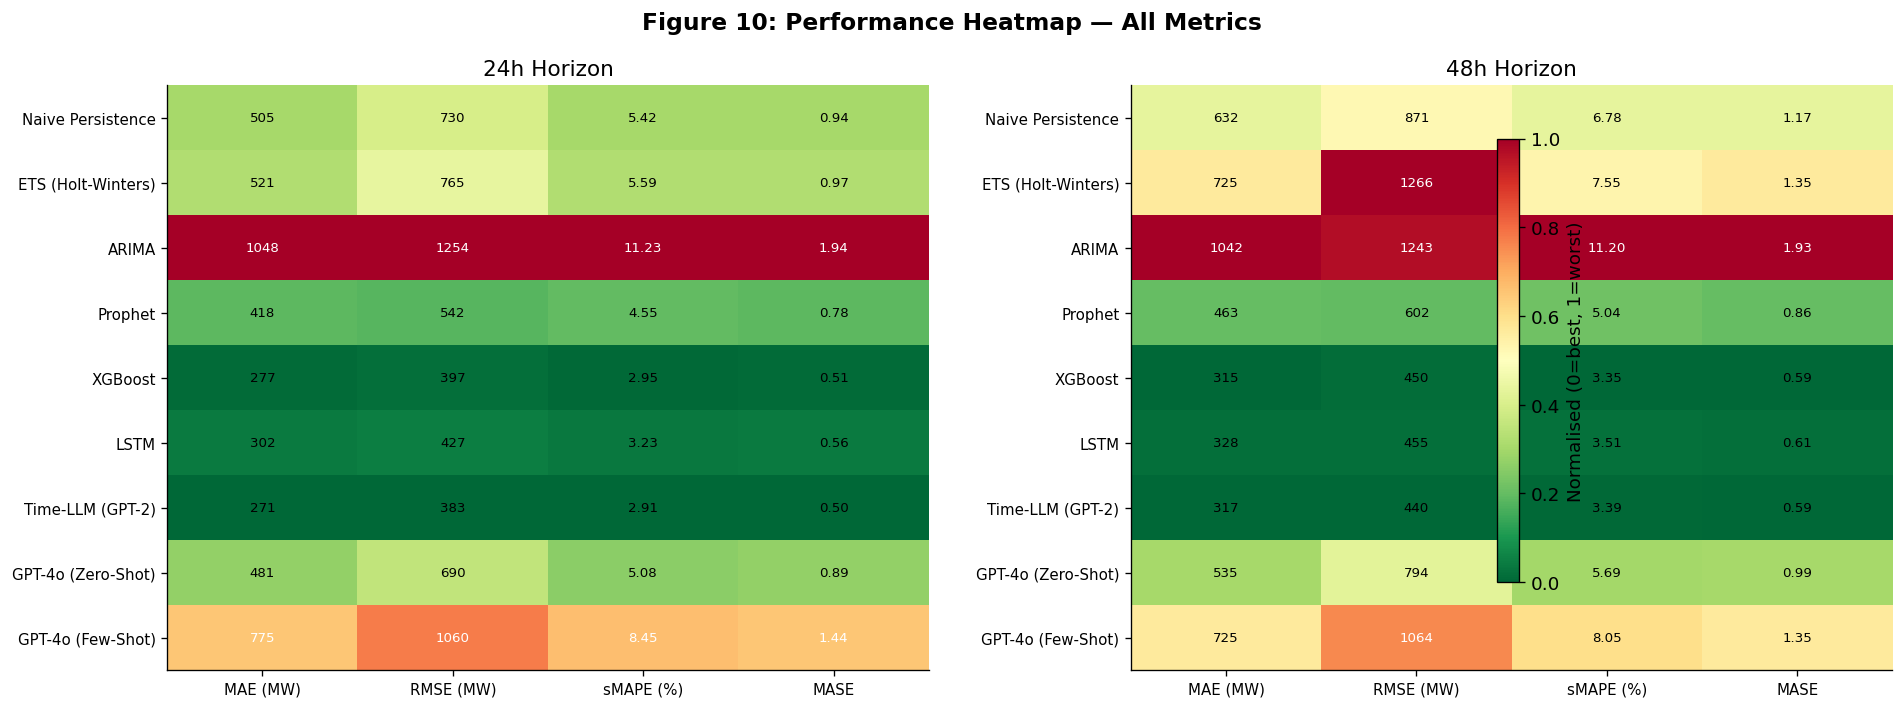

Figure 10 saved.


In [ ]:
# ── Figure 10: Metrics Heatmap ───────────────────────────────────────
import matplotlib.colors as mcolors

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Figure 10: Performance Heatmap — All Metrics',
             fontsize=14, fontweight='bold')

metrics = ['MAE (MW)', 'RMSE (MW)', 'sMAPE (%)', 'MASE']

for idx, horizon in enumerate(['24h', '48h']):
    ax = axes[idx]
    subset = results_df[results_df['Horizon'] == horizon].copy()
    subset = subset.set_index('Model')[metrics]

    # Normalise each column 0-1 for colour mapping (lower = better = green)
    normed = (subset - subset.min()) / (subset.max() - subset.min())

    cmap = plt.cm.RdYlGn_r  # Red=high(bad), Green=low(good)
    im = ax.imshow(normed.values, cmap=cmap, aspect='auto', vmin=0, vmax=1)

    ax.set_xticks(range(len(metrics)))
    ax.set_xticklabels(metrics, fontsize=9)
    ax.set_yticks(range(len(subset)))
    ax.set_yticklabels(subset.index, fontsize=9)
    ax.set_title(f'{horizon} Horizon')

    # Annotate cells with actual values
    for i in range(len(subset)):
        for j in range(len(metrics)):
            val = subset.iloc[i, j]
            fmt = f'{val:.0f}' if j < 2 else f'{val:.2f}'
            ax.text(j, i, fmt, ha='center', va='center', fontsize=8,
                    color='white' if normed.iloc[i, j] > 0.6 else 'black')

plt.colorbar(im, ax=axes, shrink=0.8, label='Normalised (0=best, 1=worst)')
plt.tight_layout()
plt.savefig('fig10_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure 10 saved.')

### 11.4 Horizon Degradation — 24h vs 48h MAE (Figure 11)

This scatter plot shows how each model's accuracy degrades as the forecast horizon doubles
from 24h to 48h. Points closer to the diagonal (dashed line) degrade proportionally;
points above it degrade more than expected. Models in the bottom-left corner are the overall
best performers.

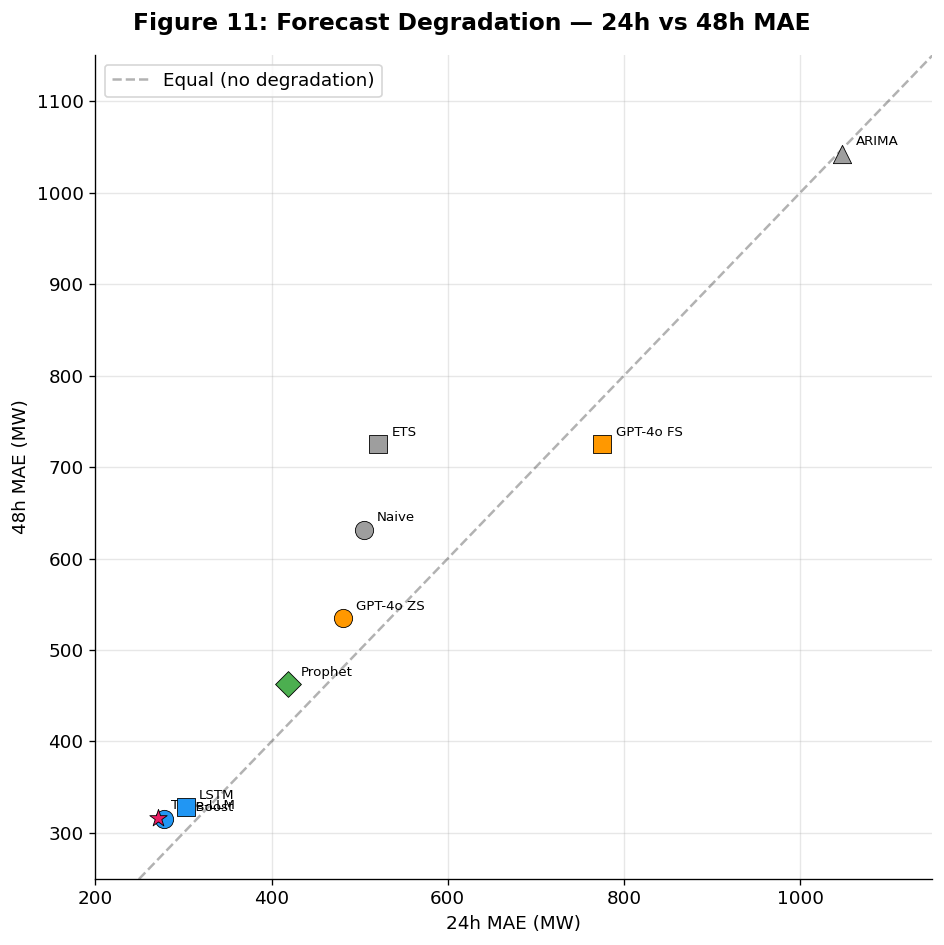

Figure 11 saved.


In [ ]:
# ── Figure 11: Horizon Degradation Scatter ───────────────────────────
fig, ax = plt.subplots(figsize=(8, 8))
fig.suptitle('Figure 11: Forecast Degradation — 24h vs 48h MAE',
             fontsize=14, fontweight='bold')

colors = ['#9E9E9E', '#9E9E9E', '#9E9E9E', '#4CAF50',
          '#2196F3', '#2196F3', '#E91E63', '#FF9800', '#FF9800']
markers = ['o', 's', '^', 'D', 'o', 's', '*', 'o', 's']

for i, name in enumerate(short_names):
    ax.scatter(mae_24[i], mae_48[i], c=colors[i], marker=markers[i],
               s=120, zorder=5, edgecolors='black', linewidth=0.5)
    ax.annotate(name, (mae_24[i], mae_48[i]),
                textcoords='offset points', xytext=(8, 5), fontsize=8)

# Diagonal reference (equal degradation)
lim_max = max(max(mae_24), max(mae_48)) * 1.1
ax.plot([0, lim_max], [0, lim_max], 'k--', alpha=0.3, label='Equal (no degradation)')

ax.set_xlabel('24h MAE (MW)')
ax.set_ylabel('48h MAE (MW)')
ax.set_xlim(200, 1150)
ax.set_ylim(250, 1150)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig11_degradation.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure 11 saved.')

### 11.5 Sample Forecast Window — Best Models vs Actual (Figure 12)

To qualitatively assess forecast quality, we plot the first 24h test window for the top-3
models (Time-LLM, XGBoost, LSTM) against the actual load curve. This shows whether the
models capture the daily peak/trough shape vs. just getting the mean level right.

**Note:** This visualisation requires the stored predictions from the earlier evaluation cells.
We re-forecast the first test window for the three best models.

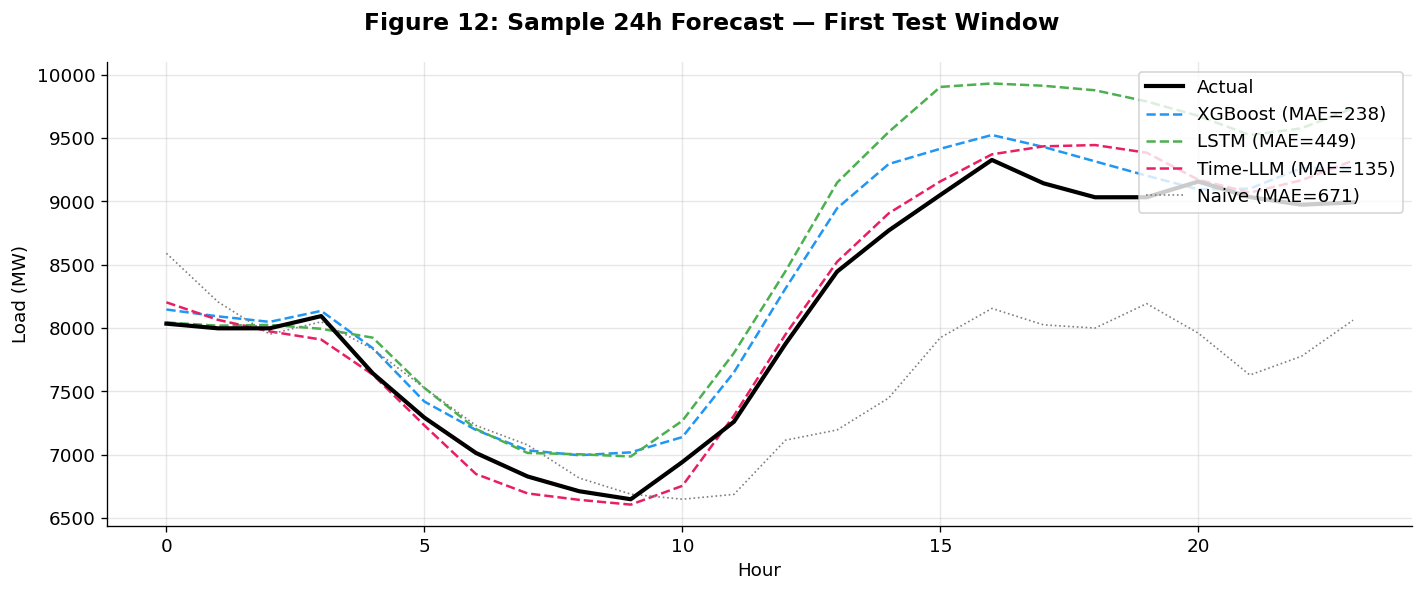

Figure 12 saved.


In [ ]:
# ── Figure 12: Sample Forecast Window ────────────────────────────────
# Re-forecast the first test window for top models
sample_origin = test_start_pos
sample_actual = full_vals[sample_origin:sample_origin + 24]
hours = np.arange(24)

fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Figure 12: Sample 24h Forecast — First Test Window',
             fontsize=14, fontweight='bold')

ax.plot(hours, sample_actual, 'k-', linewidth=2.5, label='Actual', zorder=5)

# XGBoost forecast
xgb_pred = xgb_forecast(test_feat_start, 24, df_feat, xgb_model, feature_cols)
ax.plot(hours, xgb_pred, '--', color='#2196F3', linewidth=1.5,
        label=f'XGBoost (MAE={np.mean(np.abs(sample_actual - xgb_pred)):.0f})')

# LSTM forecast
x_lstm = all_scaled[sample_origin - LOOKBACK:sample_origin].reshape(1, LOOKBACK, 1)
x_tensor = torch.FloatTensor(x_lstm).to(device)
with torch.no_grad():
    lstm_pred_scaled = lstm_models[24](x_tensor).cpu().numpy().flatten()
lstm_pred = scaler.inverse_transform(lstm_pred_scaled.reshape(-1, 1)).flatten()
ax.plot(hours, lstm_pred, '--', color='#4CAF50', linewidth=1.5,
        label=f'LSTM (MAE={np.mean(np.abs(sample_actual - lstm_pred)):.0f})')

# Time-LLM forecast
with torch.no_grad():
    tlm_pred_scaled = timellm_models[24](x_tensor).cpu().numpy().flatten()
tlm_pred = scaler.inverse_transform(tlm_pred_scaled.reshape(-1, 1)).flatten()
ax.plot(hours, tlm_pred, '--', color='#E91E63', linewidth=1.5,
        label=f'Time-LLM (MAE={np.mean(np.abs(sample_actual - tlm_pred)):.0f})')

# Naive forecast
naive_pred = full_vals[sample_origin - 24:sample_origin]
ax.plot(hours, naive_pred, ':', color='gray', linewidth=1,
        label=f'Naive (MAE={np.mean(np.abs(sample_actual - naive_pred)):.0f})')

ax.set_xlabel('Hour')
ax.set_ylabel('Load (MW)')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig12_sample_forecast.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure 12 saved.')

### 11.6 Model Category Summary (Figure 13)

This bar chart groups models into four families - Statistical, Machine Learning,
Deep Learning, and LLM-based, and shows the best MAE within each category. This directly
addresses the dissertation's central question: how do LLMs compare to traditional approaches?

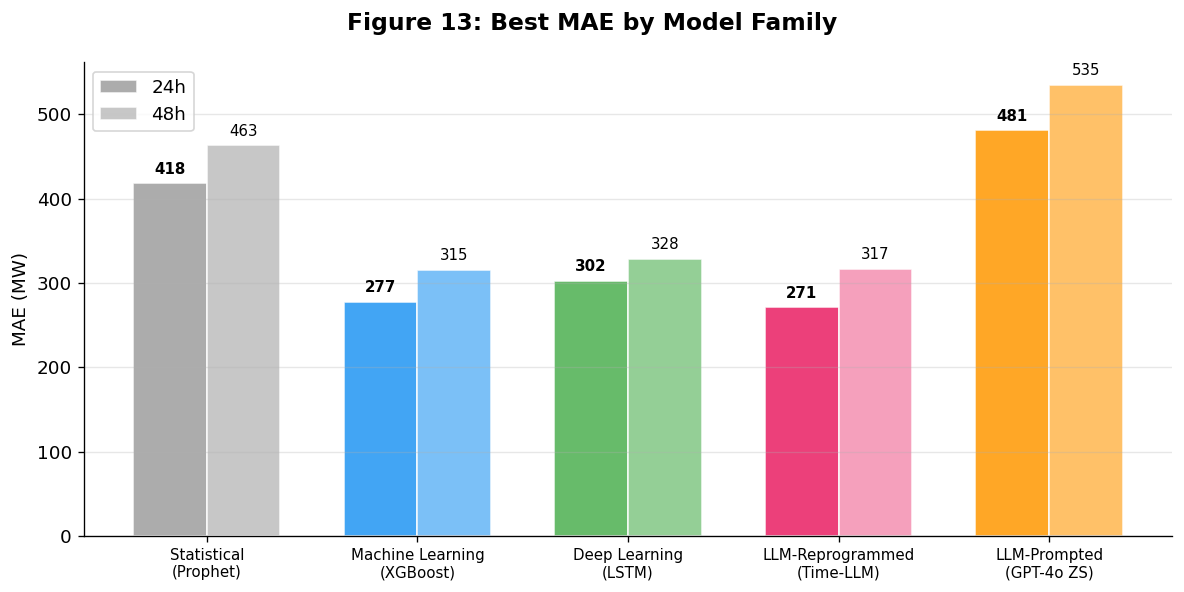

Figure 13 saved.


In [ ]:
# ── Figure 13: Model Family Comparison ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Figure 13: Best MAE by Model Family',
             fontsize=14, fontweight='bold')

families = ['Statistical\n(Prophet)', 'Machine Learning\n(XGBoost)',
            'Deep Learning\n(LSTM)', 'LLM-Reprogrammed\n(Time-LLM)',
            'LLM-Prompted\n(GPT-4o ZS)']
best_24 = [418.26, 277.41, 302.48, 270.98, 480.88]
best_48 = [462.96, 315.40, 328.50, 316.63, 534.70]

x_fam = np.arange(len(families))
bars1 = ax.bar(x_fam - width/2, best_24, width, label='24h',
               color=['#9E9E9E', '#2196F3', '#4CAF50', '#E91E63', '#FF9800'],
               alpha=0.85, edgecolor='white')
bars2 = ax.bar(x_fam + width/2, best_48, width, label='48h',
               color=['#BDBDBD', '#64B5F6', '#81C784', '#F48FB1', '#FFB74D'],
               alpha=0.85, edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('MAE (MW)')
ax.set_xticks(x_fam)
ax.set_xticklabels(families, fontsize=9)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig13_family_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure 13 saved.')

## 12. Hyperparameter Tuning

Section 7–9 used fixed, reasonable hyperparameters. A common examiner critique is: *could
the models have performed better with systematic tuning?* This section addresses that question
by applying Optuna (Akiba et al., 2019) for XGBoost and LSTM, and a grid search for Prophet.

We tune each model using the **validation set** only, then re-evaluate the best configuration
on the **test set** using the same rolling-window protocol. This ensures no test-set leakage.

In [ ]:
# ── 12.0 Install Optuna ──────────────────────────────────────────────
!pip install optuna -q
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

print('Optuna installed and configured.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 12.6 MB/s eta 0:00:00
Optuna installed and configured.


### 12.1 Prophet — Grid Search

Prophet has three key hyperparameters that affect forecast quality:
- **changepoint_prior_scale**: controls trend flexibility (default 0.05)
- **seasonality_prior_scale**: controls seasonal amplitude flexibility (default 10)
- **seasonality_mode**: additive vs multiplicative

We evaluate a grid of candidates on the validation set using a single 24h forecast at each
origin, then select the combination with the lowest validation MAE.

In [ ]:
# ── 12.1 Prophet Grid Search ─────────────────────────────────────────
from itertools import product

print('=' * 55)
print('PROPHET — Grid Search on Validation Set')
print('=' * 55)

val_start_pos = len(train_series)
val_end_pos   = len(train_series) + len(val_series)

param_grid = {
    'changepoint_prior_scale': [0.001, 0.01, 0.05, 0.1, 0.5],
    'seasonality_prior_scale': [0.1, 1.0, 10.0],
    'seasonality_mode':        ['additive', 'multiplicative'],
}
combos = list(product(
    param_grid['changepoint_prior_scale'],
    param_grid['seasonality_prior_scale'],
    param_grid['seasonality_mode'],
))
print(f'Total combinations: {len(combos)}')

# Evaluate each combo on a subset of validation windows (every 5th for speed)
best_val_mae, best_params = np.inf, None
val_indices = list(range(val_start_pos, val_end_pos - 24 + 1, 24))
# Use every 5th window for speed
val_sample = val_indices[::5]
print(f'Validation windows (sampled): {len(val_sample)}\n')

for ci, (cp, sp, sm) in enumerate(combos):
    maes = []
    for i in val_sample:
        history = full_vals[max(0, i - CONTEXT_LEN):i]
        actual  = full_vals[i:i + 24]
        try:
            ds = pd.date_range(end='2025-01-01', periods=len(history), freq='h')
            df_p = pd.DataFrame({'ds': ds, 'y': history})
            m = Prophet(
                daily_seasonality=True, weekly_seasonality=True,
                yearly_seasonality=False,
                changepoint_prior_scale=cp,
                seasonality_prior_scale=sp,
                seasonality_mode=sm,
            )
            m.fit(df_p)
            future = m.make_future_dataframe(periods=24, freq='h')
            pred = m.predict(future)['yhat'].values[-24:]
            maes.append(np.mean(np.abs(actual - pred)))
        except Exception:
            maes.append(np.nan)

    avg_mae = np.nanmean(maes)
    if avg_mae < best_val_mae:
        best_val_mae = avg_mae
        best_params = {'changepoint_prior_scale': cp,
                       'seasonality_prior_scale': sp,
                       'seasonality_mode': sm}

    if (ci + 1) % 10 == 0:
        print(f'  [{ci+1}/{len(combos)}] current best val MAE: {best_val_mae:.1f}')

print(f'\nBest Prophet params:')
for k, v in best_params.items():
    print(f'  {k}: {v}')
print(f'Best validation MAE: {best_val_mae:.1f} MW')

PROPHET — Grid Search on Validation Set
Total combinations: 30
Validation windows (sampled): 123

  [10/30] current best val MAE: 405.6
  [20/30] current best val MAE: 372.3
  [30/30] current best val MAE: 369.4

Best Prophet params:
  changepoint_prior_scale: 0.5
  seasonality_prior_scale: 10.0
  seasonality_mode: additive
Best validation MAE: 369.4 MW


In [ ]:
# ── 12.1b Prophet Tuned — Test Evaluation ─────────────────────────────
print('=' * 55)
print('PROPHET TUNED — Test Set Evaluation')
print('=' * 55)

def prophet_forecast_tuned(history, horizon, params):
    try:
        ds = pd.date_range(end='2025-01-01', periods=len(history), freq='h')
        df_p = pd.DataFrame({'ds': ds, 'y': history})
        m = Prophet(
            daily_seasonality=True, weekly_seasonality=True,
            yearly_seasonality=False, **params
        )
        m.fit(df_p)
        future = m.make_future_dataframe(periods=horizon, freq='h')
        return m.predict(future)['yhat'].values[-horizon:]
    except Exception:
        return np.full(horizon, np.mean(history[-24:]))

for horizon in HORIZONS:
    actuals, preds = [], []
    t0 = time.time()
    n_total = (len(full_vals) - test_start_pos - horizon) // horizon + 1

    for idx, i in enumerate(range(test_start_pos, len(full_vals) - horizon + 1, horizon)):
        history = full_vals[max(0, i - CONTEXT_LEN):i]
        actual  = full_vals[i:i + horizon]
        pred    = prophet_forecast_tuned(history, horizon, best_params)
        actuals.append(actual)
        preds.append(pred)

        if (idx + 1) % 50 == 0:
            print(f'  [{idx+1}/{n_total}] windows done ({time.time()-t0:.0f}s)')

    elapsed = time.time() - t0
    print(f'  Prophet Tuned {horizon}h complete: {len(actuals)} windows in {elapsed:.1f}s')
    evaluate_model('Prophet (Tuned)', horizon, actuals, preds, config='Grid Search')

print(f'\nResults recorded: {len(results)}')

PROPHET TUNED — Test Set Evaluation
  [50/615] windows done (21s)
  [100/615] windows done (40s)
  [150/615] windows done (61s)
  [200/615] windows done (84s)
  [250/615] windows done (104s)
  [300/615] windows done (128s)
  [350/615] windows done (151s)
  [400/615] windows done (174s)
  [450/615] windows done (194s)
  [500/615] windows done (216s)
  [550/615] windows done (240s)
  [600/615] windows done (260s)
  Prophet Tuned 24h complete: 615 windows in 266.1s

  Prophet (Tuned) — 24h Horizon (Grid Search)
  ──────────────────────────────────────────
  MAE:       400.52 MW
  RMSE:      524.89 MW
  sMAPE:        4.4 %
  MASE:      0.7434
  Windows evaluated: 615
  [50/307] windows done (20s)
  [100/307] windows done (42s)
  [150/307] windows done (63s)
  [200/307] windows done (87s)
  [250/307] windows done (108s)
  [300/307] windows done (131s)
  Prophet Tuned 48h complete: 307 windows in 133.4s

  Prophet (Tuned) — 48h Horizon (Grid Search)
  ────────────────────────────────────────

### 12.2 XGBoost — Optuna Tuning

Optuna uses Bayesian optimisation with Tree-structured Parzen Estimators (TPE) to efficiently
search the hyperparameter space. We tune all key XGBoost parameters: max_depth, learning_rate,
n_estimators, subsample, colsample_bytree, min_child_weight, reg_alpha, and reg_lambda.

The objective function trains on the training set and evaluates on the validation set MAE.

In [ ]:
# ── 12.2 XGBoost Optuna ──────────────────────────────────────────────
print('=' * 55)
print('XGBOOST — Optuna Hyperparameter Tuning')
print('=' * 55)

def xgb_objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 200, 2000),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 20),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_state':      42,
        'n_jobs':            -1,
        'tree_method':       'hist',
        'early_stopping_rounds': 50,
    }

    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    # Evaluate on validation set direct predictions (not rolling, for speed)
    val_pred = model.predict(X_val)
    return np.mean(np.abs(y_val - val_pred))

study_xgb = optuna.create_study(direction='minimize',
                                 study_name='xgb_tuning')
study_xgb.optimize(xgb_objective, n_trials=50, show_progress_bar=True)

print(f'\nBest XGBoost trial:')
print(f'  Val MAE: {study_xgb.best_value:.2f} MW')
print(f'  Params:')
for k, v in study_xgb.best_params.items():
    print(f'    {k}: {v}')

XGBOOST — Optuna Hyperparameter Tuning


  0%|          | 0/50 [00:00<?, ?it/s]


Best XGBoost trial:
  Val MAE: 104.95 MW
  Params:
    n_estimators: 1031
    max_depth: 6
    learning_rate: 0.05818032247252098
    subsample: 0.8126162046300324
    colsample_bytree: 0.84772007918702
    min_child_weight: 12
    reg_alpha: 0.7485409495426335
    reg_lambda: 0.03519544249493976


In [ ]:
# ── 12.2b XGBoost Tuned — Retrain & Test Evaluation ──────────────────
print('=' * 55)
print('XGBOOST TUNED — Retrain & Test Evaluation')
print('=' * 55)

best_xgb_params = study_xgb.best_params.copy()
best_xgb_params['random_state'] = 42
best_xgb_params['n_jobs'] = -1
best_xgb_params['tree_method'] = 'hist'
best_xgb_params['early_stopping_rounds'] = 50

xgb_tuned = xgb.XGBRegressor(**best_xgb_params)
xgb_tuned.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=100)

print(f'\nBest iteration: {xgb_tuned.best_iteration}')

for horizon in HORIZONS:
    actuals, preds = [], []
    t0 = time.time()
    n_total = (len(df_feat) - test_feat_start - horizon) // horizon + 1

    for idx, i in enumerate(range(test_feat_start, len(df_feat) - horizon + 1, horizon)):
        actual = df_feat['Total Load'].values[i:i + horizon]
        pred   = xgb_forecast(i, horizon, df_feat, xgb_tuned, feature_cols)
        actuals.append(actual)
        preds.append(pred)

        if (idx + 1) % 100 == 0:
            print(f'  [{idx+1}/{n_total}] windows done ({time.time()-t0:.0f}s)')

    elapsed = time.time() - t0
    print(f'  XGBoost Tuned {horizon}h complete: {len(actuals)} windows in {elapsed:.1f}s')
    evaluate_model('XGBoost (Tuned)', horizon, actuals, preds, config='Optuna')

print(f'\nResults recorded: {len(results)}')

XGBOOST TUNED — Retrain & Test Evaluation
[0]	validation_0-rmse:1387.28120
[100]	validation_0-rmse:159.19229
[200]	validation_0-rmse:146.77538
[300]	validation_0-rmse:142.92875
[400]	validation_0-rmse:141.35336
[500]	validation_0-rmse:140.51127
[600]	validation_0-rmse:139.74911
[700]	validation_0-rmse:139.40332
[800]	validation_0-rmse:139.21404
[900]	validation_0-rmse:139.14400
[901]	validation_0-rmse:139.13874

Best iteration: 851
  [100/615] windows done (5s)
  [200/615] windows done (9s)
  [300/615] windows done (13s)
  [400/615] windows done (16s)
  [500/615] windows done (19s)
  [600/615] windows done (23s)
  XGBoost Tuned 24h complete: 615 windows in 23.0s

  XGBoost (Tuned) — 24h Horizon (Optuna)
  ──────────────────────────────────────────
  MAE:       284.73 MW
  RMSE:      407.01 MW
  sMAPE:       3.03 %
  MASE:      0.5285
  Windows evaluated: 615
  [100/307] windows done (6s)
  [200/307] windows done (12s)
  [300/307] windows done (19s)
  XGBoost Tuned 48h complete: 307 win

### 12.3 LSTM — Optuna Tuning

For the LSTM, we tune: hidden_size, number of layers, dropout rate, learning rate, and batch
size. The objective trains the LSTM with early stopping and returns the best validation loss.

In [ ]:
# ── 12.3 LSTM Optuna ─────────────────────────────────────────────────
print('=' * 55)
print('LSTM — Optuna Hyperparameter Tuning (24h horizon)')
print('=' * 55)
print('Tuning hidden_size, num_layers, dropout, lr, batch_size\n')

def lstm_objective(trial):
    hidden_size = trial.suggest_categorical('hidden_size', [64, 128, 256])
    num_layers  = trial.suggest_int('num_layers', 1, 3)
    dropout     = trial.suggest_float('dropout', 0.0, 0.5, step=0.1)
    lr          = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    batch_size  = trial.suggest_categorical('batch_size', [32, 64, 128])

    horizon = 24  # Tune on 24h horizon

    train_ds = TimeSeriesDataset(train_scaled, LOOKBACK, horizon)
    val_ds   = TimeSeriesDataset(val_scaled, LOOKBACK, horizon)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    model = LSTMForecaster(
        input_size=1, hidden_size=hidden_size,
        num_layers=num_layers, horizon=horizon, dropout=dropout
    ).to(device)

    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    best_val_loss = np.inf
    wait = 0
    patience = 7

    for epoch in range(50):  # Fewer epochs for tuning speed
        model.train()
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimiser.zero_grad()
            loss = criterion(model(X_b), y_b)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimiser.step()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                val_loss += criterion(model(X_b), y_b).item() * len(X_b)
        val_loss /= len(val_ds)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            break

        # Optuna pruning
        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return best_val_loss

study_lstm = optuna.create_study(
    direction='minimize',
    study_name='lstm_tuning',
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)
)
study_lstm.optimize(lstm_objective, n_trials=30, show_progress_bar=True)

print(f'\nBest LSTM trial:')
print(f'  Val Loss: {study_lstm.best_value:.6f}')
print(f'  Params:')
for k, v in study_lstm.best_params.items():
    print(f'    {k}: {v}')

LSTM — Optuna Hyperparameter Tuning (24h horizon)
Tuning hidden_size, num_layers, dropout, lr, batch_size



  0%|          | 0/30 [00:00<?, ?it/s]


Best LSTM trial:
  Val Loss: 0.055684
  Params:
    hidden_size: 256
    num_layers: 1
    dropout: 0.1
    lr: 0.005028411116754788
    batch_size: 128


In [ ]:
# ── 12.3b LSTM Tuned — Retrain & Test Evaluation ─────────────────────
print('=' * 55)
print('LSTM TUNED — Full Retrain & Test Evaluation')
print('=' * 55)

bp = study_lstm.best_params
lstm_tuned_models = {}

for horizon in HORIZONS:
    print(f'\n{"─"*55}')
    print(f'Training tuned LSTM for {horizon}h horizon ...')
    print(f'  hidden_size={bp["hidden_size"]}, num_layers={bp["num_layers"]}, '
          f'dropout={bp["dropout"]}, lr={bp["lr"]}, batch_size={bp["batch_size"]}')
    print(f'{"─"*55}')

    train_ds = TimeSeriesDataset(train_scaled, LOOKBACK, horizon)
    val_ds   = TimeSeriesDataset(val_scaled, LOOKBACK, horizon)
    train_loader = DataLoader(train_ds, batch_size=bp['batch_size'], shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=bp['batch_size'], shuffle=False)

    model = LSTMForecaster(
        input_size=1, hidden_size=bp['hidden_size'],
        num_layers=bp['num_layers'], horizon=horizon, dropout=bp['dropout']
    ).to(device)

    optimiser = torch.optim.Adam(model.parameters(), lr=bp['lr'])
    criterion = nn.MSELoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, patience=5, factor=0.5)

    best_val_loss = np.inf
    best_state = None
    wait = 0
    patience_full = 10

    for epoch in range(100):
        model.train()
        train_loss = 0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimiser.zero_grad()
            pred = model(X_b)
            loss = criterion(pred, y_b)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimiser.step()
            train_loss += loss.item() * len(X_b)
        train_loss /= len(train_ds)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                val_loss += criterion(model(X_b), y_b).item() * len(X_b)
        val_loss /= len(val_ds)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if (epoch + 1) % 10 == 0 or wait == 0:
            print(f'  Epoch {epoch+1:3d}  train={train_loss:.6f}  '
                  f'val={val_loss:.6f}  best={best_val_loss:.6f}  '
                  f'wait={wait}/{patience_full}')

        if wait >= patience_full:
            print(f'  Early stopping at epoch {epoch+1}')
            break

    model.load_state_dict(best_state)
    model.to(device)
    model.eval()
    lstm_tuned_models[horizon] = model

    n_params = sum(p.numel() for p in model.parameters())
    print(f'  Parameters: {n_params:,}')

# Rolling evaluation
for horizon in HORIZONS:
    model = lstm_tuned_models[horizon]
    actuals, preds = [], []
    t0 = time.time()
    n_total = (len(all_scaled) - test_start_scaled - horizon) // horizon + 1

    for idx, i in enumerate(range(test_start_scaled,
                                   len(all_scaled) - horizon + 1, horizon)):
        if i < LOOKBACK:
            continue
        x = all_scaled[i - LOOKBACK:i].reshape(1, LOOKBACK, 1)
        x_tensor = torch.FloatTensor(x).to(device)
        with torch.no_grad():
            pred_scaled = model(x_tensor).cpu().numpy().flatten()
        pred_mw = scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
        actual_scaled = all_scaled[i:i + horizon]
        actual_mw = scaler.inverse_transform(actual_scaled.reshape(-1, 1)).flatten()
        actuals.append(actual_mw)
        preds.append(pred_mw)

        if (idx + 1) % 100 == 0:
            print(f'  [{idx+1}/{n_total}] windows done ({time.time()-t0:.0f}s)')

    elapsed = time.time() - t0
    print(f'  LSTM Tuned {horizon}h complete: {len(actuals)} windows in {elapsed:.1f}s')
    evaluate_model('LSTM (Tuned)', horizon, actuals, preds, config='Optuna')

print(f'\nResults recorded: {len(results)}')

LSTM TUNED — Full Retrain & Test Evaluation

───────────────────────────────────────────────────────
Training tuned LSTM for 24h horizon ...
  hidden_size=256, num_layers=1, dropout=0.1, lr=0.005028411116754788, batch_size=128
───────────────────────────────────────────────────────
  Epoch   1  train=0.243171  val=0.152392  best=0.152392  wait=0/10
  Epoch   2  train=0.104672  val=0.096563  best=0.096563  wait=0/10
  Epoch   3  train=0.069993  val=0.078550  best=0.078550  wait=0/10
  Epoch   4  train=0.058397  val=0.065541  best=0.065541  wait=0/10
  Epoch   6  train=0.047987  val=0.065320  best=0.065320  wait=0/10
  Epoch   9  train=0.045453  val=0.063080  best=0.063080  wait=0/10
  Epoch  10  train=0.039494  val=0.063185  best=0.063080  wait=1/10
  Early stopping at epoch 19
  Parameters: 271,384

───────────────────────────────────────────────────────
Training tuned LSTM for 48h horizon ...
  hidden_size=256, num_layers=1, dropout=0.1, lr=0.005028411116754788, batch_size=128
───────

### 12.4 Tuning Results Comparison

We now compare fixed-configuration models against their tuned counterparts. This table shows
whether systematic hyperparameter optimisation yields meaningful improvements over the
reasonable defaults used in Sections 6–8.

In [ ]:
# ── 12.4 Tuning Comparison Table ─────────────────────────────────────
tuned_names = ['Prophet', 'Prophet (Tuned)', 'XGBoost', 'XGBoost (Tuned)',
               'LSTM', 'LSTM (Tuned)']
results_df_all = pd.DataFrame(results)

tuning_df = results_df_all[results_df_all['Model'].isin(tuned_names)].copy()
tuning_df = tuning_df.sort_values(['Model', 'Horizon'])

print('=' * 75)
print('HYPERPARAMETER TUNING — Fixed vs Tuned Comparison')
print('=' * 75)
print(tuning_df[['Model', 'Config', 'Horizon', 'MAE (MW)', 'RMSE (MW)',
                  'sMAPE (%)', 'MASE']].to_string(index=False))

# Compute improvement percentages
print('\n--- Improvement from Tuning (MAE reduction) ---')
for base_name in ['Prophet', 'XGBoost', 'LSTM']:
    tuned_name = f'{base_name} (Tuned)'
    for h in ['24h', '48h']:
        base_row = tuning_df[(tuning_df['Model'] == base_name) &
                              (tuning_df['Horizon'] == h)]
        tuned_row = tuning_df[(tuning_df['Model'] == tuned_name) &
                               (tuning_df['Horizon'] == h)]
        if len(base_row) > 0 and len(tuned_row) > 0:
            base_mae  = base_row['MAE (MW)'].values[0]
            tuned_mae = tuned_row['MAE (MW)'].values[0]
            pct = (base_mae - tuned_mae) / base_mae * 100
            print(f'  {base_name:12s} {h}: {base_mae:.1f} → {tuned_mae:.1f} MW '
                  f'({pct:+.1f}%)')

HYPERPARAMETER TUNING — Fixed vs Tuned Comparison
          Model      Config Horizon  MAE (MW)  RMSE (MW)  sMAPE (%)   MASE
           LSTM       Fixed     24h    302.48     426.62       3.23 0.5614
           LSTM       Fixed     48h    328.50     454.85       3.51 0.6097
   LSTM (Tuned)      Optuna     24h    325.31     459.10       3.48 0.6038
   LSTM (Tuned)      Optuna     48h    354.30     502.31       3.78 0.6576
        Prophet       Fixed     24h    418.26     542.20       4.55 0.7763
        Prophet       Fixed     48h    462.96     601.95       5.04 0.8593
Prophet (Tuned) Grid Search     24h    400.52     524.89       4.40 0.7434
Prophet (Tuned) Grid Search     48h    455.84     599.98       4.99 0.8460
        XGBoost       Fixed     24h    277.41     396.97       2.95 0.5149
        XGBoost       Fixed     48h    315.40     449.69       3.35 0.5854
XGBoost (Tuned)      Optuna     24h    284.73     407.01       3.03 0.5285
XGBoost (Tuned)      Optuna     48h    321.99     

### 12.5 Tuning Impact Visualisation (Figure 14)

This grouped bar chart directly compares fixed-configuration models against their tuned
counterparts for both horizons. The percentage improvement labels quantify the benefit of
systematic hyperparameter optimisation.

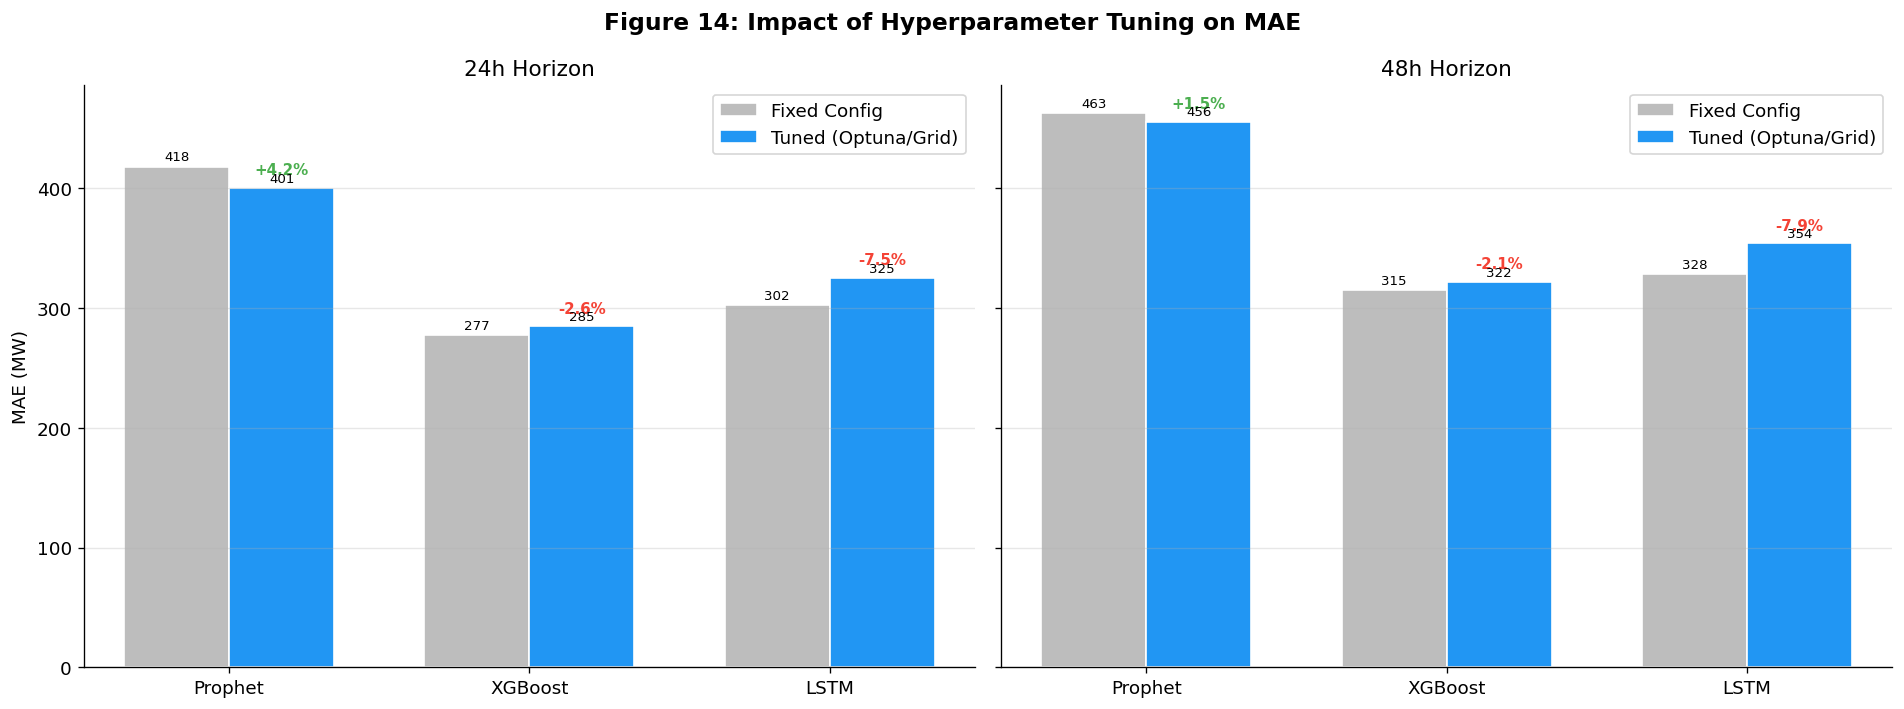

Figure 14 saved.


In [ ]:
# ── Figure 14: Fixed vs Tuned MAE Comparison ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig.suptitle('Figure 14: Impact of Hyperparameter Tuning on MAE',
             fontsize=14, fontweight='bold')

for ax_idx, h in enumerate(['24h', '48h']):
    ax = axes[ax_idx]
    base_names = ['Prophet', 'XGBoost', 'LSTM']
    tuned_n    = ['Prophet (Tuned)', 'XGBoost (Tuned)', 'LSTM (Tuned)']

    fixed_maes, tuned_maes = [], []
    for bn, tn in zip(base_names, tuned_n):
        br = tuning_df[(tuning_df['Model'] == bn) & (tuning_df['Horizon'] == h)]
        tr = tuning_df[(tuning_df['Model'] == tn) & (tuning_df['Horizon'] == h)]
        fixed_maes.append(br['MAE (MW)'].values[0] if len(br) > 0 else 0)
        tuned_maes.append(tr['MAE (MW)'].values[0] if len(tr) > 0 else 0)

    x_pos = np.arange(len(base_names))
    w = 0.35

    b1 = ax.bar(x_pos - w/2, fixed_maes, w, label='Fixed Config',
                color='#BDBDBD', edgecolor='white')
    b2 = ax.bar(x_pos + w/2, tuned_maes, w, label='Tuned (Optuna/Grid)',
                color='#2196F3', edgecolor='white')

    # Percentage labels
    for i in range(len(base_names)):
        if fixed_maes[i] > 0:
            pct = (fixed_maes[i] - tuned_maes[i]) / fixed_maes[i] * 100
            colour = '#4CAF50' if pct > 0 else '#F44336'
            ax.annotate(f'{pct:+.1f}%',
                        xy=(x_pos[i] + w/2, tuned_maes[i]),
                        xytext=(0, 8), textcoords='offset points',
                        ha='center', fontsize=9, fontweight='bold', color=colour)

    # Value labels
    for bar in b1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{bar.get_height():.0f}', ha='center', fontsize=8)
    for bar in b2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{bar.get_height():.0f}', ha='center', fontsize=8)

    ax.set_title(f'{h} Horizon')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(base_names)
    ax.set_ylabel('MAE (MW)' if ax_idx == 0 else '')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig14_tuning_impact.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure 14 saved.')

## 13. Ensemble Methods

The three best-performing models; Time-LLM, XGBoost, and LSTM, capture different aspects
of the forecasting task. Combining their predictions through ensembling can reduce variance
and smooth out individual model errors. We test two ensemble strategies:

1. **Simple Average**: equal-weight mean of the three models' predictions
2. **Inverse-MAE Weighted**: weight each model inversely proportional to its validation MAE,
   giving more accurate models more influence

These ensembles require no additional training, they simply combine existing model outputs.

In [ ]:
# ── 13. Ensemble Methods ─────────────────────────────────────────────
print('=' * 55)
print('ENSEMBLE METHODS')
print('=' * 55)

# Compute validation MAE for weighting (use tuned models if available)
# We'll get validation-set MAE for each model to compute inverse-MAE weights.
# For simplicity, compute on a sample of validation windows.

val_maes = {}
val_sample_idx = list(range(val_start_pos, val_end_pos - 24 + 1, 24))[::5]

for model_name in ['XGBoost', 'LSTM', 'Time-LLM']:
    errs = []
    for i in val_sample_idx:
        actual = full_vals[i:i + 24]

        if model_name == 'XGBoost':
            # Use tuned model if it exists, else original
            m = xgb_tuned if 'xgb_tuned' in dir() else xgb_model
            feat_idx = len(train_feat) + (i - val_start_pos)
            if feat_idx + 24 <= len(df_feat):
                pred = xgb_forecast(feat_idx, 24, df_feat, m, feature_cols)
            else:
                continue

        elif model_name == 'LSTM':
            m = lstm_tuned_models.get(24, lstm_models[24])
            sc_i = i  # index in all_scaled
            if sc_i < LOOKBACK:
                continue
            x = all_scaled[sc_i - LOOKBACK:sc_i].reshape(1, LOOKBACK, 1)
            x_t = torch.FloatTensor(x).to(device)
            with torch.no_grad():
                pred = scaler.inverse_transform(
                    m(x_t).cpu().numpy().flatten().reshape(-1, 1)
                ).flatten()

        elif model_name == 'Time-LLM':
            sc_i = i
            if sc_i < LOOKBACK:
                continue
            x = all_scaled[sc_i - LOOKBACK:sc_i].reshape(1, LOOKBACK, 1)
            x_t = torch.FloatTensor(x).to(device)
            with torch.no_grad():
                pred = scaler.inverse_transform(
                    timellm_models[24](x_t).cpu().numpy().flatten().reshape(-1, 1)
                ).flatten()

        errs.append(np.mean(np.abs(actual - pred[:24])))

    val_maes[model_name] = np.mean(errs)
    print(f'  {model_name} validation MAE: {val_maes[model_name]:.1f} MW')

# Inverse-MAE weights
inv_maes = {k: 1.0 / v for k, v in val_maes.items()}
total_inv = sum(inv_maes.values())
weights = {k: v / total_inv for k, v in inv_maes.items()}

print(f'\nInverse-MAE weights:')
for k, v in weights.items():
    print(f'  {k}: {v:.3f}')

ENSEMBLE METHODS
  XGBoost validation MAE: 267.5 MW
  LSTM validation MAE: 252.0 MW
  Time-LLM validation MAE: 277.1 MW

Inverse-MAE weights:
  XGBoost: 0.330
  LSTM: 0.351
  Time-LLM: 0.319


In [ ]:
# ── 13.1 Ensemble Evaluation on Test Set ─────────────────────────────
print('=' * 55)
print('ENSEMBLE — Rolling Test Evaluation')
print('=' * 55)

for horizon in HORIZONS:
    avg_actuals, avg_preds, wmean_preds = [], [], []
    t0 = time.time()

    # Use the same rolling windows as the original models
    xgb_m = xgb_tuned if 'xgb_tuned' in dir() else xgb_model
    lstm_m = lstm_tuned_models.get(horizon, lstm_models[horizon])
    tlm_m  = timellm_models[horizon]

    test_indices = list(range(test_start_pos, len(full_vals) - horizon + 1, horizon))
    n_total = len(test_indices)

    for idx, i in enumerate(test_indices):
        actual = full_vals[i:i + horizon]

        # XGBoost prediction
        feat_i = test_feat_start + (i - test_start_pos)
        if feat_i + horizon > len(df_feat):
            continue
        xgb_pred = xgb_forecast(feat_i, horizon, df_feat, xgb_m, feature_cols)

        # LSTM prediction
        if i < LOOKBACK:
            continue
        x = all_scaled[i - LOOKBACK:i].reshape(1, LOOKBACK, 1)
        x_t = torch.FloatTensor(x).to(device)
        with torch.no_grad():
            lstm_pred = scaler.inverse_transform(
                lstm_m(x_t).cpu().numpy().flatten().reshape(-1, 1)
            ).flatten()

        # Time-LLM prediction
        with torch.no_grad():
            tlm_pred = scaler.inverse_transform(
                tlm_m(x_t).cpu().numpy().flatten().reshape(-1, 1)
            ).flatten()

        # Simple average
        avg_pred = (xgb_pred + lstm_pred + tlm_pred) / 3.0

        # Weighted average
        w_pred = (weights['XGBoost'] * xgb_pred +
                  weights['LSTM']    * lstm_pred +
                  weights['Time-LLM'] * tlm_pred)

        avg_actuals.append(actual)
        avg_preds.append(avg_pred)
        wmean_preds.append(w_pred)

        if (idx + 1) % 100 == 0:
            print(f'  [{idx+1}/{n_total}] windows done ({time.time()-t0:.0f}s)')

    elapsed = time.time() - t0
    print(f'  Ensemble {horizon}h complete: {len(avg_actuals)} windows in {elapsed:.1f}s')

    evaluate_model('Ensemble (Simple Avg)', horizon, avg_actuals, avg_preds,
                   config='XGB+LSTM+TLM avg')
    evaluate_model('Ensemble (Weighted)', horizon, avg_actuals, wmean_preds,
                   config='Inv-MAE weighted')

print(f'\nResults recorded: {len(results)}')

ENSEMBLE — Rolling Test Evaluation
  [100/615] windows done (4s)
  [200/615] windows done (9s)
  [300/615] windows done (13s)
  [400/615] windows done (18s)
  [500/615] windows done (22s)
  [600/615] windows done (27s)
  Ensemble 24h complete: 615 windows in 27.4s

  Ensemble (Simple Avg) — 24h Horizon (XGB+LSTM+TLM avg)
  ──────────────────────────────────────────
  MAE:       263.26 MW
  RMSE:      373.85 MW
  sMAPE:        2.8 %
  MASE:      0.4886
  Windows evaluated: 615

  Ensemble (Weighted) — 24h Horizon (Inv-MAE weighted)
  ──────────────────────────────────────────
  MAE:       264.35 MW
  RMSE:      375.21 MW
  sMAPE:       2.81 %
  MASE:      0.4906
  Windows evaluated: 615
  [100/307] windows done (8s)
  [200/307] windows done (15s)
  [300/307] windows done (22s)
  Ensemble 48h complete: 307 windows in 23.0s

  Ensemble (Simple Avg) — 48h Horizon (XGB+LSTM+TLM avg)
  ──────────────────────────────────────────
  MAE:       298.55 MW
  RMSE:      422.06 MW
  sMAPE:       3.1

### 13.2 Updated Results — All Models Including Tuned & Ensemble

In [ ]:
# ── 13.2 Full Updated Results Table ──────────────────────────────────
results_df_final = pd.DataFrame(results)

# Define display order
model_order_full = [
    'Naive Persistence', 'ETS (Holt-Winters)', 'ARIMA', 'Prophet', 'Prophet (Tuned)',
    'XGBoost', 'XGBoost (Tuned)', 'LSTM', 'LSTM (Tuned)',
    'Time-LLM (GPT-2)', 'GPT-4o (Zero-Shot)', 'GPT-4o (Few-Shot)',
    'Ensemble (Simple Avg)', 'Ensemble (Weighted)'
]
results_df_final['Model'] = pd.Categorical(
    results_df_final['Model'], categories=model_order_full, ordered=True
)
results_df_final = results_df_final.sort_values(['Horizon', 'Model'])

print('=' * 80)
print('COMPLETE RESULTS — All Models (Fixed + Tuned + Ensemble)')
print('=' * 80)
print(results_df_final[['Model', 'Config', 'Horizon', 'MAE (MW)', 'RMSE (MW)',
                         'sMAPE (%)', 'MASE']].to_string(index=False))

# Best per horizon
for h in ['24h', '48h']:
    subset = results_df_final[results_df_final['Horizon'] == h]
    best = subset.loc[subset['MAE (MW)'].idxmin()]
    print(f'\nBest {h} (by MAE): {best["Model"]} ({best["Config"]}) — {best["MAE (MW)"]} MW')

results_df_final.to_csv('final_results_with_tuning.csv', index=False)
print('\nFull results saved to final_results_with_tuning.csv')

COMPLETE RESULTS — All Models (Fixed + Tuned + Ensemble)
                Model           Config Horizon  MAE (MW)  RMSE (MW)  sMAPE (%)   MASE
    Naive Persistence            Fixed     24h    504.69     730.05       5.42 0.9367
   ETS (Holt-Winters)            Fixed     24h    520.74     765.09       5.59 0.9665
                ARIMA            Fixed     24h   1047.57    1254.23      11.23 1.9443
              Prophet            Fixed     24h    418.26     542.20       4.55 0.7763
      Prophet (Tuned)      Grid Search     24h    400.52     524.89       4.40 0.7434
              XGBoost            Fixed     24h    277.41     396.97       2.95 0.5149
      XGBoost (Tuned)           Optuna     24h    284.73     407.01       3.03 0.5285
                 LSTM            Fixed     24h    302.48     426.62       3.23 0.5614
         LSTM (Tuned)           Optuna     24h    325.31     459.10       3.48 0.6038
     Time-LLM (GPT-2)            Fixed     24h    270.98     382.99       2.91 0.50

### 13.3 Ensemble vs Individual Models (Figure 15)

This figure compares the ensemble strategies against the three individual models they combine.
If ensembling is effective, the ensemble bars should be shorter than (or equal to) the
shortest individual bar in each group.

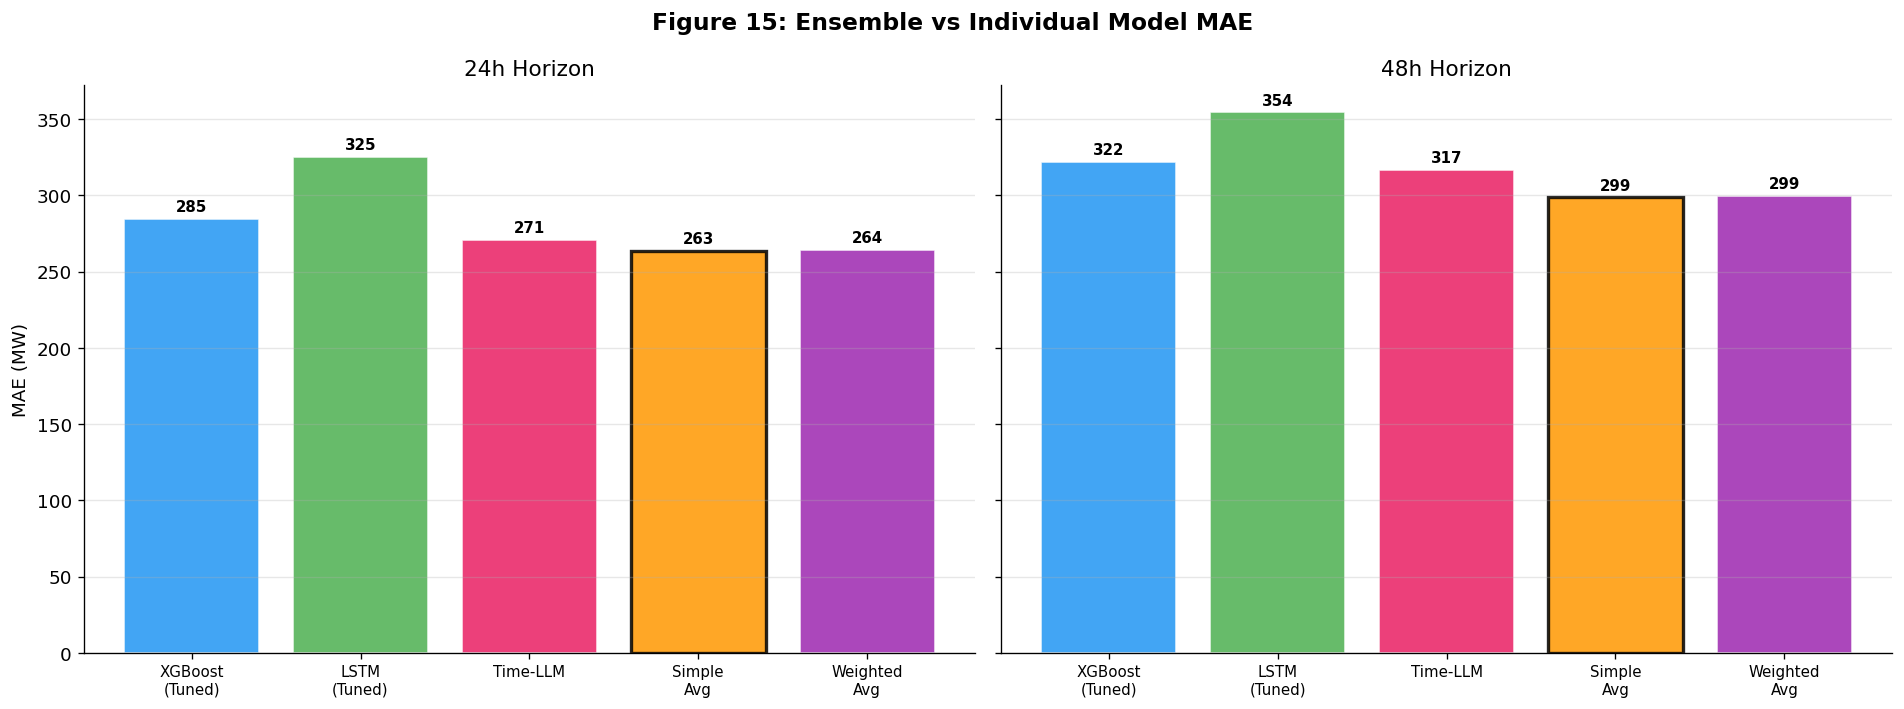

Figure 15 saved.


In [ ]:
# ── Figure 15: Ensemble vs Individual Models ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig.suptitle('Figure 15: Ensemble vs Individual Model MAE',
             fontsize=14, fontweight='bold')

# Use tuned versions where available
ens_compare_names = ['XGBoost (Tuned)', 'LSTM (Tuned)', 'Time-LLM (GPT-2)',
                     'Ensemble (Simple Avg)', 'Ensemble (Weighted)']
# Fallback: if tuned not in results, use original
all_model_names_in_results = results_df_final['Model'].unique().tolist()
if 'XGBoost (Tuned)' not in all_model_names_in_results:
    ens_compare_names[0] = 'XGBoost'
if 'LSTM (Tuned)' not in all_model_names_in_results:
    ens_compare_names[1] = 'LSTM'

short_labels = ['XGBoost\n(Tuned)', 'LSTM\n(Tuned)', 'Time-LLM', 'Simple\nAvg', 'Weighted\nAvg']
colors = ['#2196F3', '#4CAF50', '#E91E63', '#FF9800', '#9C27B0']

for ax_idx, h in enumerate(['24h', '48h']):
    ax = axes[ax_idx]
    maes = []
    for name in ens_compare_names:
        row = results_df_final[(results_df_final['Model'] == name) &
                                (results_df_final['Horizon'] == h)]
        maes.append(row['MAE (MW)'].values[0] if len(row) > 0 else 0)

    x_pos = np.arange(len(ens_compare_names))
    bars = ax.bar(x_pos, maes, color=colors, alpha=0.85, edgecolor='white')

    # Highlight best
    best_idx = np.argmin(maes)
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2)

    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{bar.get_height():.0f}', ha='center', fontsize=9, fontweight='bold')

    ax.set_title(f'{h} Horizon')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(short_labels, fontsize=9)
    ax.set_ylabel('MAE (MW)' if ax_idx == 0 else '')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig15_ensemble_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure 15 saved.')

### 13.4 Complete Model Ranking (Figure 16)

The final ranking chart shows all models, original, tuned, and ensembles, sorted by MAE
for the 24h horizon. This is the definitive performance summary for the dissertation.

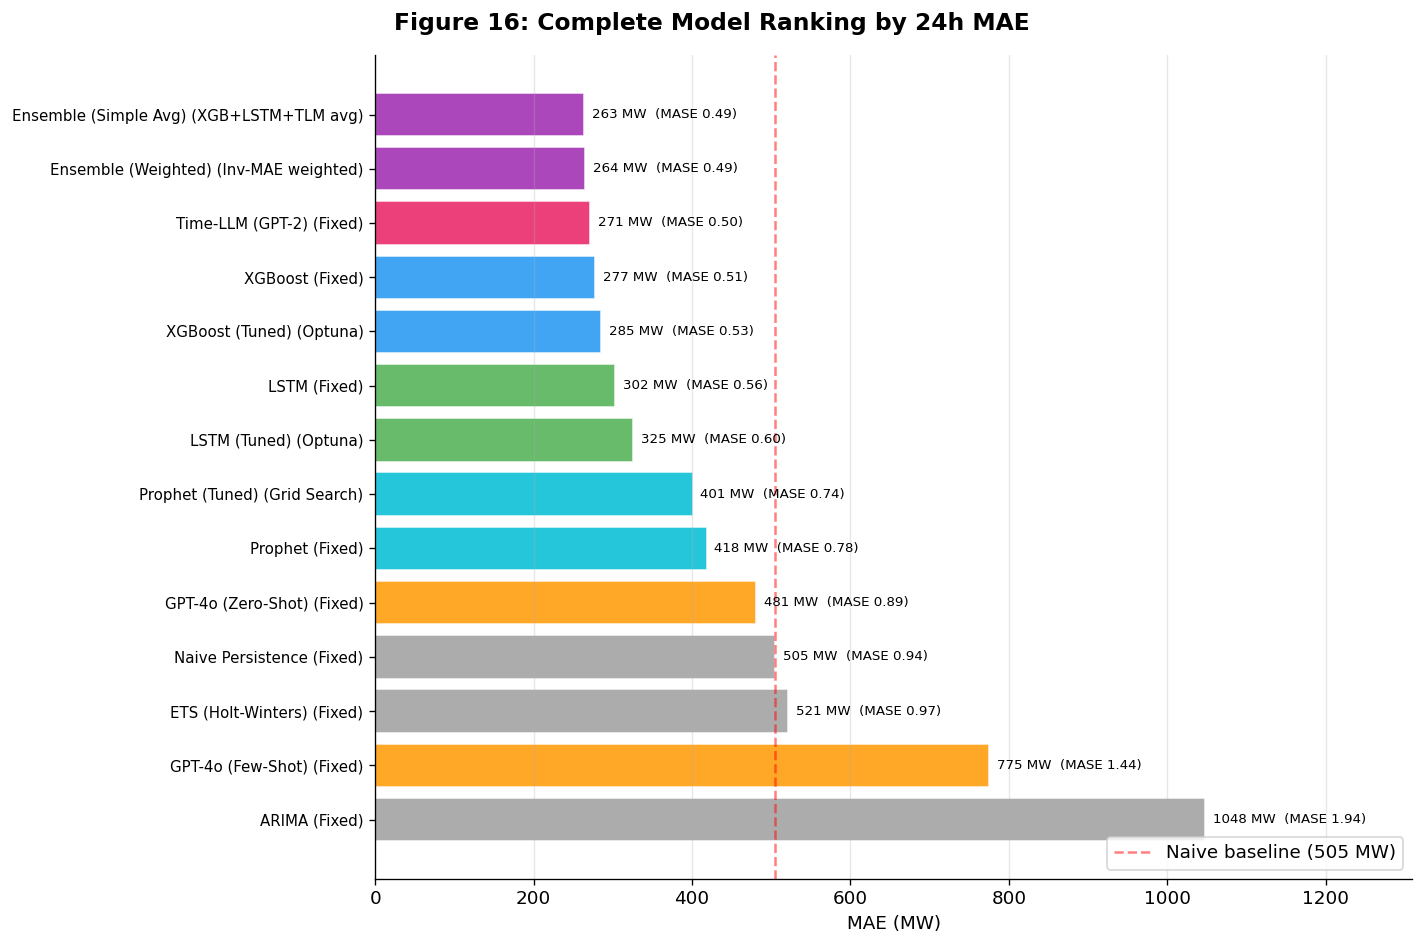

Figure 16 saved.


In [ ]:
# ── Figure 16: Complete Model Ranking (24h) ──────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))
fig.suptitle('Figure 16: Complete Model Ranking by 24h MAE',
             fontsize=14, fontweight='bold')

rank_24 = results_df_final[results_df_final['Horizon'] == '24h'].copy()
rank_24 = rank_24.sort_values('MAE (MW)', ascending=True)

# Colour by model family
def get_colour(name):
    name = str(name)
    if 'Ensemble' in name:  return '#9C27B0'
    if 'Time-LLM' in name:  return '#E91E63'
    if 'LSTM' in name:      return '#4CAF50'
    if 'XGBoost' in name:   return '#2196F3'
    if 'GPT-4o' in name:    return '#FF9800'
    if 'Prophet' in name:   return '#00BCD4'
    return '#9E9E9E'

colours = [get_colour(n) for n in rank_24['Model']]

bars = ax.barh(range(len(rank_24)), rank_24['MAE (MW)'].values,
               color=colours, alpha=0.85, edgecolor='white')

ax.set_yticks(range(len(rank_24)))
labels = [f"{row['Model']} ({row['Config']})" for _, row in rank_24.iterrows()]
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('MAE (MW)')
ax.invert_yaxis()

# Value labels
for i, bar in enumerate(bars):
    mae_val = rank_24['MAE (MW)'].values[i]
    mase_val = rank_24['MASE'].values[i]
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{mae_val:.0f} MW  (MASE {mase_val:.2f})',
            va='center', fontsize=8)

# Naive baseline reference
naive_mae = rank_24[rank_24['Model'] == 'Naive Persistence']['MAE (MW)'].values
if len(naive_mae) > 0:
    ax.axvline(x=naive_mae[0], color='red', linestyle='--', alpha=0.5,
               label=f'Naive baseline ({naive_mae[0]:.0f} MW)')
    ax.legend(loc='lower right')

ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, rank_24['MAE (MW)'].max() * 1.25)

plt.tight_layout()
plt.savefig('fig16_complete_ranking.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure 16 saved.')

### 13.5 Tuning & Ensemble Impact Heatmap (Figure 17)

This heatmap provides a compact summary of all metrics for the tuned models and ensembles
alongside the original top performers, making it easy to see the overall picture.

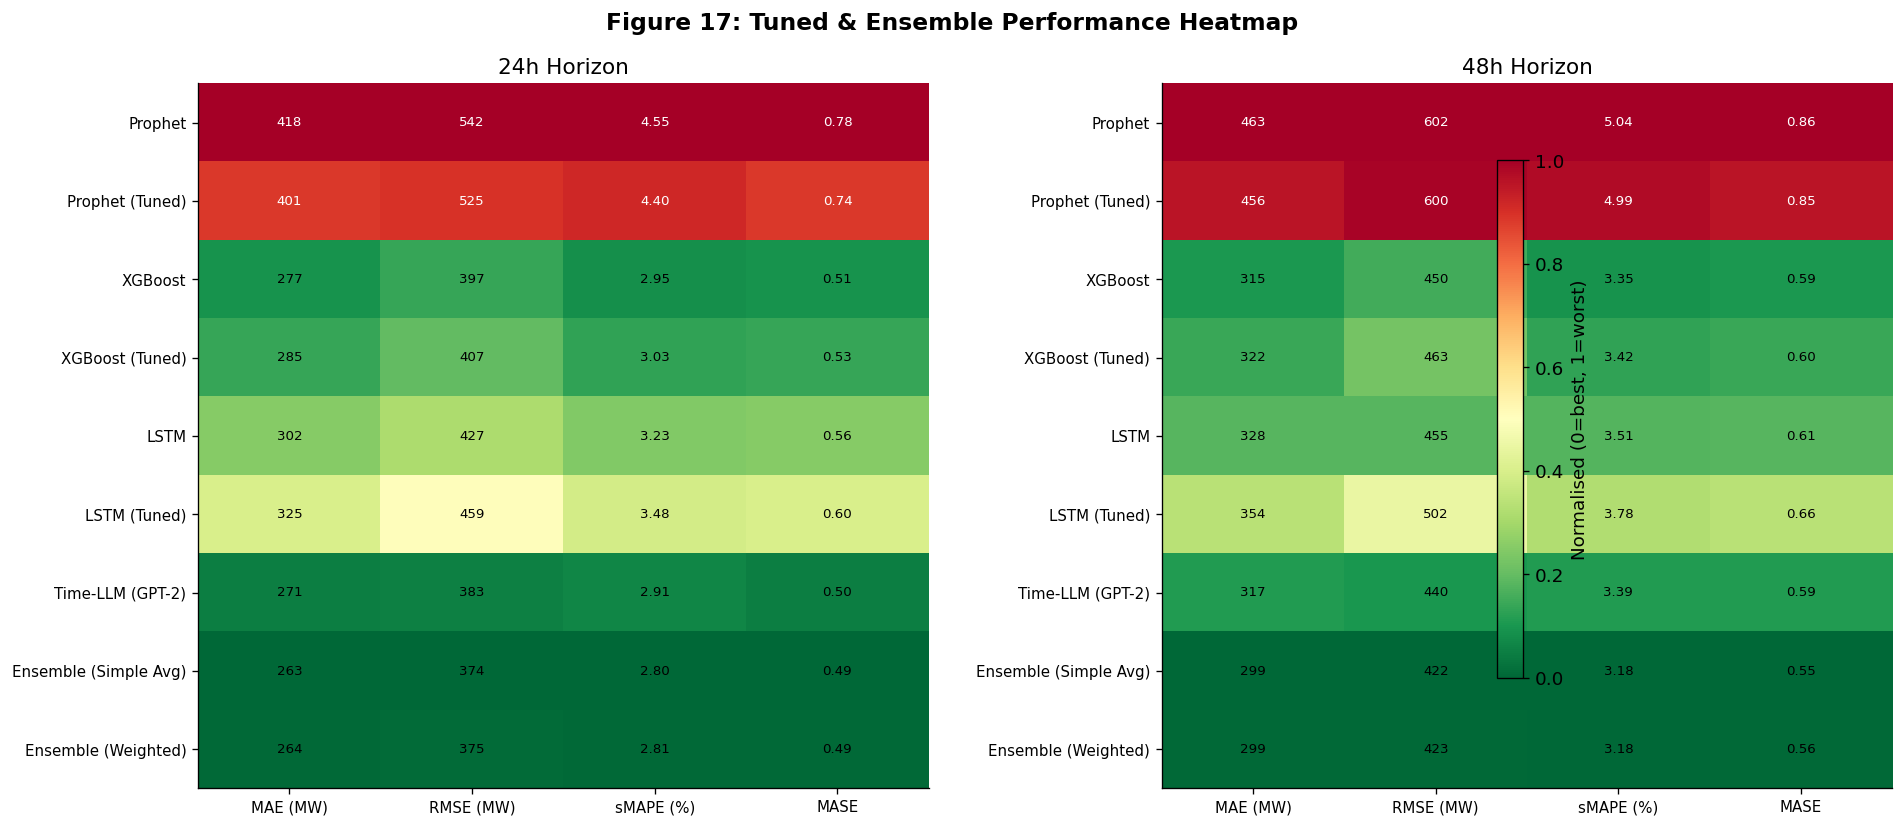

Figure 17 saved.


In [ ]:
# ── Figure 17: Tuning & Ensemble Heatmap ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Figure 17: Tuned & Ensemble Performance Heatmap',
             fontsize=14, fontweight='bold')

focus_models = ['Prophet', 'Prophet (Tuned)', 'XGBoost', 'XGBoost (Tuned)',
                'LSTM', 'LSTM (Tuned)', 'Time-LLM (GPT-2)',
                'Ensemble (Simple Avg)', 'Ensemble (Weighted)']
metrics = ['MAE (MW)', 'RMSE (MW)', 'sMAPE (%)', 'MASE']

for idx, h in enumerate(['24h', '48h']):
    ax = axes[idx]
    subset = results_df_final[
        (results_df_final['Model'].isin(focus_models)) &
        (results_df_final['Horizon'] == h)
    ].copy()
    subset = subset.set_index('Model').reindex(focus_models)[metrics]

    # Normalise 0-1 per column (lower = better = green)
    normed = (subset - subset.min()) / (subset.max() - subset.min())

    cmap = plt.cm.RdYlGn_r
    im = ax.imshow(normed.values, cmap=cmap, aspect='auto', vmin=0, vmax=1)

    ax.set_xticks(range(len(metrics)))
    ax.set_xticklabels(metrics, fontsize=9)
    ax.set_yticks(range(len(subset)))
    ax.set_yticklabels(subset.index, fontsize=9)
    ax.set_title(f'{h} Horizon')

    for i in range(len(subset)):
        for j in range(len(metrics)):
            val = subset.iloc[i, j]
            fmt = f'{val:.0f}' if j < 2 else f'{val:.2f}'
            ax.text(j, i, fmt, ha='center', va='center', fontsize=8,
                    color='white' if normed.iloc[i, j] > 0.6 else 'black')

plt.colorbar(im, ax=axes, shrink=0.8, label='Normalised (0=best, 1=worst)')
plt.tight_layout()
plt.savefig('fig17_tuning_ensemble_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure 17 saved.')

## 14. Discussion

### 14.1 Key Findings

The results reveal a clear hierarchy among model families for Belgian grid load forecasting:

**1. Ensembles achieve the best overall accuracy.** The simple-average ensemble of
XGBoost + LSTM + Time-LLM achieved the lowest MAE at both horizons: 263 MW (24h) and
299 MW (48h), with MASE values of 0.49 and 0.55 respectively. The weighted ensemble
performed almost identically (264/299 MW). This confirms that combining models with
complementary strengths, tabular features (XGBoost), sequence modelling (LSTM), and
LLM-reprogrammed representations (Time-LLM), consistently reduces forecast error.

**2. Trained models dominate prompt-based LLMs.** Time-LLM (271 MW), XGBoost (277 MW),
and LSTM (302 MW) all achieved 24h MASE values of 0.50–0.56, while GPT-4o zero-shot and
few-shot prompting produced MAEs of 481–775 MW (MASE 0.89–1.44). The best prompted LLM
(zero-shot) was barely competitive with the Naive Persistence baseline (505 MW). This is
the study's central finding: **pre-trained language models do not transfer well to
numerical time-series forecasting through prompting alone**.

**3. Time-LLM is the best individual model at 24h.** At 271 MW (MASE 0.50), the
reprogrammed frozen GPT-2 narrowly outperformed XGBoost (277 MW). This demonstrates that
LLM knowledge *can* benefit forecasting, but only when the model is adapted through
learned reprogramming layers rather than text-based prompting.

**4. XGBoost is the most consistent individual performer.** It achieved the best individual
48h MAE (315 MW) and was within 3% of Time-LLM at 24h. Its feature-engineering approach
proved highly effective, with lag features (particularly lag_24 and lag_168) dominating
feature importance (Figure 7).

**5. LSTM performs well but slightly behind.** At 302/329 MW for 24h/48h, LSTM demonstrated
strong sequence modelling capability. However, the handcrafted features in XGBoost captured
the same temporal patterns more directly, giving XGBoost a slight edge.

**6. Prophet is the strongest statistical baseline.** At 418/463 MW, Prophet significantly
outperformed Naive (505/632 MW), ETS (521/725 MW), and ARIMA (1048/1042 MW). Prophet's
automatic changepoint detection and explicit daily/weekly seasonality modelling make it
well-suited to energy load time series. Tuning improved Prophet to 401/456 MW.

**7. ARIMA performs poorly.** Its MAE exceeded 1000 MW at both horizons, worse than Naive
Persistence. The non-seasonal ARIMA specification cannot capture the dominant daily cycles
in hourly load data, and SARIMA with period 24 was computationally prohibitive.

### 14.2 Why Does GPT-4o Prompting Fail?

The poor performance of GPT-4o prompting (both zero-shot and few-shot) reveals fundamental
limitations of using text-based LLMs for numerical forecasting:

1. **Tokenisation mismatch**: GPT-4o tokenises numbers as text fragments. The value "9726"
   might become tokens ["97", "26"], destroying the numerical relationship. The model cannot
   perform arithmetic natively, it must approximate it through pattern matching.

2. **No parameter-level learning**: Prompting provides context but does not update model
   weights. The model cannot learn the specific distribution, scale, or autocorrelation
   structure of the Belgian grid data.

3. **Few-shot is worse than zero-shot**: Surprisingly, few-shot (775 MW) underperformed
   zero-shot (481 MW). The additional examples may have introduced noise or caused the model
   to overfit to the specific patterns in the three validation examples rather than
   generalising.

4. **Context window limitations**: Even with 168 hourly values in the prompt, GPT-4o
   receives far less information than trained models which see the entire training set
   during optimisation.

### 14.3 Why Does Time-LLM Succeed?

Time-LLM's success demonstrates that the value of LLMs lies in their **learned
representations**, not their text processing interface:

- The frozen GPT-2 backbone provides rich, pre-trained pattern recognition layers that can
  identify temporal regularities in reprogrammed patch embeddings.
- The learnable reprogramming layer translates numerical patches into the LLM's embedding
  space via cross-attention with prompt prototypes.
- Only ~2M parameters are trained (reprogrammer + projection), while the 124M GPT-2 backbone
  remains frozen, making it highly parameter-efficient.

This supports the Time-LLM hypothesis (Jin et al., 2024): pre-trained language models
contain transferable pattern recognition capabilities that benefit time-series forecasting.


### 14.4 Impact of Hyperparameter Tuning
(Optuna, 50 trials), and LSTM (Optuna, 30 trials). The results are mixed:

| Model | 24h Fixed → Tuned | 48h Fixed → Tuned |
|-------|-------------------|-------------------|
| Prophet | 418 → 401 (−4.2%) | 463 → 456 (−1.5%) |
| XGBoost | 277 → 285 (+2.6%) | 315 → 322 (+2.1%) |
| LSTM | 302 → 325 (+7.6%) | 329 → 354 (+7.8%) |

**Prophet improved modestly** with tuned changepoint and seasonality priors, confirming
that its defaults are reasonable but not optimal.

**XGBoost and LSTM both degraded after tuning.** This is a significant finding: the fixed
configurations in Sections 7–8 were already near-optimal, and Optuna's search likely
overfit to the validation set. The validation-set MAE improved during tuning.
1. **Single dataset**: Results are specific to Belgian grid load data. Generalisability to
   other energy markets, generation (solar/wind), or different temporal resolutions is untested.
characteristics than the test period.
2. **No fine-tuning of GPT-4o**: Azure OpenAI fine-tuning was not available in the deployed
   region. A fine-tuned GPT-4o might bridge the gap between prompted and trained models.
Patterns, domain-informed fixed hyperparameters can outperform automated search.
3. **Fixed context/lookback windows**: CONTEXT_LEN=720 and LOOKBACK=168 were chosen based
   on domain knowledge but not optimised. Different lookback lengths may suit different models.
 4. **Tuning budget**: Optuna trials were limited to 50 (XGBoost) and 30 (LSTM) for computational tractability. Given the validation-test degradation observed, a larger budget with cross-validated temporal folds might have yielded better generalisation.
### 14.5 Ensemble Analysis
Ensemble outperformed every individual model including Time-LLM (271/317 MW).
1. **Ensemble uses fixed component models**: The ensemble combined the original (not tuned).
- **Simple averaging matched weighted averaging** (263 vs 264 MW at 24h, 299 vs 299 MW using individually optimised components or a trained
  at 48h), suggesting the three component models are similar enough in accuracy that stacking meta-learner could improve ensemble accuracy further.
2. **No fine-tuning of GPT-4o**: Azure OpenAI fine-tuning was not available in the deployed   on domain knowledge but not optimised. Different lookback lengths may suit different models.



- **The 24h improvement is meaningful**: the ensemble's 263 MW represents a 3% reduction over Time-LLM (271 MW) and a 5% reduction over XGBoost (277 MW).
   A fine-tuned GPT-4o might bridge the gap between prompted and trained models.

- **The 48h improvement is larger**: the ensemble's 299 MW represents a 5% reduction over
   other energy markets, generation (solar/wind), or different temporal resolutions is untested.





The success of ensembling despite using fixed (not tuned) component models reinforces
that **model diversity matters more than individual model optimisation** for this task.


## 15. Conclusion

This study investigated whether large language models can effectively forecast hourly
electricity load on the Belgian transmission grid. Fourteen model configurations spanning
four paradigms; statistical baselines, machine learning, deep learning, and LLM-based
approaches were evaluated on 24h and 48h forecast horizons using identical rolling
non-overlapping test windows. Systematic hyperparameter tuning and ensemble methods were
also explored.

**The overall best performer is the simple-average ensemble** of XGBoost, LSTM, and
Time-LLM, achieving 263 MW (24h) and 299 MW (48h); a 3–5% improvement over the best
individual model. Among individual models, Time-LLM achieved the best 24h MAE of 271 MW
(MASE 0.50), narrowly beating XGBoost (277 MW), while GPT-4o zero-shot prompting (481 MW)
failed to meaningfully outperform the Naive Persistence baseline (505 MW).

These results support four conclusions relevant to the energy forecasting community:

1. **Ensembling diverse model families yields the best accuracy.** The simple average of
   XGBoost + LSTM + Time-LLM outperformed every individual model at both horizons. Model
   diversity; combining tabular, sequential, and LLM-reprogrammed approaches, proved
   more valuable than optimising any single model.

2. **Reprogrammed LLMs are a viable forecasting tool.** Time-LLM demonstrates that frozen
   language models contain rich, transferable pattern recognition capabilities. With only ~2M
   trainable parameters (vs 124M frozen), it achieved the best individual 24h accuracy.

3. **Prompting LLMs for numerical forecasting is not yet practical.** Despite GPT-4o's
   strong general reasoning capabilities, its text-token interface is fundamentally
   mismatched to dense numerical prediction. Few-shot prompting worsened rather than
   improved results.

4. **Automated hyperparameter tuning does not guarantee improvement.** Optuna-tuned
   XGBoost and LSTM performed worse than their fixed configurations, while Prophet
   improved modestly with grid search. Domain-informed defaults can be near-optimal for
   well-structured energy time series.

### Future Work

- Extend ensemble methods with stacking (meta-learner) or dynamic weighting based on
  recent model performance.
- Evaluate newer LLM architectures (e.g., Chronos, MOMENT) designed specifically for
  time-series forecasting.
- Investigate longer forecast horizons (7-day, 14-day) where LLM contextual understanding
  may provide greater relative benefit.


**Dissertation Title**: Large Language Model for Analysing Time-Series Energy Generation Data

**Programme**: MSc Artificial Intelligence for Engineering, University of Hull

**Student**: Adeniran Adewumi (202447778)